In [1]:
# import matplotlib as mpl

# # Increase tick label font sizes and tick length/width globally for all plots
# mpl.rcParams.update({
#     "xtick.labelsize": 14,
#     "ytick.labelsize": 14,
#     "xtick.major.size": 6,
#     "ytick.major.size": 6,
#     "xtick.minor.size": 4,
#     "ytick.minor.size": 4,
#     "xtick.major.width": 1.2,
#     "ytick.major.width": 1.2,
#     "xtick.minor.width": 1.0,
#     "ytick.minor.width": 1.0,
#     "xtick.direction": "in",
#     "ytick.direction": "in",
# })

Found 14 candidate files.
  IC3392: loaded EW map with shape (438, 437)
  NGC4064: loaded EW map with shape (665, 566)
  NGC4192: loaded EW map with shape (1629, 1092)
  NGC4293: loaded EW map with shape (532, 923)
  NGC4298: loaded EW map with shape (995, 1042)
  NGC4330: loaded EW map with shape (760, 881)
  NGC4383: loaded EW map with shape (705, 633)
  NGC4396: loaded EW map with shape (755, 883)
  NGC4419: loaded EW map with shape (643, 628)
  NGC4457: loaded EW map with shape (725, 725)
  NGC4501: loaded EW map with shape (1236, 1205)
  NGC4522: loaded EW map with shape (659, 590)
  NGC4694: loaded EW map with shape (440, 439)
  NGC4698: loaded EW map with shape (1189, 608)


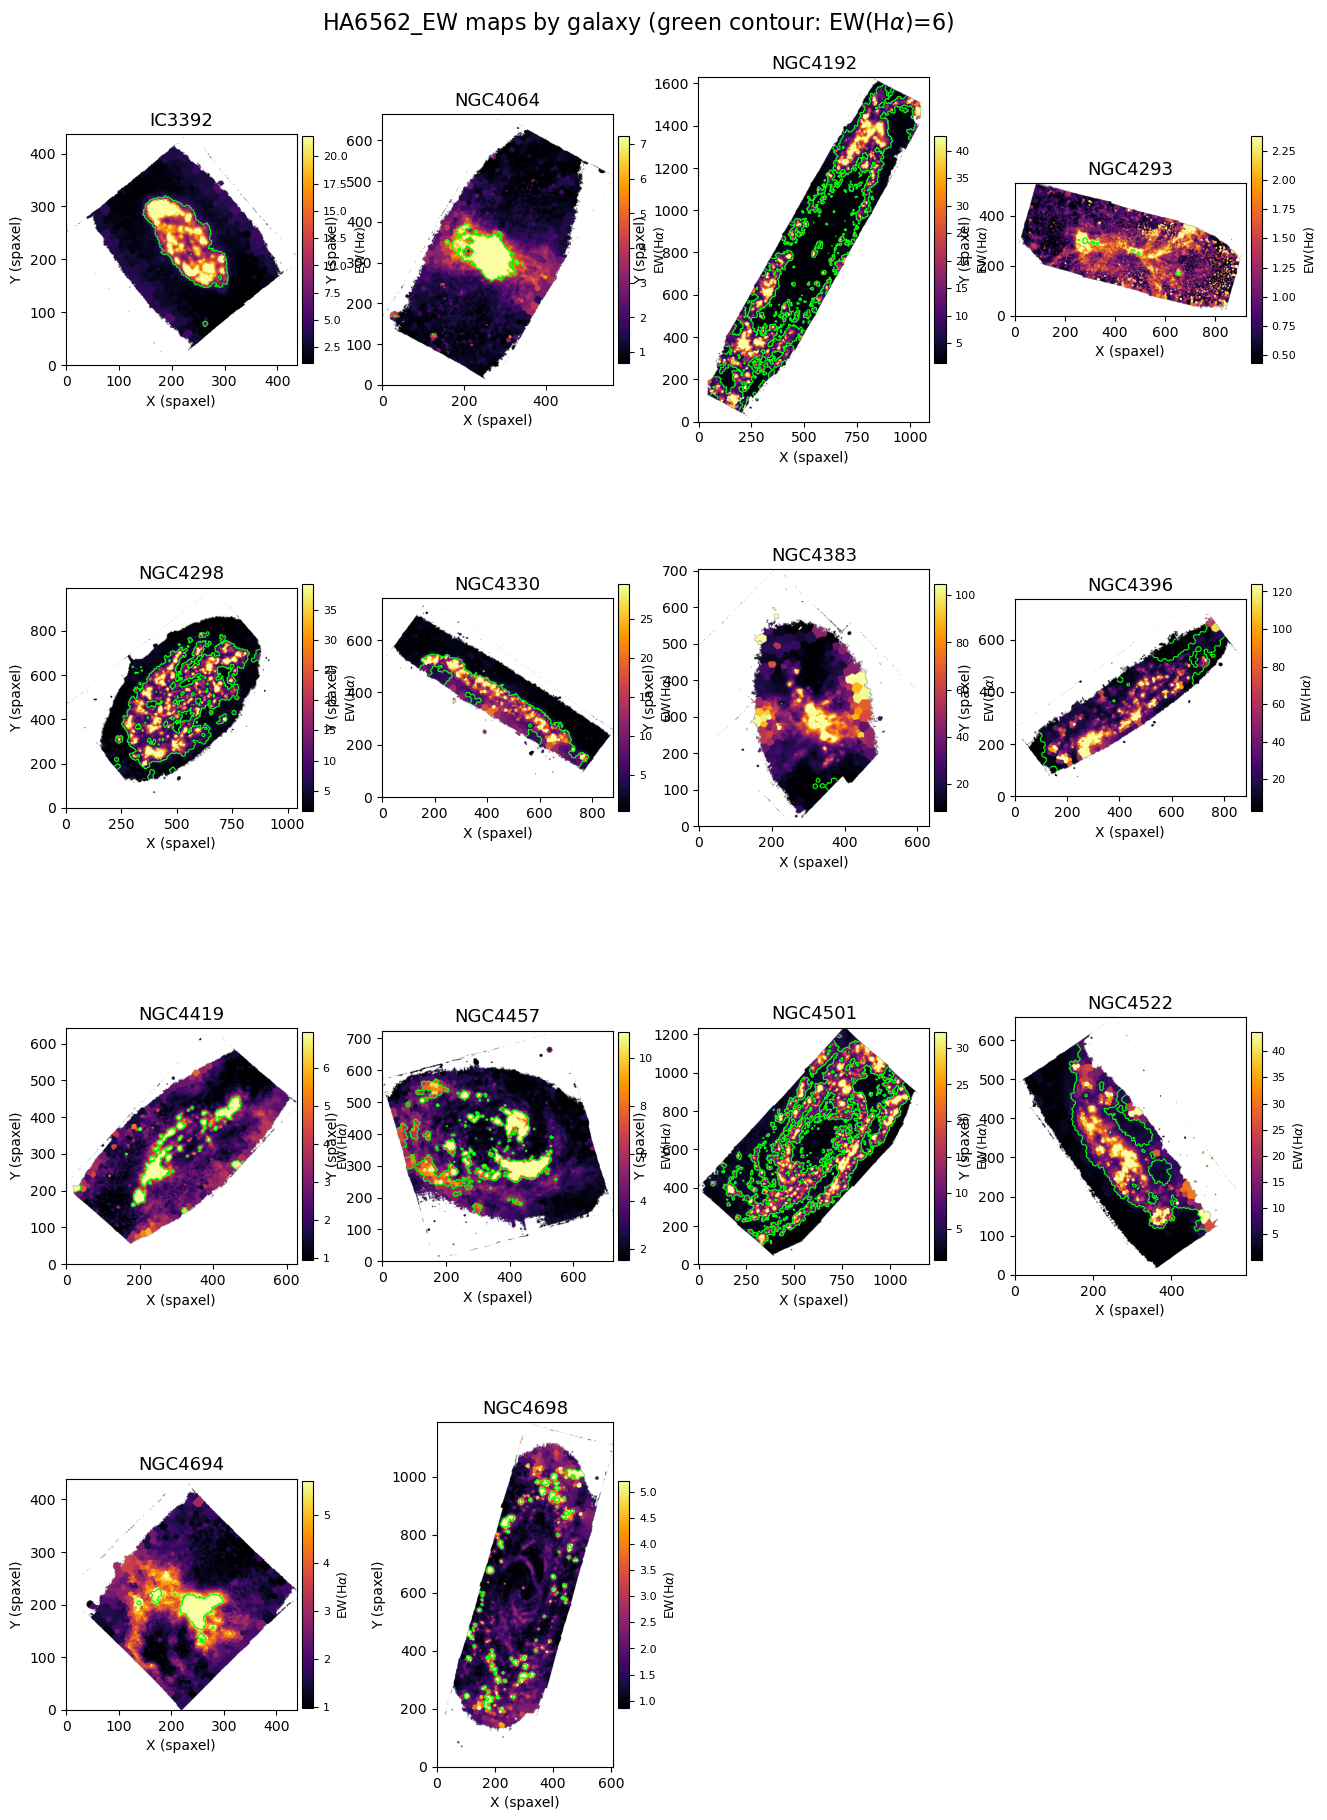


Plotted EW(H$\alpha$) maps for 14 galaxies.


In [2]:
# ------------------------------------------------------------------
# EW(H$\\alpha$) maps for all galaxies in the current directory
# Read HA6562_EW from XXX_v0.7dev_gas_BIN_maps.fits
# Plot one galaxy per subplot with 2 columns
# Each galaxy has its own colorbar (inferno) and EW=6 contour
# ------------------------------------------------------------------
import math
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits

EW_LEVEL = 6.0

gas_files = sorted(Path('.').glob('*_v0.7dev_gas_BIN_maps.fits'))
if len(gas_files) == 0:
    raise FileNotFoundError('No *_v0.7dev_gas_BIN_maps.fits files found in the current directory.')

galaxy_maps = []
missing_ew = []

print(f'Found {len(gas_files)} candidate files.')
for f in gas_files:
    galaxy = f.name.replace('_v0.7dev_gas_BIN_maps.fits', '')

    try:
        with fits.open(f) as h:
            if 'HA6562_EW' not in h:
                missing_ew.append(galaxy)
                print(f'  {galaxy}: missing HDU HA6562_EW')
                continue

            ew_map = np.array(h['HA6562_EW'].data, dtype=float)
            if ew_map.ndim != 2:
                print(f'  {galaxy}: HA6562_EW is not 2D (shape={ew_map.shape}), skipping')
                continue

            ew_map[~np.isfinite(ew_map)] = np.nan
            galaxy_maps.append((galaxy, ew_map))
            print(f'  {galaxy}: loaded EW map with shape {ew_map.shape}')
    except Exception as e:
        print(f'  {galaxy}: failed to read file ({e})')

if len(galaxy_maps) == 0:
    raise RuntimeError('No valid HA6562_EW maps were loaded.')

n_galaxies = len(galaxy_maps)
ncols = 4
nrows = math.ceil(n_galaxies / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(13, 4.8 * nrows),
    squeeze=False,
)
plt.subplots_adjust(left=0.06, right=0.98, bottom=0.06, top=0.94, wspace=0.28, hspace=0.30)

for i, (galaxy, ew_map) in enumerate(galaxy_maps):
    r, c = divmod(i, ncols)
    ax = axes[r, c]

    finite_vals = ew_map[np.isfinite(ew_map)]
    if finite_vals.size == 0:
        ax.set_title(f'{galaxy} (no finite values)', fontsize=13)
        ax.axis('off')
        continue

    vmin_local, vmax_local = np.nanpercentile(finite_vals, [5, 95])
    if (not np.isfinite(vmin_local)) or (not np.isfinite(vmax_local)) or (vmin_local == vmax_local):
        vmin_local = np.nanmin(finite_vals)
        vmax_local = np.nanmax(finite_vals)

    im = ax.imshow(
        ew_map,
        origin='lower',
        cmap='inferno',
        vmin=vmin_local,
        vmax=vmax_local,
    )

    # Thin green contour marking EW(H$\\alpha$)=6 where available in this map
    if np.nanmin(finite_vals) <= EW_LEVEL <= np.nanmax(finite_vals):
        ax.contour(
            ew_map,
            levels=[EW_LEVEL],
            colors='lime',
            linewidths=0.8,
            origin='lower',
        )

    ax.set_title(galaxy, fontsize=13)
    ax.set_xlabel('X (spaxel)')
    ax.set_ylabel('Y (spaxel)')

    # One colorbar per galaxy panel
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
    cbar.set_label('EW(H$\\alpha$)', fontsize=9)
    cbar.ax.tick_params(labelsize=8)

# Hide any unused subplot panels
for j in range(n_galaxies, nrows * ncols):
    r, c = divmod(j, ncols)
    axes[r, c].axis('off')

fig.suptitle('HA6562_EW maps by galaxy (green contour: EW(H$\\alpha$)=6)', fontsize=16, y=0.975)
plt.show()

print(f'\nPlotted EW(H$\\alpha$) maps for {n_galaxies} galaxies.')
if missing_ew:
    print('Galaxies skipped (missing HA6562_EW): ' + ', '.join(missing_ew))

  IC3392: M13 HII=14897, M13 strict=13990; C20 HII=14897, C20 strict=13990
  NGC4064: M13 HII=7019, M13 strict=6272; C20 HII=7077, C20 strict=6272
  NGC4192: M13 HII=145884, M13 strict=136278; C20 HII=145887, C20 strict=136281
  NGC4293: M13 HII=5546, M13 strict=515; C20 HII=5546, C20 strict=515
  NGC4298: M13 HII=156483, M13 strict=145866; C20 HII=156552, C20 strict=145905
  NGC4330: M13 HII=39868, M13 strict=35832; C20 HII=39868, C20 strict=35832
  NGC4383: excluded from analysis
  NGC4396: M13 HII=77468, M13 strict=77077; C20 HII=77469, C20 strict=77077
  NGC4419: M13 HII=7323, M13 strict=5720; C20 HII=7331, C20 strict=5728
  NGC4457: M13 HII=6347, M13 strict=5852; C20 HII=6348, C20 strict=5852
  NGC4501: M13 HII=261238, M13 strict=244720; C20 HII=261266, C20 strict=244720
  NGC4522: M13 HII=35475, M13 strict=34498; C20 HII=35475, C20 strict=34498
  NGC4694: M13 HII=2284, M13 strict=1989; C20 HII=2284, C20 strict=1989
  NGC4698: M13 HII=10086, M13 strict=5470; C20 HII=10124, C20 str

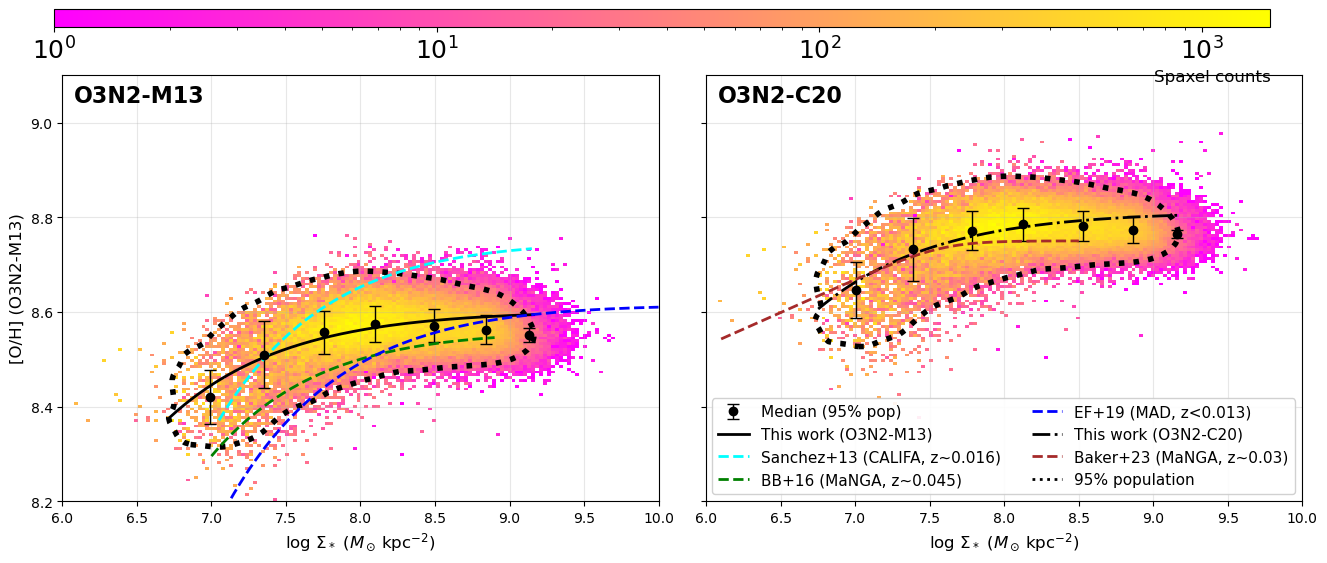


COMPLETED: Two-panel rMZR comparison (strict, EW(H$\alpha$)>=6.0)
Galaxies included: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Excluded: NGC4383


In [3]:
# ------------------------------------------------------------------
# rMZR comparison: O3N2-M13 vs O3N2-C20 (strict selection)
# Strict sample = HII spaxels with EW(H$\\alpha$) >= 6
# Two-panel layout:
#   Left : rMZR 2D histogram (O3N2-M13) with literature curves
#   Right: rMZR 2D histogram (O3N2-C20) with Baker+23 curve
# Color-coded by spaxel counts (shared log-scale colorbar, spring colormap)
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D
from pathlib import Path
from astropy.io import fits
import scipy.ndimage as ndimage
from scipy.optimize import curve_fit

EW_STRICT_MIN = 6.0


def load_maps_for_comparison(gal):
    """Load Sigma_* plus O3N2 metallicities and EW(H$\\alpha$) map."""
    with fits.open(f"{gal}_SPATIAL_BINNING_maps_extended.fits") as h:
        sigM = h["LOGMASS_SURFACE_DENSITY"].data
    with fits.open(f"{gal}_gas_BIN_maps_extended.fits") as h:
        oh_o3n2_m13_HII = h["O_H_O3N2_M13_HII"].data
        oh_o3n2_c20_HII = h["O_H_O3N2_C20_HII"].data
    with fits.open(f"{gal}_v0.7dev_gas_BIN_maps.fits") as h:
        ew_ha = h["HA6562_EW"].data

    return sigM, oh_o3n2_m13_HII, oh_o3n2_c20_HII, ew_ha


def calculate_binned_stats(x_data, y_data, bin_width=0.4, min_pixels=20):
    """Calculate median and std in bins; keep bins with >= min_pixels unique points."""
    x_data = np.asarray(x_data)
    y_data = np.asarray(y_data)

    finite = np.isfinite(x_data) & np.isfinite(y_data)
    x_data = x_data[finite]
    y_data = y_data[finite]

    if x_data.size == 0:
        empty_f = np.array([], dtype=float)
        empty_i = np.array([], dtype=int)
        return empty_f, empty_f, empty_f, empty_i, empty_i

    x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
    if x_min == x_max:
        bin_edges = np.array([x_min - bin_width / 2.0, x_max + bin_width / 2.0])
    else:
        bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
        if bin_edges.size < 2:
            bin_edges = np.array([x_min - bin_width / 2.0, x_max + bin_width / 2.0])

    medians, stds, counts, valid_centers, valid_bin_indices = [], [], [], [], []
    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        in_bin = (x_data >= bin_start) & (x_data < bin_end)
        x_in_bin = x_data[in_bin]
        y_in_bin = y_data[in_bin]
        if y_in_bin.size == 0:
            continue
        if len(np.unique(y_in_bin)) >= min_pixels:
            x_median = np.median(x_in_bin)
            medians.append(np.median(y_in_bin))
            stds.append(np.std(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(x_median)
            valid_bin_indices.append(i)

    return (
        np.array(valid_centers),
        np.array(medians),
        np.array(stds),
        np.array(counts),
        np.array(valid_bin_indices),
    )


def mzr_model(x, a, b, c):
    return a + b * (x - c) * np.exp(-(x - c))


def compute_density_mask(x_vals, y_vals, x_range, y_range, nbins=100, sigma=2.0, return_contour=False):
    """Return mask for points inside the 95% density contour within given ranges."""
    mask_finite = np.isfinite(x_vals) & np.isfinite(y_vals)
    if not np.any(mask_finite):
        empty_mask = np.zeros_like(x_vals, dtype=bool)
        return (empty_mask, None, None) if return_contour else empty_mask

    x = x_vals[mask_finite]
    y = y_vals[mask_finite]

    H, xedges, yedges = np.histogram2d(x, y, bins=nbins, range=[x_range, y_range])
    H_smooth = ndimage.gaussian_filter(H, sigma=sigma)

    H_flat = np.sort(H_smooth.ravel())[::-1]
    H_cumsum = np.cumsum(H_flat)
    level_idx = np.searchsorted(H_cumsum, 0.95 * H_cumsum[-1])
    level_95 = H_flat[level_idx]

    x_centers = (xedges[:-1] + xedges[1:]) / 2
    y_centers = (yedges[:-1] + yedges[1:]) / 2
    X, Y = np.meshgrid(x_centers, y_centers)

    dx = (x_range[1] - x_range[0]) / nbins
    dy = (y_range[1] - y_range[0]) / nbins
    x_idx = (x - x_range[0]) / dx - 0.5
    y_idx = (y - y_range[0]) / dy - 0.5
    densities = ndimage.map_coordinates(H_smooth, [x_idx, y_idx], order=1, mode="constant", cval=0.0)

    mask_local = densities >= level_95
    full_mask = np.zeros_like(x_vals, dtype=bool)
    full_mask[np.where(mask_finite)[0]] = mask_local

    if return_contour:
        return full_mask, level_95, (X, Y, H_smooth)
    return full_mask


def plot_literature_mzr_fits(ax, show_legend=True):
    """Overlay literature rMZR curves (Sanchez+13, BB+16, EF+19)."""
    plot_data = []
    x_sanchez = np.linspace(7.05, 9.15, 200)
    a5, b5, c5 = 8.74, 0.013, 9.50
    y_sanchez13 = a5 + b5 * (x_sanchez - c5) * np.exp(-(x_sanchez - c5))
    plot_data.append((x_sanchez, y_sanchez13, "Sanchez+13 (CALIFA, z~0.016)", "--", "cyan"))

    x_bb = np.linspace(7.0, 8.9, 200)
    a2, b2, c2 = 8.55, 0.014, 9.14
    y_bb16 = a2 + b2 * (x_bb - c2) * np.exp(-(x_bb - c2))
    plot_data.append((x_bb, y_bb16, "BB+16 (MaNGA, z~0.045)", "--", "green"))

    x_ef = np.linspace(6.5, 10.0, 200)
    a4, b4, c4 = 8.61, 0.008, 10.0
    y_ef17 = a4 + b4 * (x_ef - c4) * np.exp(-(x_ef - c4))
    plot_data.append((x_ef, y_ef17, "EF+19 (MAD, z<0.013)", "--", "blue"))

    handles = []
    for x, y, label, linestyle, color in plot_data:
        (line,) = ax.plot(x, y, label=label if show_legend else None, linewidth=2, linestyle=linestyle, color=color)
        handles.append(line)
    return handles


def plot_literature_baker(ax, show_legend=True):
    """Overlay Baker+23 collapsed rFMR curve."""
    x_baker = np.linspace(6.1, 8.5, 200)
    logSigmaSFR_ref = -2.0
    Z0_B = 8.75
    gamma_B = 0.14
    phi_B = 2.73
    m0_B = 8.58
    m1_B = 0.50
    logM0_B = m0_B + m1_B * logSigmaSFR_ref
    M0_B = 10.0 ** logM0_B
    Sigma_star_B = 10.0 ** x_baker
    y_baker23 = Z0_B - (gamma_B / phi_B) * np.log10(1.0 + (Sigma_star_B / M0_B) ** (-phi_B))

    (line,) = ax.plot(
        x_baker,
        y_baker23,
        label="Baker+23 (MaNGA, z~0.03)" if show_legend else None,
        linewidth=2,
        linestyle="--",
        color="brown",
    )
    return [line]


bins = sorted(Path(".").glob("*_SPATIAL_BINNING_maps_extended.fits"))
galaxies = [f.name.split("_")[0] for f in bins]
excluded_galaxies = {"NGC4383"}
included_galaxies = []

all_logSigmaM_m13 = []
all_oh_o3n2_m13 = []
all_logSigmaM_c20 = []
all_oh_o3n2_c20 = []

print("=" * 80)
print(f"Collecting strict data (HII + EW(H$\\alpha$)>={EW_STRICT_MIN:.1f}) for O3N2-M13 and O3N2-C20...")
print("=" * 80)

for gal in galaxies:
    if gal in excluded_galaxies:
        print(f"  {gal}: excluded from analysis")
        continue

    bin_file = Path(f"{gal}_SPATIAL_BINNING_maps_extended.fits")
    gas_file = Path(f"{gal}_gas_BIN_maps_extended.fits")
    ew_file = Path(f"{gal}_v0.7dev_gas_BIN_maps.fits")

    if not (bin_file.exists() and gas_file.exists() and ew_file.exists()):
        print(f"  {gal}: required file(s) not found")
        continue

    try:
        sigM, oh_m13_hii, oh_c20_hii, ew_ha = load_maps_for_comparison(gal)
    except Exception as e:
        print(f"  {gal}: failed to load maps ({e})")
        continue

    if not (sigM.shape == oh_m13_hii.shape == oh_c20_hii.shape == ew_ha.shape):
        print(f"  {gal}: shape mismatch, skipping")
        print(
            f"    shapes: SigmaM={sigM.shape}, M13={oh_m13_hii.shape}, "
            f"C20={oh_c20_hii.shape}, EW={ew_ha.shape}"
        )
        continue

    included_galaxies.append(gal)

    hii_mask_m13 = np.isfinite(sigM) & np.isfinite(oh_m13_hii)
    hii_mask_c20 = np.isfinite(sigM) & np.isfinite(oh_c20_hii)
    ew_mask = np.isfinite(ew_ha) & (ew_ha >= EW_STRICT_MIN)

    strict_mask_m13 = hii_mask_m13 & ew_mask
    strict_mask_c20 = hii_mask_c20 & ew_mask

    print(
        f"  {gal}: M13 HII={np.sum(hii_mask_m13)}, M13 strict={np.sum(strict_mask_m13)}; "
        f"C20 HII={np.sum(hii_mask_c20)}, C20 strict={np.sum(strict_mask_c20)}"
    )

    all_logSigmaM_m13.extend(sigM[strict_mask_m13].flatten())
    all_oh_o3n2_m13.extend(oh_m13_hii[strict_mask_m13].flatten())

    all_logSigmaM_c20.extend(sigM[strict_mask_c20].flatten())
    all_oh_o3n2_c20.extend(oh_c20_hii[strict_mask_c20].flatten())

all_logSigmaM_m13 = np.array(all_logSigmaM_m13)
all_oh_o3n2_m13 = np.array(all_oh_o3n2_m13)
all_logSigmaM_c20 = np.array(all_logSigmaM_c20)
all_oh_o3n2_c20 = np.array(all_oh_o3n2_c20)

if all_logSigmaM_m13.size == 0:
    raise RuntimeError("No strict spaxels available for O3N2-M13.")
if all_logSigmaM_c20.size == 0:
    raise RuntimeError("No strict spaxels available for O3N2-C20.")

print(
    f"\nTotal combined strict pixels: "
    f"M13={len(all_oh_o3n2_m13)}, C20={len(all_oh_o3n2_c20)}"
)

# Plot setup
common_ylim = (8.2, 9.1)
x_range_rMZR = (6, 10)
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True, sharex=True)
plt.subplots_adjust(wspace=0.08, top=0.82)
ax_left, ax_right = axes

# Left panel: O3N2-M13
print("\n--- Left panel: O3N2-M13 rMZR (strict) ---")
mask_m13 = np.isfinite(all_logSigmaM_m13) & np.isfinite(all_oh_o3n2_m13)
hist_m13, xedges_m13, yedges_m13 = np.histogram2d(
    all_logSigmaM_m13[mask_m13],
    all_oh_o3n2_m13[mask_m13],
    bins=150,
    range=[x_range_rMZR, common_ylim],
)

mask_95_m13, level_95_m13, contour_data_m13 = compute_density_mask(
    all_logSigmaM_m13,
    all_oh_o3n2_m13,
    x_range_rMZR,
    common_ylim,
    return_contour=True,
)

img_m13 = ax_left.pcolormesh(
    xedges_m13,
    yedges_m13,
    np.ma.masked_where(hist_m13.T == 0, hist_m13.T),
    cmap="spring",
    norm=LogNorm(vmin=1),
    shading="auto",
)

if contour_data_m13 is not None and level_95_m13 is not None:
    ax_left.contour(
        contour_data_m13[0],
        contour_data_m13[1],
        contour_data_m13[2].T,
        levels=[level_95_m13],
        colors="k",
        linewidths=4,
        linestyles=":",
    )

mass_centers_m13, medians_m13, stds_m13, counts_median_m13, valid_idx_m13 = calculate_binned_stats(
    all_logSigmaM_m13[mask_95_m13],
    all_oh_o3n2_m13[mask_95_m13],
    bin_width=0.4,
    min_pixels=20,
)

median_left = None
if len(mass_centers_m13) > 1:
    median_left = ax_left.errorbar(
        mass_centers_m13,
        medians_m13,
        yerr=stds_m13,
        fmt="o",
        color="k",
        markersize=6,
        linewidth=1,
        capsize=4,
        label="Median (95% pop)",
    )

p0 = [8.5, 0.0002, 12.5]
bounds = ([8.0, 0.0, 10.0], [9.0, 0.1, 15.0])
fit_line_left = None
x_fit_m13 = None
y_fit_m13 = None
try:
    popt_m13, pcov_m13 = curve_fit(
        mzr_model,
        all_logSigmaM_m13[mask_95_m13],
        all_oh_o3n2_m13[mask_95_m13],
        p0=p0,
        bounds=bounds,
        maxfev=5000,
    )
    x_fit_m13 = np.linspace(np.min(all_logSigmaM_m13[mask_95_m13]), np.max(all_logSigmaM_m13[mask_95_m13]), 150)
    y_fit_m13 = mzr_model(x_fit_m13, *popt_m13)
    (fit_line_left,) = ax_left.plot(x_fit_m13, y_fit_m13, "k-", linewidth=2, label="This work (O3N2-M13)")
    perr_m13 = np.sqrt(np.diag(pcov_m13))
    print(
        f"M13 fit: a={popt_m13[0]:.3f} +- {perr_m13[0]:.3f}, "
        f"b={popt_m13[1]:.5f} +- {perr_m13[1]:.5f}, "
        f"c={popt_m13[2]:.3f} +- {perr_m13[2]:.3f}"
    )
except Exception as e:
    print(f"M13 fit failed: {e}")

lit_handles_left = plot_literature_mzr_fits(ax_left, show_legend=True)

ax_left.set_ylabel("[O/H] (O3N2-M13)", fontsize=12)
ax_left.set_xlim(*x_range_rMZR)
ax_left.set_ylim(*common_ylim)
ax_left.grid(True, alpha=0.3)
ax_left.text(0.02, 0.98, "O3N2-M13", transform=ax_left.transAxes, ha="left", va="top", fontsize=16, fontweight="bold")

# Right panel: O3N2-C20
print("\n--- Right panel: O3N2-C20 rMZR (strict) ---")
mask_c20 = np.isfinite(all_logSigmaM_c20) & np.isfinite(all_oh_o3n2_c20)
hist_c20, xedges_c20, yedges_c20 = np.histogram2d(
    all_logSigmaM_c20[mask_c20],
    all_oh_o3n2_c20[mask_c20],
    bins=150,
    range=[x_range_rMZR, common_ylim],
)

mask_95_c20, level_95_c20, contour_data_c20 = compute_density_mask(
    all_logSigmaM_c20,
    all_oh_o3n2_c20,
    x_range_rMZR,
    common_ylim,
    return_contour=True,
)

img_c20 = ax_right.pcolormesh(
    xedges_c20,
    yedges_c20,
    np.ma.masked_where(hist_c20.T == 0, hist_c20.T),
    cmap="spring",
    norm=LogNorm(vmin=1),
    shading="auto",
)

if contour_data_c20 is not None and level_95_c20 is not None:
    ax_right.contour(
        contour_data_c20[0],
        contour_data_c20[1],
        contour_data_c20[2].T,
        levels=[level_95_c20],
        colors="k",
        linewidths=4,
        linestyles=":",
    )

mass_centers_c20, medians_c20, stds_c20, counts_median_c20, valid_idx_c20 = calculate_binned_stats(
    all_logSigmaM_c20[mask_95_c20],
    all_oh_o3n2_c20[mask_95_c20],
    bin_width=0.4,
    min_pixels=20,
)

fit_line_right = None
median_right = None
x_fit_c20 = None
y_fit_c20 = None
if len(mass_centers_c20) > 1:
    median_right = ax_right.errorbar(
        mass_centers_c20,
        medians_c20,
        yerr=stds_c20,
        fmt="o",
        color="k",
        markersize=6,
        linewidth=1,
        capsize=4,
        label=None,
    )
    try:
        popt_c20, pcov_c20 = curve_fit(
            mzr_model,
            all_logSigmaM_c20[mask_95_c20],
            all_oh_o3n2_c20[mask_95_c20],
            p0=p0,
            bounds=bounds,
            maxfev=5000,
        )
        x_fit_c20 = np.linspace(np.min(all_logSigmaM_c20[mask_95_c20]), np.max(all_logSigmaM_c20[mask_95_c20]), 150)
        y_fit_c20 = mzr_model(x_fit_c20, *popt_c20)
        (fit_line_right,) = ax_right.plot(x_fit_c20, y_fit_c20, "k-.", linewidth=2, label="This work (O3N2-C20)")
        perr_c20 = np.sqrt(np.diag(pcov_c20))
        print(
            f"C20 fit: a={popt_c20[0]:.3f} +- {perr_c20[0]:.3f}, "
            f"b={popt_c20[1]:.5f} +- {perr_c20[1]:.5f}, "
            f"c={popt_c20[2]:.3f} +- {perr_c20[2]:.3f}"
        )
    except Exception as e:
        print(f"C20 fit failed: {e}")

baker_handles = plot_literature_baker(ax_right, show_legend=True)
ax_right.set_xlim(*x_range_rMZR)
ax_right.set_ylim(*common_ylim)
ax_right.grid(True, alpha=0.3)
ax_right.set_xlabel(r"$\log\,\Sigma_* \ (M_\odot\,\mathrm{kpc}^{-2})$", fontsize=12)
ax_left.set_xlabel(r"$\log\,\Sigma_* \ (M_\odot\,\mathrm{kpc}^{-2})$", fontsize=12)
ax_right.text(0.02, 0.98, "O3N2-C20", transform=ax_right.transAxes, ha="left", va="top", fontsize=16, fontweight="bold")

# Consolidated legend on right panel
contour_handle = Line2D([0], [0], color="k", linestyle=":", linewidth=2, label="95% population")
legend_handles = []
legend_labels = []
for h in [median_left, fit_line_left]:
    if h:
        legend_handles.append(h)
        legend_labels.append(h.get_label())
for h in lit_handles_left:
    legend_handles.append(h)
    legend_labels.append(h.get_label())
for h in [fit_line_right]:
    if h:
        legend_handles.append(h)
        legend_labels.append(h.get_label())
for h in baker_handles:
    legend_handles.append(h)
    legend_labels.append(h.get_label())
legend_handles.append(contour_handle)
legend_labels.append(contour_handle.get_label())
if legend_handles:
    ax_right.legend(legend_handles, legend_labels, loc="lower right", fontsize=11, framealpha=0.9, ncol=2)

# Shared log-scale colorbar (top, spanning both panels)
vmax_shared = np.nanmax([hist_m13.max(), hist_c20.max()]) if hist_m13.size and hist_c20.size else None
if vmax_shared is not None and vmax_shared > 0:
    norm = LogNorm(vmin=1, vmax=vmax_shared)
    img_m13.set_norm(norm)
    img_c20.set_norm(norm)
    cax = fig.add_axes([0.12, 0.9, 0.76, 0.03])
    cbar = fig.colorbar(img_m13, cax=cax, orientation="horizontal")
    cbar.set_label("Spaxel counts", fontsize=12, loc="right")
    cbar.ax.tick_params(labelsize=18)

# plt.savefig("Plot_Paper_1/MAUVE_MUSE_rMZR_O3N2M13_vs_C20_counts_StrictEW6.png", dpi=600, bbox_inches="tight")
# plt.savefig("Plot_Paper_1/MAUVE_MUSE_rMZR_O3N2M13_vs_C20_counts_StrictEW6.pdf", bbox_inches="tight")
plt.show()

print("\n" + "=" * 80)
print(f"COMPLETED: Two-panel rMZR comparison (strict, EW(H$\\alpha$)>={EW_STRICT_MIN:.1f})")
print("=" * 80)
print(f"Galaxies included: {', '.join(included_galaxies)}")
print(f"Excluded: {', '.join(sorted(excluded_galaxies))}")

STEP 1: Collecting strict spaxels (HII and EW(H$\alpha$)>=6.0)...
  IC3392: HII=14897 pixels, Strict=13990 pixels
  NGC4064: HII=7019 pixels, Strict=6272 pixels
  NGC4192: HII=145884 pixels, Strict=136278 pixels
  NGC4293: HII=5546 pixels, Strict=515 pixels
  NGC4298: HII=156483 pixels, Strict=145866 pixels
  NGC4330: HII=39868 pixels, Strict=35832 pixels
  NGC4383: excluded from analysis
  NGC4396: HII=77468 pixels, Strict=77077 pixels
  NGC4419: HII=7323 pixels, Strict=5720 pixels
  NGC4457: HII=6347 pixels, Strict=5852 pixels
  NGC4501: HII=261238 pixels, Strict=244720 pixels
  NGC4522: HII=35475 pixels, Strict=34498 pixels
  NGC4694: HII=2284 pixels, Strict=1989 pixels
  NGC4698: HII=10086 pixels, Strict=5470 pixels

Total combined strict pixels: 714079

STEP 2: Defining 8 SFR bins for rMZR
  Bin 1: <-3.5
  Bin 2: -3.5--3.0
  Bin 3: -3.0--2.5
  Bin 4: -2.5--2.0
  Bin 5: -2.0--1.5
  Bin 6: -1.5--1.0
  Bin 7: -1.0--0.5
  Bin 8: >-0.5

STEP 3: Defining 8 Sigma_* bins for Z_gas-Sigma_S

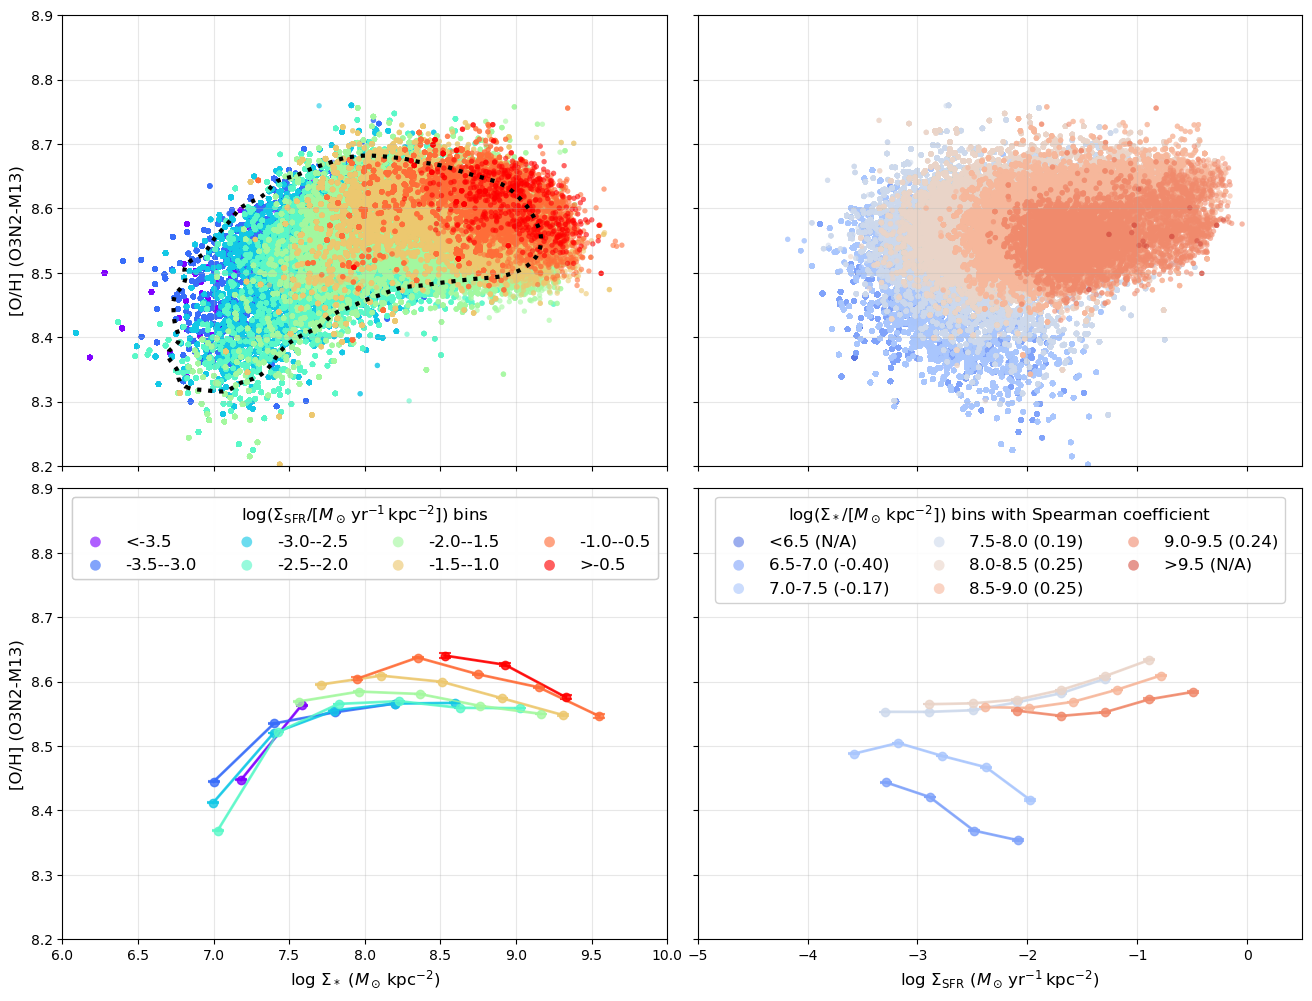


COMPLETED: Combined rMZR and Z_gas-Sigma_SFR analysis (O3N2-M13, strict)
Successfully created 2x2 subplot figure showing strict spaxels from 13 galaxies
Galaxies included: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Excluded: NGC4383

Panel summary:
  Top-left: rMZR scatter (8 Sigma_SFR bins)
  Top-right: Z_gas-Sigma_SFR scatter (8 Sigma_* bins)
  Bottom-left: rMZR median trends (8 Sigma_SFR bins)
  Bottom-right: Z_gas-Sigma_SFR median trends (8 Sigma_* bins)
  Shared y-range: 8.2 to 8.9


In [4]:
# ------------------------------------------------------------------
# Combined Analysis: rMZR and Z_gas-Sigma_SFR relation - Strict sample
# Strict sample = HII spaxels with EW(H$\\alpha$) >= 6
# Using O3N2-M13 indicator only
# 2x2 subplot layout:
#   Top-left: rMZR scatter
#   Top-right: Z_gas-Sigma_SFR scatter
#   Bottom-left: rMZR median trends
#   Bottom-right: Z_gas-Sigma_SFR median trends
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
import scipy.stats as stats
import scipy.ndimage as ndimage

EW_STRICT_MIN = 6.0


def load_maps_o3n2_m13(gal):
    """Load O3N2-M13 metallicity maps and H$\\alpha$ EW map for strict selection."""
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data

    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_o3n2_m13_HII = h['O_H_O3N2_M13_HII'].data

    with fits.open(f'{gal}_v0.7dev_gas_BIN_maps.fits') as h:
        ew_ha = h['HA6562_EW'].data

    return sigM, sigSFR_HII, oh_o3n2_m13_HII, ew_ha


def calculate_binned_stats(x_data, y_data, bin_width=0.4, min_pixels=20):
    """Calculate median and std in bins; keep bins with >= min_pixels unique datapoints."""
    x_data = np.asarray(x_data)
    y_data = np.asarray(y_data)

    finite = np.isfinite(x_data) & np.isfinite(y_data)
    x_data = x_data[finite]
    y_data = y_data[finite]

    if x_data.size == 0:
        empty_f = np.array([], dtype=float)
        empty_i = np.array([], dtype=int)
        return empty_f, empty_f, empty_f, empty_i, empty_i

    x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
    if x_min == x_max:
        bin_edges = np.array([x_min - bin_width / 2.0, x_max + bin_width / 2.0])
    else:
        bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
        if bin_edges.size < 2:
            bin_edges = np.array([x_min - bin_width / 2.0, x_max + bin_width / 2.0])

    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    medians, stds, counts, valid_centers, valid_bin_indices = [], [], [], [], []
    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        in_bin = (x_data >= bin_start) & (x_data < bin_end)
        y_in_bin = y_data[in_bin]
        if y_in_bin.size == 0:
            continue
        if len(np.unique(y_in_bin)) >= min_pixels:
            medians.append(np.median(y_in_bin))
            stds.append(np.std(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])
            valid_bin_indices.append(i)

    return (
        np.array(valid_centers),
        np.array(medians),
        np.array(stds),
        np.array(counts),
        np.array(valid_bin_indices),
    )


def compute_density_mask(x_vals, y_vals, x_range, y_range, nbins=100, sigma=2.0, return_contour=False):
    """Return mask for points inside the 95% density contour within given ranges."""
    mask_finite = np.isfinite(x_vals) & np.isfinite(y_vals)
    if not np.any(mask_finite):
        empty_mask = np.zeros_like(x_vals, dtype=bool)
        return (empty_mask, None, None) if return_contour else empty_mask

    x = x_vals[mask_finite]
    y = y_vals[mask_finite]

    H, xedges, yedges = np.histogram2d(x, y, bins=nbins, range=[x_range, y_range])
    H_smooth = ndimage.gaussian_filter(H, sigma=sigma)

    H_flat = np.sort(H_smooth.ravel())[::-1]
    H_cumsum = np.cumsum(H_flat)
    level_idx = np.searchsorted(H_cumsum, 0.95 * H_cumsum[-1])
    level_95 = H_flat[level_idx]

    x_centers = (xedges[:-1] + xedges[1:]) / 2
    y_centers = (yedges[:-1] + yedges[1:]) / 2
    X, Y = np.meshgrid(x_centers, y_centers)

    dx = (x_range[1] - x_range[0]) / nbins
    dy = (y_range[1] - y_range[0]) / nbins
    x_idx = (x - x_range[0]) / dx - 0.5
    y_idx = (y - y_range[0]) / dy - 0.5
    densities = ndimage.map_coordinates(H_smooth, [x_idx, y_idx], order=1, mode='constant', cval=0.0)

    mask_local = densities >= level_95
    full_mask = np.zeros_like(x_vals, dtype=bool)
    full_mask[np.where(mask_finite)[0]] = mask_local

    if return_contour:
        return full_mask, level_95, (X, Y, H_smooth)
    return full_mask


bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in bins]
excluded_galaxies = {'NGC4383'}
included_galaxies = []

all_logSigmaM_strict = []
all_logSigmaSFR_strict = []
all_oh_o3n2_m13_strict = []

print('=' * 80)
print(f'STEP 1: Collecting strict spaxels (HII and EW(H$\\alpha$)>={EW_STRICT_MIN:.1f})...')
print('=' * 80)

for gal in galaxies:
    if gal in excluded_galaxies:
        print(f'  {gal}: excluded from analysis')
        continue

    bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')
    gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')
    ew_file = Path(f'{gal}_v0.7dev_gas_BIN_maps.fits')

    if not (bin_file.exists() and gas_file.exists() and ew_file.exists()):
        print(f'  {gal}: required file(s) not found')
        continue

    try:
        logSigmaM, logSigmaSFR_HII, oh_o3n2_m13_HII, ew_ha = load_maps_o3n2_m13(gal)
    except Exception as e:
        print(f'  {gal}: failed to load maps ({e})')
        continue

    if not (logSigmaM.shape == logSigmaSFR_HII.shape == oh_o3n2_m13_HII.shape == ew_ha.shape):
        print(f'  {gal}: shape mismatch, skipping')
        print(
            f'    shapes: SigmaM={logSigmaM.shape}, '
            f'SigmaSFR_HII={logSigmaSFR_HII.shape}, '
            f'OH={oh_o3n2_m13_HII.shape}, EW={ew_ha.shape}'
        )
        continue

    included_galaxies.append(gal)

    hii_mask = np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & np.isfinite(oh_o3n2_m13_HII)
    strict_mask = hii_mask & np.isfinite(ew_ha) & (ew_ha >= EW_STRICT_MIN)

    print(
        f'  {gal}: HII={np.sum(hii_mask)} pixels, '
        f'Strict={np.sum(strict_mask)} pixels'
    )

    all_logSigmaM_strict.extend(logSigmaM[strict_mask].flatten())
    all_logSigmaSFR_strict.extend(logSigmaSFR_HII[strict_mask].flatten())
    all_oh_o3n2_m13_strict.extend(oh_o3n2_m13_HII[strict_mask].flatten())

all_logSigmaM_strict = np.array(all_logSigmaM_strict)
all_logSigmaSFR_strict = np.array(all_logSigmaSFR_strict)
all_oh_o3n2_m13_strict = np.array(all_oh_o3n2_m13_strict)

if all_logSigmaM_strict.size == 0:
    raise RuntimeError(f'No strict spaxels available after EW(H$\\alpha$)>={EW_STRICT_MIN:.1f} selection.')

print(f'\nTotal combined strict pixels: {len(all_logSigmaM_strict)}')

print('\n' + '=' * 80)
print('STEP 2: Defining 8 SFR bins for rMZR')
print('=' * 80)
n_bins = 8
sfr_bin_edges = [-np.inf, -3.5, -3.0, -2.5, -2.0, -1.5, -1.0, -0.5, np.inf]
bin_labels = ['<-3.5', '-3.5--3.0', '-3.0--2.5', '-2.5--2.0', '-2.0--1.5', '-1.5--1.0', '-1.0--0.5', '>-0.5']
for i, label in enumerate(bin_labels):
    print(f'  Bin {i + 1}: {label}')
colors_sfr = plt.cm.rainbow(np.linspace(0, 1, n_bins))

print('\n' + '=' * 80)
print('STEP 3: Defining 8 Sigma_* bins for Z_gas-Sigma_SFR')
print('=' * 80)
n_bins_sigmaM = 8
sigmaM_bin_edges = [-np.inf, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, np.inf]
bin_labels_sigmaM = ['<6.5', '6.5-7.0', '7.0-7.5', '7.5-8.0', '8.0-8.5', '8.5-9.0', '9.0-9.5', '>9.5']
for i, label in enumerate(bin_labels_sigmaM):
    print(f'  Bin {i + 1}: {label}')
colors_sigmaM = plt.cm.coolwarm(np.linspace(0.1, 0.9, n_bins_sigmaM))

print('\n' + '=' * 80)
print('STEP 4: Creating combined 2x2 plot (O3N2-M13, strict selection)')
print('=' * 80)
common_ylim = (8.2, 8.9)
x_range_rMZR = (6, 10)
x_range_Zgas = (-5.0, 0.5)
print(f'\nUsing uniform y-axis range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}')

fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex='col', sharey='all')
plt.subplots_adjust(wspace=0.05, hspace=0.05)

oh_data_strict = all_oh_o3n2_m13_strict
calib_name = 'O3N2-M13'
print(f'\nProcessing {calib_name} calibration for strict sample:')
print(f'  Strict {calib_name} range: {np.min(oh_data_strict):.3f} to {np.max(oh_data_strict):.3f}')

ax_rMZR_scatter = axes[0, 0]
ax_Zgas_scatter = axes[0, 1]
ax_rMZR_median = axes[1, 0]
ax_Zgas_median = axes[1, 1]

mask_95_all_rMZR, level_95_all_rMZR, contour_data_rMZR = compute_density_mask(
    all_logSigmaM_strict,
    oh_data_strict,
    x_range_rMZR,
    common_ylim,
    return_contour=True,
)

max_typical_yerr_rMZR = np.nan
max_typical_yerr_Zgas = np.nan

print('\n--- Processing rMZR (8 Sigma_SFR bins) ---')
legend_handles_sfr, legend_labels_sfr = [], []
valid_bins_rMZR = 0
for i in range(n_bins):
    in_bin = (all_logSigmaSFR_strict >= sfr_bin_edges[i]) & (all_logSigmaSFR_strict < sfr_bin_edges[i + 1])
    n_pixels = np.sum(in_bin)
    if n_pixels >= 10:
        x_bin_all = all_logSigmaM_strict[in_bin]
        y_bin_all = oh_data_strict[in_bin]

        scatter = ax_rMZR_scatter.scatter(
            x_bin_all,
            y_bin_all,
            c=[colors_sfr[i]],
            s=15,
            alpha=0.6,
            edgecolors='none',
            rasterized=True,
        )
        legend_handles_sfr.append(scatter)
        legend_labels_sfr.append(bin_labels[i])

        mask_95_bin = compute_density_mask(x_bin_all, y_bin_all, x_range_rMZR, common_ylim)
        x_bin = x_bin_all[mask_95_bin]
        y_bin = y_bin_all[mask_95_bin]

        if len(x_bin) >= 10:
            centers, medians, stds, counts, valid_bin_indices = calculate_binned_stats(
                x_bin,
                y_bin,
                bin_width=0.4,
                min_pixels=20,
            )
            if len(centers) > 1:
                yerr = stds / np.sqrt(counts)
                typical_yerr = np.nanmedian(yerr)
                print(f'    rMZR bin {i + 1} {bin_labels[i]}: typical yerr (median sigma/sqrt(N)) = {typical_yerr:.4f}')
                if np.isfinite(typical_yerr):
                    max_typical_yerr_rMZR = np.nanmax([max_typical_yerr_rMZR, typical_yerr])

                ax_rMZR_median.errorbar(
                    centers,
                    medians,
                    yerr=yerr,
                    color=colors_sfr[i],
                    marker='o',
                    markersize=6,
                    linewidth=1,
                    capsize=4,
                    capthick=1.5,
                    alpha=0.8,
                )

                for j in range(len(valid_bin_indices) - 1):
                    if valid_bin_indices[j + 1] - valid_bin_indices[j] == 1:
                        ax_rMZR_median.plot(
                            [centers[j], centers[j + 1]],
                            [medians[j], medians[j + 1]],
                            color=colors_sfr[i],
                            linewidth=2,
                            alpha=0.8,
                        )
                valid_bins_rMZR += 1

if contour_data_rMZR is not None and level_95_all_rMZR is not None:
    ax_rMZR_scatter.contour(
        contour_data_rMZR[0],
        contour_data_rMZR[1],
        contour_data_rMZR[2].T,
        levels=[level_95_all_rMZR],
        colors='k',
        linewidths=3,
        linestyles=':',
    )

ax_rMZR_scatter.set_ylabel(f'[O/H] ({calib_name})', fontsize=12)
ax_rMZR_scatter.grid(True, alpha=0.3)
ax_rMZR_scatter.set_xlim(*x_range_rMZR)
ax_rMZR_scatter.set_ylim(common_ylim)

ax_rMZR_median.set_xlabel(r'$\log\,\Sigma_* \ (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
ax_rMZR_median.set_ylabel(f'[O/H] ({calib_name})', fontsize=12)
ax_rMZR_median.grid(True, alpha=0.3)
ax_rMZR_median.set_xlim(*x_range_rMZR)
ax_rMZR_median.set_ylim(common_ylim)

if legend_handles_sfr:
    legend1 = ax_rMZR_median.legend(
        legend_handles_sfr,
        legend_labels_sfr,
        loc='upper center',
        ncol=4,
        fontsize=12,
        framealpha=0.9,
        title=r'$\log(\Sigma_\mathrm{SFR}/[M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2}])$ bins',
        title_fontsize=12,
    )
    legend1_handles = getattr(legend1, 'legend_handles', None)
    if legend1_handles is None:
        legend1_handles = getattr(legend1, 'legendHandles', [])
    for handle in legend1_handles:
        try:
            handle.set_sizes([60])
        except Exception:
            pass
    ax_rMZR_median.add_artist(legend1)

print(f'  rMZR valid bins: {valid_bins_rMZR}')

print('\n--- Processing Z_gas-Sigma_SFR (8 Sigma_* bins) ---')
legend_handles_sigmaM, legend_labels_sigmaM_display = [], []
valid_bins_Zgas = 0
for i in range(n_bins_sigmaM):
    in_bin = (all_logSigmaM_strict >= sigmaM_bin_edges[i]) & (all_logSigmaM_strict < sigmaM_bin_edges[i + 1])
    n_pixels = np.sum(in_bin)

    if n_pixels >= 10:
        x_bin_all = all_logSigmaSFR_strict[in_bin]
        y_bin_all = oh_data_strict[in_bin]

        scatter = ax_Zgas_scatter.scatter(
            x_bin_all,
            y_bin_all,
            c=[colors_sigmaM[i]],
            s=15,
            alpha=0.6,
            edgecolors='none',
            rasterized=True,
        )
        legend_handles_sigmaM.append(scatter)

        mask_95_bin = compute_density_mask(x_bin_all, y_bin_all, x_range_Zgas, common_ylim)
        x_bin = x_bin_all[mask_95_bin]
        y_bin = y_bin_all[mask_95_bin]

        spearman_text = 'N/A'
        if len(x_bin) > 1:
            y_mean, y_std = np.nanmean(y_bin), np.nanstd(y_bin)
            x_mean, x_std = np.nanmean(x_bin), np.nanstd(x_bin)
            mask_clip = (np.abs(y_bin - y_mean) <= 3 * y_std) & (np.abs(x_bin - x_mean) <= 3 * x_std)

            if np.any(mask_clip):
                x_clipped = x_bin[mask_clip]
                y_clipped = y_bin[mask_clip]
            else:
                x_clipped = x_bin
                y_clipped = y_bin

            centers, medians, stds, counts, valid_bin_indices = calculate_binned_stats(
                x_clipped,
                y_clipped,
                bin_width=0.4,
                min_pixels=20,
            )
            if len(centers) > 1:
                if len(x_clipped) > 10 and (np.unique(x_clipped).size > 1) and (np.unique(y_clipped).size > 1):
                    corr, _ = stats.spearmanr(x_clipped, y_clipped)
                    spearman_text = f'{corr:.2f}'

                yerr = stds / np.sqrt(counts)
                typical_yerr = np.nanmedian(yerr)
                print(f'    Zgas-SigmaSFR bin {i + 1} {bin_labels_sigmaM[i]}: typical yerr (median sigma/sqrt(N)) = {typical_yerr:.4f}')
                if np.isfinite(typical_yerr):
                    max_typical_yerr_Zgas = np.nanmax([max_typical_yerr_Zgas, typical_yerr])

                ax_Zgas_median.errorbar(
                    centers,
                    medians,
                    yerr=yerr,
                    color=colors_sigmaM[i],
                    marker='o',
                    markersize=6,
                    linewidth=1,
                    capsize=4,
                    capthick=1.5,
                    alpha=0.8,
                )
                for j in range(len(valid_bin_indices) - 1):
                    if valid_bin_indices[j + 1] - valid_bin_indices[j] == 1:
                        ax_Zgas_median.plot(
                            [centers[j], centers[j + 1]],
                            [medians[j], medians[j + 1]],
                            color=colors_sigmaM[i],
                            linewidth=2,
                            alpha=0.8,
                        )
                valid_bins_Zgas += 1

        legend_labels_sigmaM_display.append(f"{bin_labels_sigmaM[i]} ({spearman_text})")

ax_Zgas_scatter.grid(True, alpha=0.3)
ax_Zgas_scatter.set_xlim(*x_range_Zgas)
ax_Zgas_scatter.set_ylim(common_ylim)

ax_Zgas_median.set_xlabel(r'$\log\,\Sigma_\mathrm{SFR} \ (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)
ax_Zgas_median.grid(True, alpha=0.3)
ax_Zgas_median.set_xlim(*x_range_Zgas)
ax_Zgas_median.set_ylim(common_ylim)

if legend_handles_sigmaM:
    legend2 = ax_Zgas_median.legend(
        legend_handles_sigmaM,
        legend_labels_sigmaM_display,
        loc='upper center',
        ncol=3,
        fontsize=12,
        framealpha=0.9,
        title=r'$\log(\Sigma_*/[M_\odot\,\mathrm{kpc}^{-2}])$ bins with Spearman coefficient',
        title_fontsize=12,
    )
    legend2_handles = getattr(legend2, 'legend_handles', None)
    if legend2_handles is None:
        legend2_handles = getattr(legend2, 'legendHandles', [])
    for handle in legend2_handles:
        try:
            handle.set_sizes([60])
        except Exception:
            pass

if valid_bins_Zgas == 0:
    ax_Zgas_median.text(
        0.5,
        0.5,
        'No valid median bins\nfor strict selection',
        transform=ax_Zgas_median.transAxes,
        ha='center',
        va='center',
        fontsize=12,
    )

print(f'  Z_gas-Sigma_SFR valid bins: {valid_bins_Zgas}')

# plt.savefig('Plot_Paper_1/MAUVE_MUSE_rMZR_Zgas_SigmaSFR_O3N2M13_StrictEW6.png', dpi=600, bbox_inches='tight')
# plt.savefig('Plot_Paper_1/MAUVE_MUSE_rMZR_Zgas_SigmaSFR_O3N2M13_StrictEW6.pdf', bbox_inches='tight')
plt.show()

print('\n' + '=' * 80)
print('COMPLETED: Combined rMZR and Z_gas-Sigma_SFR analysis (O3N2-M13, strict)')
print('=' * 80)
print(f'Successfully created 2x2 subplot figure showing strict spaxels from {len(included_galaxies)} galaxies')
print(f"Galaxies included: {', '.join(included_galaxies)}")
print(f"Excluded: {', '.join(sorted(excluded_galaxies))}")
print('\nPanel summary:')
print('  Top-left: rMZR scatter (8 Sigma_SFR bins)')
print('  Top-right: Z_gas-Sigma_SFR scatter (8 Sigma_* bins)')
print('  Bottom-left: rMZR median trends (8 Sigma_SFR bins)')
print('  Bottom-right: Z_gas-Sigma_SFR median trends (8 Sigma_* bins)')
print(f'  Shared y-range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}')

In [5]:
# ------------------------------------------------------------------
# 2x2 Combined figure: offset maps + Moran-like map + binned Σ* map (strict)
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gs_module
from matplotlib.colors import BoundaryNorm, SymLogNorm
import matplotlib.ticker as mticker
from matplotlib.ticker import ScalarFormatter

# Only focus on NGC4501 for this visualisation
galaxies = ['NGC4501']

# ------------------------------------------------------------------
# Define threshold parameter for linear/log colorbar transition and classification
# ------------------------------------------------------------------
threshold = 1  # Values between -threshold and +threshold use linear scale
EW_STRICT_MIN = 6.0  # Strict selection: EW(H$\\alpha$) >= 6

# ------------------------------------------------------------------
# 1.  Helper: read the required maps
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'
    ew_path = f'{gal}_v0.7dev_gas_BIN_maps.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists() and Path(ew_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
        binid_map = h_spatial['BINID'].data
        wcs = WCS(h_spatial['LOGMASS_SURFACE_DENSITY'].header)
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
        gas_header = h_gas['LOGSFR_SURFACE_DENSITY_HII'].header
    with fits.open(ew_path) as h_ew:
        ew_ha = h_ew['HA6562_EW'].data
    return sigM, sigSFR, oh_map, indicator_name, wcs, gas_header, binid_map, ew_ha, binid_map

for gal in galaxies:
    sigM, sigSFR, oh_o3n2_map, indicator_name, wcs_full, gas_header, ew_ha, binid_map = load_maps(gal)
    # Valid pixels across maps
    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_sigM = np.isfinite(sigM)
    valid_ew = np.isfinite(ew_ha) & (ew_ha >= EW_STRICT_MIN)
    valid_all = valid_sfr & valid_oh & valid_sigM & valid_ew
    print(f"{gal}: strict pixels = {np.sum(valid_all)} (EW(H$\\alpha$)>={EW_STRICT_MIN:.1f})")

    # ------------------------------------------------------------------
    # 2.  Calculate offset maps (relative to Σ* bin means)
    # ------------------------------------------------------------------
    # Define 12 Σ* bins
    n_bins = 12
    sigmaM_min = np.nanmin(sigM[valid_all])
    sigmaM_max = np.nanmax(sigM[valid_all])
    sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
    
    # Initialize offset maps
    sfr_offset = np.full_like(sigSFR, np.nan)
    oh_offset = np.full_like(oh_o3n2_map, np.nan)
    
    # Calculate offset for each Σ* bin
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        
        if np.sum(bin_mask) > 0:
            # Calculate bin mean and offset within this bin
            sfr_bin_mean = np.mean(sigSFR[bin_mask])
            oh_bin_mean = np.mean(oh_o3n2_map[bin_mask])
            
            sfr_offset[bin_mask] = sigSFR[bin_mask] - sfr_bin_mean
            oh_offset[bin_mask] = oh_o3n2_map[bin_mask] - oh_bin_mean
    
    sfr_offset_max = np.nanmax(np.abs(sfr_offset[valid_all]))
    oh_offset_max = np.nanmax(np.abs(oh_offset[valid_all]))
    
    # Global means for display purposes only
    sfr_mean = np.nanmean(sigSFR[valid_sfr])
    oh_mean = np.nanmean(oh_o3n2_map[valid_oh])

    # ------------------------------------------------------------------
    # 3.  Calculate local bivariate Moran-like map
    # ------------------------------------------------------------------
    def local_bivariate_moran_by_bin(A, B, valid_mask, binid_map, neighbourhood='queen'):
        """Local bivariate Moran-style statistic on adjacent spatial bins.

        Each valid BINID is treated as one graph node, using the mean A and B value
        of that bin. The resulting per-bin Moran value is expanded back to all
        valid pixels in the bin for plotting.
        """
        A = np.asarray(A, dtype=float)
        B = np.asarray(B, dtype=float)
        valid_mask = np.asarray(valid_mask, dtype=bool)
        binid_raw = np.asarray(binid_map, dtype=float)
        if A.shape != B.shape or A.shape != valid_mask.shape or A.shape != binid_raw.shape:
            raise ValueError('A, B, valid_mask, and binid_map must have the same shape')

        I_map = np.full(A.shape, np.nan)
        quad_map = np.zeros(A.shape, dtype=np.int16)
        finite_bin = np.isfinite(binid_raw) & (binid_raw >= 0)
        binid = np.full(A.shape, -1, dtype=np.int64)
        binid[finite_bin] = np.rint(binid_raw[finite_bin]).astype(np.int64)
        valid = valid_mask & np.isfinite(A) & np.isfinite(B) & (binid >= 0)
        valid_bins = np.unique(binid[valid])
        if valid_bins.size < 2:
            return I_map, quad_map

        max_bin = int(valid_bins.max())
        flat_bins = binid[valid].ravel()
        counts = np.bincount(flat_bins, minlength=max_bin + 1).astype(float)
        sum_A = np.bincount(flat_bins, weights=A[valid].ravel(), minlength=max_bin + 1)
        sum_B = np.bincount(flat_bins, weights=B[valid].ravel(), minlength=max_bin + 1)
        A_bin = np.full(max_bin + 1, np.nan)
        B_bin = np.full(max_bin + 1, np.nan)
        has_data = counts > 0
        A_bin[has_data] = sum_A[has_data] / counts[has_data]
        B_bin[has_data] = sum_B[has_data] / counts[has_data]

        A_vals = A_bin[valid_bins]
        B_vals = B_bin[valid_bins]
        A_std = np.nanstd(A_vals)
        B_std = np.nanstd(B_vals)
        if not np.isfinite(A_std) or not np.isfinite(B_std) or A_std == 0 or B_std == 0:
            return I_map, quad_map

        Az = np.full(max_bin + 1, np.nan)
        Bz = np.full(max_bin + 1, np.nan)
        Az[valid_bins] = (A_vals - np.nanmean(A_vals)) / A_std
        Bz[valid_bins] = (B_vals - np.nanmean(B_vals)) / B_std

        offsets = [(-1, 0), (1, 0), (0, -1), (0, 1)]
        if neighbourhood == 'queen':
            offsets += [(-1, -1), (-1, 1), (1, -1), (1, 1)]
        elif neighbourhood != 'rook':
            raise ValueError("neighbourhood must be 'rook' or 'queen'")

        adjacency = {int(b): set() for b in valid_bins}
        rows, cols = A.shape
        for dy, dx in offsets:
            y0 = max(0, -dy)
            y1 = rows - max(0, dy)
            x0 = max(0, -dx)
            x1 = cols - max(0, dx)
            src = (slice(y0, y1), slice(x0, x1))
            dst = (slice(y0 + dy, y1 + dy), slice(x0 + dx, x1 + dx))
            pair_valid = valid[src] & valid[dst] & (binid[src] != binid[dst])
            for left, right in zip(binid[src][pair_valid], binid[dst][pair_valid]):
                left = int(left)
                right = int(right)
                adjacency[left].add(right)
                adjacency[right].add(left)

        for b in valid_bins:
            b = int(b)
            neigh = sorted(adjacency[b])
            if not neigh:
                continue
            lag_B = np.nanmean(Bz[neigh])
            I_val = Az[b] * lag_B
            pixels = valid & (binid == b)
            I_map[pixels] = I_val
            if Az[b] >= 0 and lag_B >= 0:
                quad_map[pixels] = 1
            elif Az[b] < 0 and lag_B < 0:
                quad_map[pixels] = 2
            elif Az[b] >= 0 and lag_B < 0:
                quad_map[pixels] = 3
            else:
                quad_map[pixels] = 4

        return I_map, quad_map
    I_map, quad_map = local_bivariate_moran_by_bin(sfr_offset, oh_offset, valid_all, binid_map,
                                            neighbourhood='queen')

    # ------------------------------------------------------------------
    # Calculate statistics for three classes based on threshold
    # ------------------------------------------------------------------
    valid_I = np.isfinite(I_map)
    n_total = np.sum(valid_I)
    n_high = np.sum(I_map[valid_I] > threshold)
    n_mid = np.sum((I_map[valid_I] >= -threshold) & (I_map[valid_I] <= threshold))
    n_low = np.sum(I_map[valid_I] < -threshold)
    pct_high = (n_high / n_total * 100) if n_total > 0 else 0
    pct_mid = (n_mid / n_total * 100) if n_total > 0 else 0
    pct_low = (n_low / n_total * 100) if n_total > 0 else 0

    # ------------------------------------------------------------------
    # 4.  Create binned Σ* map
    # ------------------------------------------------------------------
    sigM_binned_map = np.full_like(sigM, np.nan)
    
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        
        # Assign bin center value
        bin_center = (sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2
        sigM_binned_map[bin_mask] = bin_center

    # ------------------------------------------------------------------
    # 5.  Prepare coordinate extent
    # ------------------------------------------------------------------
    wcs_celestial = WCS(gas_header).celestial
    y_size, x_size = sigSFR.shape
    x_coords = np.arange(x_size)
    y_coords = np.arange(y_size)
    xx, yy = np.meshgrid(x_coords, y_coords)
    ra, dec = wcs_celestial.pixel_to_world_values(xx, yy)
    extent = [ra.max(), ra.min(), dec.min(), dec.max()]

    # ------------------------------------------------------------------
    # 5b.  Scale bar: 1 kpc for 0.2 arcsec/pixel at 16.5 Mpc
    # ------------------------------------------------------------------
    pix_scale_arcsec = 0.2
    distance_mpc = 16.5
    kpc_arcsec = 206265.0 / (distance_mpc * 1000.0)
    scalebar_length_deg = kpc_arcsec / 3600.0

    def add_scalebar(ax, length_deg, label='1 kpc'):
        x0, x1 = ax.get_xlim()
        x_range = abs(x1 - x0)
        if x_range == 0:
            return
        frac_len = length_deg / x_range
        x_start = 0.05
        y_start = 0.95
        x_end = x_start + frac_len
        line, = ax.plot([x_start, x_end], [y_start, y_start], transform=ax.transAxes,
                        color='k', lw=3, clip_on=False)
        line.set_in_layout(False)
        txt = ax.text((x_start + x_end) / 2, y_start - 0.03, label,
                      transform=ax.transAxes, ha='center', va='top', color='k')
        txt.set_in_layout(False)

    # ------------------------------------------------------------------
    # 6.  2x2 figure: shared axes, equal aspect preserved, colorbars glued to axes
    # ------------------------------------------------------------------
    from mpl_toolkits.axes_grid1 import make_axes_locatable

    # Auto-derive a reasonable figsize from the map extent
    dx = abs(extent[1] - extent[0])   # RA span
    dy = abs(extent[3] - extent[2])   # Dec span
    data_ratio = (dx / dy) if dy > 0 else 1.0  # width / height

    panel_h = 4.2   # inches per panel height (tune once)
    panel_w = panel_h * data_ratio
    cbar_w = 0.35   # inches per colorbar (tune once)

    W = 2 * panel_w + 2 * cbar_w + 1.2
    H = 2 * panel_h + 0.8

    fig, axs = plt.subplots(
        2, 2, figsize=(W, H), sharex=True, sharey=True
    )

    # Make space for the appended colorbars (right margin matters)
    fig.subplots_adjust(
        left=0.07, right=0.96, bottom=0.07, top=0.98,
        wspace=0.20, hspace=0.06
    )

    ax1, ax2 = axs[0, 0], axs[0, 1]
    ax3, ax4 = axs[1, 0], axs[1, 1]

    def add_cbar(ax, im, label, size="3.5%", pad=0.02, labelpad=6, labelsize=11):
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size=size, pad=pad)
        cbar = fig.colorbar(im, cax=cax)
        cbar.set_label(label, fontsize=labelsize, labelpad=labelpad)
        return cbar

    # --- Ticks / formatting (readable RA, no +1.834e2)
    for ax in (ax1, ax2, ax3, ax4):
        ax.xaxis.set_major_locator(mticker.MaxNLocator(3))
        ax.yaxis.set_major_locator(mticker.MaxNLocator(5))
        ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

    # Hide inner tick labels
    plt.setp(ax1.get_xticklabels(), visible=False)
    plt.setp(ax2.get_xticklabels(), visible=False)
    plt.setp(ax2.get_yticklabels(), visible=False)
    plt.setp(ax4.get_yticklabels(), visible=False)

    # Axis labels (outer only)
    ax3.set_xlabel("RA (deg)", fontsize=16)
    ax4.set_xlabel("RA (deg)", fontsize=16)
    ax1.set_ylabel("Dec (deg)", fontsize=16)
    ax3.set_ylabel("Dec (deg)", fontsize=16)

    # ---- Panel 1: SFR offset
    im_sfr = ax1.imshow(
        np.ma.masked_invalid(sfr_offset),
        origin="lower", cmap="coolwarm",
        extent=extent, vmin=-sfr_offset_max, vmax=sfr_offset_max,
        aspect="equal"
    )
    add_scalebar(ax1, scalebar_length_deg, label="1 kpc")
    add_cbar(ax1, im_sfr, r'$\Delta\log\,\Sigma_{\mathrm{SFR}}$ (dex)', labelpad=4)

    # ---- Panel 2: OH offset
    im_oh = ax2.imshow(
        np.ma.masked_invalid(oh_offset),
        origin="lower", cmap="coolwarm",
        extent=extent, vmin=-oh_offset_max, vmax=oh_offset_max,
        aspect="equal"
    )
    add_cbar(ax2, im_oh, r'$\Delta$[O/H] (dex)')

    # ---- Panel 3: Moran-like
    vI = np.nanmax(np.abs(I_map))
    norm = SymLogNorm(linthresh=threshold, linscale=1.0, vmin=-vI, vmax=vI, base=10)

    imI = ax3.imshow(
        np.ma.masked_invalid(I_map),
        origin="lower", cmap="coolwarm",
        extent=extent, norm=norm,
        aspect="equal"
    )
    cbarI = add_cbar(
        ax3, imI,
        r'$z(\Delta\log\Sigma_{\rm SFR}) \times z_{\rm lag}(\Delta{\rm [O/H]})$'
    )

    # Keep your symmetric-log ticks logic
    max_pow = int(np.floor(np.log10(vI))) if vI > 0 else 0
    pos_ticks = [10**k for k in range(0, max_pow + 1) if 10**k <= vI]
    pos_ticks_filtered = [p for p in pos_ticks if p != threshold]
    neg_ticks_filtered = [-p for p in reversed(pos_ticks_filtered)]
    ticks = sorted(set(neg_ticks_filtered + [-threshold, 0.0, threshold] + pos_ticks_filtered))
    cbarI.set_ticks(ticks)
    cbarI.set_ticklabels([f"{t:g}" for t in ticks])

    legend_text = (
        rf'$I_i > {threshold}$: {pct_high:.1f}% (N={n_high})'
        '\n' + rf'$|I_i| \leq {threshold}$: {pct_mid:.1f}% (N={n_mid})'
        '\n' + rf'$I_i < -{threshold}$: {pct_low:.1f}% (N={n_low})'
    )
    ax3.text(
        0.98, 0.02, legend_text, transform=ax3.transAxes,
        fontsize=10, va="bottom", ha="right",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
    )

    # ---- Panel 4: binned Σ*
    cmap_discrete = plt.cm.inferno
    norm_discrete = BoundaryNorm(sigmaM_bin_edges, cmap_discrete.N)

    im_sigM_binned = ax4.imshow(
        np.ma.masked_invalid(sigM_binned_map),
        origin="lower", cmap=cmap_discrete, norm=norm_discrete,
        extent=extent,
        aspect="equal"
    )
    cbar_binned = add_cbar(
        ax4, im_sigM_binned,
        r'$\log\,\Sigma_*\;(M_\odot\,\mathrm{kpc}^{-2})$'
    )

    bin_centers = [(sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2 for i in range(n_bins)]
    cbar_binned.set_ticks(bin_centers)
    cbar_binned.set_ticklabels([f"{bc:.2f}" for bc in bin_centers])

    # fig.savefig(f'Plot_Paper_1/{gal}_correlation_map_moran.png', dpi=600, bbox_inches="tight", pad_inches=0.02)
    # fig.savefig(f'Plot_Paper_1/{gal}_correlation_map_moran.pdf', bbox_inches="tight", pad_inches=0.02)
    plt.show()

ValueError: too many values to unpack (expected 8)

In [ ]:
# ------------------------------------------------------------------
# 2x2 Combined figure: offset maps + Moran-like map + binned Σ* map (strict)
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gs_module
from matplotlib.colors import BoundaryNorm, SymLogNorm
import matplotlib.ticker as mticker
from matplotlib.ticker import ScalarFormatter

# Only focus on NGC4192 for this visualisation
galaxies = ['NGC4192']

# ------------------------------------------------------------------
# Define threshold parameter for linear/log colorbar transition and classification
# ------------------------------------------------------------------
threshold = 1  # Values between -threshold and +threshold use linear scale
EW_STRICT_MIN = 6.0  # Strict selection: EW(H$\\alpha$) >= 6

# ------------------------------------------------------------------
# 1.  Helper: read the required maps
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'
    ew_path = f'{gal}_v0.7dev_gas_BIN_maps.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists() and Path(ew_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
        binid_map = h_spatial['BINID'].data
        wcs = WCS(h_spatial['LOGMASS_SURFACE_DENSITY'].header)
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
        gas_header = h_gas['LOGSFR_SURFACE_DENSITY_HII'].header
    with fits.open(ew_path) as h_ew:
        ew_ha = h_ew['HA6562_EW'].data
    return sigM, sigSFR, oh_map, indicator_name, wcs, gas_header, binid_map, ew_ha, binid_map

for gal in galaxies:
    sigM, sigSFR, oh_o3n2_map, indicator_name, wcs_full, gas_header, ew_ha, binid_map = load_maps(gal)
    # Valid pixels across maps
    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_sigM = np.isfinite(sigM)
    valid_ew = np.isfinite(ew_ha) & (ew_ha >= EW_STRICT_MIN)
    valid_all = valid_sfr & valid_oh & valid_sigM & valid_ew
    print(f"{gal}: strict pixels = {np.sum(valid_all)} (EW(H$\\alpha$)>={EW_STRICT_MIN:.1f})")

    # ------------------------------------------------------------------
    # 2.  Calculate offset maps (relative to Σ* bin means)
    # ------------------------------------------------------------------
    # Define 12 Σ* bins
    n_bins = 12
    sigmaM_min = np.nanmin(sigM[valid_all])
    sigmaM_max = np.nanmax(sigM[valid_all])
    sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
    
    # Initialize offset maps
    sfr_offset = np.full_like(sigSFR, np.nan)
    oh_offset = np.full_like(oh_o3n2_map, np.nan)
    
    # Calculate offset for each Σ* bin
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        
        if np.sum(bin_mask) > 0:
            # Calculate bin mean and offset within this bin
            sfr_bin_mean = np.mean(sigSFR[bin_mask])
            oh_bin_mean = np.mean(oh_o3n2_map[bin_mask])
            
            sfr_offset[bin_mask] = sigSFR[bin_mask] - sfr_bin_mean
            oh_offset[bin_mask] = oh_o3n2_map[bin_mask] - oh_bin_mean
    
    sfr_offset_max = np.nanmax(np.abs(sfr_offset[valid_all]))
    oh_offset_max = np.nanmax(np.abs(oh_offset[valid_all]))
    
    # Global means for display purposes only
    sfr_mean = np.nanmean(sigSFR[valid_sfr])
    oh_mean = np.nanmean(oh_o3n2_map[valid_oh])

    # ------------------------------------------------------------------
    # 3.  Calculate local bivariate Moran-like map
    # ------------------------------------------------------------------
    def local_bivariate_moran_by_bin(A, B, valid_mask, binid_map, neighbourhood='queen'):
        """Local bivariate Moran-style statistic on adjacent spatial bins.

        Each valid BINID is treated as one graph node, using the mean A and B value
        of that bin. The resulting per-bin Moran value is expanded back to all
        valid pixels in the bin for plotting.
        """
        A = np.asarray(A, dtype=float)
        B = np.asarray(B, dtype=float)
        valid_mask = np.asarray(valid_mask, dtype=bool)
        binid_raw = np.asarray(binid_map, dtype=float)
        if A.shape != B.shape or A.shape != valid_mask.shape or A.shape != binid_raw.shape:
            raise ValueError('A, B, valid_mask, and binid_map must have the same shape')

        I_map = np.full(A.shape, np.nan)
        quad_map = np.zeros(A.shape, dtype=np.int16)
        finite_bin = np.isfinite(binid_raw) & (binid_raw >= 0)
        binid = np.full(A.shape, -1, dtype=np.int64)
        binid[finite_bin] = np.rint(binid_raw[finite_bin]).astype(np.int64)
        valid = valid_mask & np.isfinite(A) & np.isfinite(B) & (binid >= 0)
        valid_bins = np.unique(binid[valid])
        if valid_bins.size < 2:
            return I_map, quad_map

        max_bin = int(valid_bins.max())
        flat_bins = binid[valid].ravel()
        counts = np.bincount(flat_bins, minlength=max_bin + 1).astype(float)
        sum_A = np.bincount(flat_bins, weights=A[valid].ravel(), minlength=max_bin + 1)
        sum_B = np.bincount(flat_bins, weights=B[valid].ravel(), minlength=max_bin + 1)
        A_bin = np.full(max_bin + 1, np.nan)
        B_bin = np.full(max_bin + 1, np.nan)
        has_data = counts > 0
        A_bin[has_data] = sum_A[has_data] / counts[has_data]
        B_bin[has_data] = sum_B[has_data] / counts[has_data]

        A_vals = A_bin[valid_bins]
        B_vals = B_bin[valid_bins]
        A_std = np.nanstd(A_vals)
        B_std = np.nanstd(B_vals)
        if not np.isfinite(A_std) or not np.isfinite(B_std) or A_std == 0 or B_std == 0:
            return I_map, quad_map

        Az = np.full(max_bin + 1, np.nan)
        Bz = np.full(max_bin + 1, np.nan)
        Az[valid_bins] = (A_vals - np.nanmean(A_vals)) / A_std
        Bz[valid_bins] = (B_vals - np.nanmean(B_vals)) / B_std

        offsets = [(-1, 0), (1, 0), (0, -1), (0, 1)]
        if neighbourhood == 'queen':
            offsets += [(-1, -1), (-1, 1), (1, -1), (1, 1)]
        elif neighbourhood != 'rook':
            raise ValueError("neighbourhood must be 'rook' or 'queen'")

        adjacency = {int(b): set() for b in valid_bins}
        rows, cols = A.shape
        for dy, dx in offsets:
            y0 = max(0, -dy)
            y1 = rows - max(0, dy)
            x0 = max(0, -dx)
            x1 = cols - max(0, dx)
            src = (slice(y0, y1), slice(x0, x1))
            dst = (slice(y0 + dy, y1 + dy), slice(x0 + dx, x1 + dx))
            pair_valid = valid[src] & valid[dst] & (binid[src] != binid[dst])
            for left, right in zip(binid[src][pair_valid], binid[dst][pair_valid]):
                left = int(left)
                right = int(right)
                adjacency[left].add(right)
                adjacency[right].add(left)

        for b in valid_bins:
            b = int(b)
            neigh = sorted(adjacency[b])
            if not neigh:
                continue
            lag_B = np.nanmean(Bz[neigh])
            I_val = Az[b] * lag_B
            pixels = valid & (binid == b)
            I_map[pixels] = I_val
            if Az[b] >= 0 and lag_B >= 0:
                quad_map[pixels] = 1
            elif Az[b] < 0 and lag_B < 0:
                quad_map[pixels] = 2
            elif Az[b] >= 0 and lag_B < 0:
                quad_map[pixels] = 3
            else:
                quad_map[pixels] = 4

        return I_map, quad_map
    I_map, quad_map = local_bivariate_moran_by_bin(sfr_offset, oh_offset, valid_all, binid_map,
                                            neighbourhood='queen')

    # ------------------------------------------------------------------
    # Calculate statistics for three classes based on threshold
    # ------------------------------------------------------------------
    valid_I = np.isfinite(I_map)
    n_total = np.sum(valid_I)
    n_high = np.sum(I_map[valid_I] > threshold)
    n_mid = np.sum((I_map[valid_I] >= -threshold) & (I_map[valid_I] <= threshold))
    n_low = np.sum(I_map[valid_I] < -threshold)
    pct_high = (n_high / n_total * 100) if n_total > 0 else 0
    pct_mid = (n_mid / n_total * 100) if n_total > 0 else 0
    pct_low = (n_low / n_total * 100) if n_total > 0 else 0

    # ------------------------------------------------------------------
    # 4.  Create binned Σ* map
    # ------------------------------------------------------------------
    sigM_binned_map = np.full_like(sigM, np.nan)
    
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        
        # Assign bin center value
        bin_center = (sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2
        sigM_binned_map[bin_mask] = bin_center

    # ------------------------------------------------------------------
    # 5.  Prepare coordinate extent
    # ------------------------------------------------------------------
    wcs_celestial = WCS(gas_header).celestial
    y_size, x_size = sigSFR.shape
    x_coords = np.arange(x_size)
    y_coords = np.arange(y_size)
    xx, yy = np.meshgrid(x_coords, y_coords)
    ra, dec = wcs_celestial.pixel_to_world_values(xx, yy)
    extent = [ra.max(), ra.min(), dec.min(), dec.max()]

    # ------------------------------------------------------------------
    # 5b.  Scale bar: 1 kpc for 0.2 arcsec/pixel at 16.5 Mpc
    # ------------------------------------------------------------------
    pix_scale_arcsec = 0.2
    distance_mpc = 16.5
    kpc_arcsec = 206265.0 / (distance_mpc * 1000.0)
    scalebar_length_deg = kpc_arcsec / 3600.0

    def add_scalebar(ax, length_deg, label='1 kpc'):
        x0, x1 = ax.get_xlim()
        x_range = abs(x1 - x0)
        if x_range == 0:
            return
        frac_len = length_deg / x_range
        x_start = 0.05
        y_start = 0.95
        x_end = x_start + frac_len
        line, = ax.plot([x_start, x_end], [y_start, y_start], transform=ax.transAxes,
                        color='k', lw=3, clip_on=False)
        line.set_in_layout(False)
        txt = ax.text((x_start + x_end) / 2, y_start - 0.03, label,
                      transform=ax.transAxes, ha='center', va='top', color='k')
        txt.set_in_layout(False)

    # ------------------------------------------------------------------
    # 6.  2x2 figure: shared axes, equal aspect preserved, colorbars glued to axes
    # ------------------------------------------------------------------
    from mpl_toolkits.axes_grid1 import make_axes_locatable

    # Auto-derive a reasonable figsize from the map extent
    dx = abs(extent[1] - extent[0])   # RA span
    dy = abs(extent[3] - extent[2])   # Dec span
    data_ratio = (dx / dy) if dy > 0 else 1.0  # width / height

    panel_h = 4.2   # inches per panel height (tune once)
    panel_w = panel_h * data_ratio
    cbar_w = 0.35   # inches per colorbar (tune once)

    W = 2 * panel_w + 2 * cbar_w + 1.2
    H = 2 * panel_h + 0.8

    fig, axs = plt.subplots(
        2, 2, figsize=(W, H), sharex=True, sharey=True
    )

    # Make space for the appended colorbars (right margin matters)
    fig.subplots_adjust(
        left=0.07, right=0.96, bottom=0.07, top=0.98,
        wspace=0.20, hspace=0.06
    )

    ax1, ax2 = axs[0, 0], axs[0, 1]
    ax3, ax4 = axs[1, 0], axs[1, 1]

    def add_cbar(ax, im, label, size="3.5%", pad=0.02, labelpad=6, labelsize=11):
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size=size, pad=pad)
        cbar = fig.colorbar(im, cax=cax)
        cbar.set_label(label, fontsize=labelsize, labelpad=labelpad)
        return cbar

    # --- Ticks / formatting (readable RA, no +1.834e2)
    for ax in (ax1, ax2, ax3, ax4):
        ax.xaxis.set_major_locator(mticker.MaxNLocator(3))
        ax.yaxis.set_major_locator(mticker.MaxNLocator(5))
        ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

    # Hide inner tick labels
    plt.setp(ax1.get_xticklabels(), visible=False)
    plt.setp(ax2.get_xticklabels(), visible=False)
    plt.setp(ax2.get_yticklabels(), visible=False)
    plt.setp(ax4.get_yticklabels(), visible=False)

    # Axis labels (outer only)
    ax3.set_xlabel("RA (deg)", fontsize=16)
    ax4.set_xlabel("RA (deg)", fontsize=16)
    ax1.set_ylabel("Dec (deg)", fontsize=16)
    ax3.set_ylabel("Dec (deg)", fontsize=16)

    # ---- Panel 1: SFR offset
    im_sfr = ax1.imshow(
        np.ma.masked_invalid(sfr_offset),
        origin="lower", cmap="coolwarm",
        extent=extent, vmin=-sfr_offset_max, vmax=sfr_offset_max,
        aspect="equal"
    )
    add_scalebar(ax1, scalebar_length_deg, label="1 kpc")
    add_cbar(ax1, im_sfr, r'$\Delta\log\,\Sigma_{\mathrm{SFR}}$ (dex)', labelpad=4)

    # ---- Panel 2: OH offset
    im_oh = ax2.imshow(
        np.ma.masked_invalid(oh_offset),
        origin="lower", cmap="coolwarm",
        extent=extent, vmin=-oh_offset_max, vmax=oh_offset_max,
        aspect="equal"
    )
    add_cbar(ax2, im_oh, r'$\Delta$[O/H] (dex)')

    # ---- Panel 3: Moran-like
    vI = np.nanmax(np.abs(I_map))
    norm = SymLogNorm(linthresh=threshold, linscale=1.0, vmin=-vI, vmax=vI, base=10)

    imI = ax3.imshow(
        np.ma.masked_invalid(I_map),
        origin="lower", cmap="coolwarm",
        extent=extent, norm=norm,
        aspect="equal"
    )
    cbarI = add_cbar(
        ax3, imI,
        r'$z(\Delta\log\Sigma_{\rm SFR}) \times z_{\rm lag}(\Delta{\rm [O/H]})$'
    )

    # Keep your symmetric-log ticks logic
    max_pow = int(np.floor(np.log10(vI))) if vI > 0 else 0
    pos_ticks = [10**k for k in range(0, max_pow + 1) if 10**k <= vI]
    pos_ticks_filtered = [p for p in pos_ticks if p != threshold]
    neg_ticks_filtered = [-p for p in reversed(pos_ticks_filtered)]
    ticks = sorted(set(neg_ticks_filtered + [-threshold, 0.0, threshold] + pos_ticks_filtered))
    cbarI.set_ticks(ticks)
    cbarI.set_ticklabels([f"{t:g}" for t in ticks])

    legend_text = (
        rf'$I_i > {threshold}$: {pct_high:.1f}% (N={n_high})'
        '\n' + rf'$|I_i| \leq {threshold}$: {pct_mid:.1f}% (N={n_mid})'
        '\n' + rf'$I_i < -{threshold}$: {pct_low:.1f}% (N={n_low})'
    )
    ax3.text(
        0.98, 0.02, legend_text, transform=ax3.transAxes,
        fontsize=10, va="bottom", ha="right",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
    )

    # ---- Panel 4: binned Σ*
    cmap_discrete = plt.cm.inferno
    norm_discrete = BoundaryNorm(sigmaM_bin_edges, cmap_discrete.N)

    im_sigM_binned = ax4.imshow(
        np.ma.masked_invalid(sigM_binned_map),
        origin="lower", cmap=cmap_discrete, norm=norm_discrete,
        extent=extent,
        aspect="equal"
    )
    cbar_binned = add_cbar(
        ax4, im_sigM_binned,
        r'$\log\,\Sigma_*\;(M_\odot\,\mathrm{kpc}^{-2})$'
    )

    bin_centers = [(sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2 for i in range(n_bins)]
    cbar_binned.set_ticks(bin_centers)
    cbar_binned.set_ticklabels([f"{bc:.2f}" for bc in bin_centers])

    # fig.savefig(f'Plot_Paper_1/{gal}_correlation_map_moran.png', dpi=600, bbox_inches="tight", pad_inches=0.02)
    # fig.savefig(f'Plot_Paper_1/{gal}_correlation_map_moran.pdf', bbox_inches="tight", pad_inches=0.02)
    plt.show()

In [ ]:
# ------------------------------------------------------------------
# 2x2 Combined figure: offset maps + Moran-like map + binned Σ* map (strict)
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gs_module
from matplotlib.colors import BoundaryNorm, SymLogNorm
import matplotlib.ticker as mticker
from matplotlib.ticker import ScalarFormatter

# Only focus on NGC4330 for this visualisation
galaxies = ['NGC4330']

# ------------------------------------------------------------------
# Define threshold parameter for linear/log colorbar transition and classification
# ------------------------------------------------------------------
threshold = 1  # Values between -threshold and +threshold use linear scale
EW_STRICT_MIN = 6.0  # Strict selection: EW(H$\\alpha$) >= 6

# ------------------------------------------------------------------
# 1.  Helper: read the required maps
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'
    ew_path = f'{gal}_v0.7dev_gas_BIN_maps.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists() and Path(ew_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
        binid_map = h_spatial['BINID'].data
        wcs = WCS(h_spatial['LOGMASS_SURFACE_DENSITY'].header)
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
        gas_header = h_gas['LOGSFR_SURFACE_DENSITY_HII'].header
    with fits.open(ew_path) as h_ew:
        ew_ha = h_ew['HA6562_EW'].data
    return sigM, sigSFR, oh_map, indicator_name, wcs, gas_header, binid_map, ew_ha, binid_map

for gal in galaxies:
    sigM, sigSFR, oh_o3n2_map, indicator_name, wcs_full, gas_header, ew_ha, binid_map = load_maps(gal)
    # Valid pixels across maps
    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_sigM = np.isfinite(sigM)
    valid_ew = np.isfinite(ew_ha) & (ew_ha >= EW_STRICT_MIN)
    valid_all = valid_sfr & valid_oh & valid_sigM & valid_ew
    print(f"{gal}: strict pixels = {np.sum(valid_all)} (EW(H$\\alpha$)>={EW_STRICT_MIN:.1f})")

    # ------------------------------------------------------------------
    # 2.  Calculate offset maps (relative to Σ* bin means)
    # ------------------------------------------------------------------
    # Define 12 Σ* bins
    n_bins = 12
    sigmaM_min = np.nanmin(sigM[valid_all])
    sigmaM_max = np.nanmax(sigM[valid_all])
    sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
    
    # Initialize offset maps
    sfr_offset = np.full_like(sigSFR, np.nan)
    oh_offset = np.full_like(oh_o3n2_map, np.nan)
    
    # Calculate offset for each Σ* bin
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        
        if np.sum(bin_mask) > 0:
            # Calculate bin mean and offset within this bin
            sfr_bin_mean = np.mean(sigSFR[bin_mask])
            oh_bin_mean = np.mean(oh_o3n2_map[bin_mask])
            
            sfr_offset[bin_mask] = sigSFR[bin_mask] - sfr_bin_mean
            oh_offset[bin_mask] = oh_o3n2_map[bin_mask] - oh_bin_mean
    
    sfr_offset_max = np.nanmax(np.abs(sfr_offset[valid_all]))
    oh_offset_max = np.nanmax(np.abs(oh_offset[valid_all]))
    
    # Global means for display purposes only
    sfr_mean = np.nanmean(sigSFR[valid_sfr])
    oh_mean = np.nanmean(oh_o3n2_map[valid_oh])

    # ------------------------------------------------------------------
    # 3.  Calculate local bivariate Moran-like map
    # ------------------------------------------------------------------
    def local_bivariate_moran_by_bin(A, B, valid_mask, binid_map, neighbourhood='queen'):
        """Local bivariate Moran-style statistic on adjacent spatial bins.

        Each valid BINID is treated as one graph node, using the mean A and B value
        of that bin. The resulting per-bin Moran value is expanded back to all
        valid pixels in the bin for plotting.
        """
        A = np.asarray(A, dtype=float)
        B = np.asarray(B, dtype=float)
        valid_mask = np.asarray(valid_mask, dtype=bool)
        binid_raw = np.asarray(binid_map, dtype=float)
        if A.shape != B.shape or A.shape != valid_mask.shape or A.shape != binid_raw.shape:
            raise ValueError('A, B, valid_mask, and binid_map must have the same shape')

        I_map = np.full(A.shape, np.nan)
        quad_map = np.zeros(A.shape, dtype=np.int16)
        finite_bin = np.isfinite(binid_raw) & (binid_raw >= 0)
        binid = np.full(A.shape, -1, dtype=np.int64)
        binid[finite_bin] = np.rint(binid_raw[finite_bin]).astype(np.int64)
        valid = valid_mask & np.isfinite(A) & np.isfinite(B) & (binid >= 0)
        valid_bins = np.unique(binid[valid])
        if valid_bins.size < 2:
            return I_map, quad_map

        max_bin = int(valid_bins.max())
        flat_bins = binid[valid].ravel()
        counts = np.bincount(flat_bins, minlength=max_bin + 1).astype(float)
        sum_A = np.bincount(flat_bins, weights=A[valid].ravel(), minlength=max_bin + 1)
        sum_B = np.bincount(flat_bins, weights=B[valid].ravel(), minlength=max_bin + 1)
        A_bin = np.full(max_bin + 1, np.nan)
        B_bin = np.full(max_bin + 1, np.nan)
        has_data = counts > 0
        A_bin[has_data] = sum_A[has_data] / counts[has_data]
        B_bin[has_data] = sum_B[has_data] / counts[has_data]

        A_vals = A_bin[valid_bins]
        B_vals = B_bin[valid_bins]
        A_std = np.nanstd(A_vals)
        B_std = np.nanstd(B_vals)
        if not np.isfinite(A_std) or not np.isfinite(B_std) or A_std == 0 or B_std == 0:
            return I_map, quad_map

        Az = np.full(max_bin + 1, np.nan)
        Bz = np.full(max_bin + 1, np.nan)
        Az[valid_bins] = (A_vals - np.nanmean(A_vals)) / A_std
        Bz[valid_bins] = (B_vals - np.nanmean(B_vals)) / B_std

        offsets = [(-1, 0), (1, 0), (0, -1), (0, 1)]
        if neighbourhood == 'queen':
            offsets += [(-1, -1), (-1, 1), (1, -1), (1, 1)]
        elif neighbourhood != 'rook':
            raise ValueError("neighbourhood must be 'rook' or 'queen'")

        adjacency = {int(b): set() for b in valid_bins}
        rows, cols = A.shape
        for dy, dx in offsets:
            y0 = max(0, -dy)
            y1 = rows - max(0, dy)
            x0 = max(0, -dx)
            x1 = cols - max(0, dx)
            src = (slice(y0, y1), slice(x0, x1))
            dst = (slice(y0 + dy, y1 + dy), slice(x0 + dx, x1 + dx))
            pair_valid = valid[src] & valid[dst] & (binid[src] != binid[dst])
            for left, right in zip(binid[src][pair_valid], binid[dst][pair_valid]):
                left = int(left)
                right = int(right)
                adjacency[left].add(right)
                adjacency[right].add(left)

        for b in valid_bins:
            b = int(b)
            neigh = sorted(adjacency[b])
            if not neigh:
                continue
            lag_B = np.nanmean(Bz[neigh])
            I_val = Az[b] * lag_B
            pixels = valid & (binid == b)
            I_map[pixels] = I_val
            if Az[b] >= 0 and lag_B >= 0:
                quad_map[pixels] = 1
            elif Az[b] < 0 and lag_B < 0:
                quad_map[pixels] = 2
            elif Az[b] >= 0 and lag_B < 0:
                quad_map[pixels] = 3
            else:
                quad_map[pixels] = 4

        return I_map, quad_map
    I_map, quad_map = local_bivariate_moran_by_bin(sfr_offset, oh_offset, valid_all, binid_map,
                                            neighbourhood='queen')

    # ------------------------------------------------------------------
    # Calculate statistics for three classes based on threshold
    # ------------------------------------------------------------------
    valid_I = np.isfinite(I_map)
    n_total = np.sum(valid_I)
    n_high = np.sum(I_map[valid_I] > threshold)
    n_mid = np.sum((I_map[valid_I] >= -threshold) & (I_map[valid_I] <= threshold))
    n_low = np.sum(I_map[valid_I] < -threshold)
    pct_high = (n_high / n_total * 100) if n_total > 0 else 0
    pct_mid = (n_mid / n_total * 100) if n_total > 0 else 0
    pct_low = (n_low / n_total * 100) if n_total > 0 else 0

    # ------------------------------------------------------------------
    # 4.  Create binned Σ* map
    # ------------------------------------------------------------------
    sigM_binned_map = np.full_like(sigM, np.nan)
    
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        
        # Assign bin center value
        bin_center = (sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2
        sigM_binned_map[bin_mask] = bin_center

    # ------------------------------------------------------------------
    # 5.  Prepare coordinate extent
    # ------------------------------------------------------------------
    wcs_celestial = WCS(gas_header).celestial
    y_size, x_size = sigSFR.shape
    x_coords = np.arange(x_size)
    y_coords = np.arange(y_size)
    xx, yy = np.meshgrid(x_coords, y_coords)
    ra, dec = wcs_celestial.pixel_to_world_values(xx, yy)
    extent = [ra.max(), ra.min(), dec.min(), dec.max()]

    # ------------------------------------------------------------------
    # 5b.  Scale bar: 1 kpc for 0.2 arcsec/pixel at 16.5 Mpc
    # ------------------------------------------------------------------
    pix_scale_arcsec = 0.2
    distance_mpc = 16.5
    kpc_arcsec = 206265.0 / (distance_mpc * 1000.0)
    scalebar_length_deg = kpc_arcsec / 3600.0

    def add_scalebar(ax, length_deg, label='1 kpc'):
        x0, x1 = ax.get_xlim()
        x_range = abs(x1 - x0)
        if x_range == 0:
            return
        frac_len = length_deg / x_range
        x_start = 0.05
        y_start = 0.95
        x_end = x_start + frac_len
        line, = ax.plot([x_start, x_end], [y_start, y_start], transform=ax.transAxes,
                        color='k', lw=3, clip_on=False)
        line.set_in_layout(False)
        txt = ax.text((x_start + x_end) / 2, y_start - 0.03, label,
                      transform=ax.transAxes, ha='center', va='top', color='k')
        txt.set_in_layout(False)

    # ------------------------------------------------------------------
    # 6.  2x2 figure: shared axes, equal aspect preserved, colorbars glued to axes
    # ------------------------------------------------------------------
    from mpl_toolkits.axes_grid1 import make_axes_locatable

    # Auto-derive a reasonable figsize from the map extent
    dx = abs(extent[1] - extent[0])   # RA span
    dy = abs(extent[3] - extent[2])   # Dec span
    data_ratio = (dx / dy) if dy > 0 else 1.0  # width / height

    panel_h = 4.2   # inches per panel height (tune once)
    panel_w = panel_h * data_ratio
    cbar_w = 0.35   # inches per colorbar (tune once)

    W = 2 * panel_w + 2 * cbar_w + 1.2
    H = 2 * panel_h + 0.8

    fig, axs = plt.subplots(
        2, 2, figsize=(W, H), sharex=True, sharey=True
    )

    # Make space for the appended colorbars (right margin matters)
    fig.subplots_adjust(
        left=0.07, right=0.96, bottom=0.07, top=0.98,
        wspace=0.20, hspace=0.06
    )

    ax1, ax2 = axs[0, 0], axs[0, 1]
    ax3, ax4 = axs[1, 0], axs[1, 1]

    def add_cbar(ax, im, label, size="3.5%", pad=0.02, labelpad=6, labelsize=11):
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size=size, pad=pad)
        cbar = fig.colorbar(im, cax=cax)
        cbar.set_label(label, fontsize=labelsize, labelpad=labelpad)
        return cbar

    # --- Ticks / formatting (readable RA, no +1.834e2)
    for ax in (ax1, ax2, ax3, ax4):
        ax.xaxis.set_major_locator(mticker.MaxNLocator(3))
        ax.yaxis.set_major_locator(mticker.MaxNLocator(5))
        ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

    # Hide inner tick labels
    plt.setp(ax1.get_xticklabels(), visible=False)
    plt.setp(ax2.get_xticklabels(), visible=False)
    plt.setp(ax2.get_yticklabels(), visible=False)
    plt.setp(ax4.get_yticklabels(), visible=False)

    # Axis labels (outer only)
    ax3.set_xlabel("RA (deg)", fontsize=16)
    ax4.set_xlabel("RA (deg)", fontsize=16)
    ax1.set_ylabel("Dec (deg)", fontsize=16)
    ax3.set_ylabel("Dec (deg)", fontsize=16)

    # ---- Panel 1: SFR offset
    im_sfr = ax1.imshow(
        np.ma.masked_invalid(sfr_offset),
        origin="lower", cmap="coolwarm",
        extent=extent, vmin=-sfr_offset_max, vmax=sfr_offset_max,
        aspect="equal"
    )
    add_scalebar(ax1, scalebar_length_deg, label="1 kpc")
    add_cbar(ax1, im_sfr, r'$\Delta\log\,\Sigma_{\mathrm{SFR}}$ (dex)', labelpad=4)

    # ---- Panel 2: OH offset
    im_oh = ax2.imshow(
        np.ma.masked_invalid(oh_offset),
        origin="lower", cmap="coolwarm",
        extent=extent, vmin=-oh_offset_max, vmax=oh_offset_max,
        aspect="equal"
    )
    add_cbar(ax2, im_oh, r'$\Delta$[O/H] (dex)')

    # ---- Panel 3: Moran-like
    vI = np.nanmax(np.abs(I_map))
    norm = SymLogNorm(linthresh=threshold, linscale=1.0, vmin=-vI, vmax=vI, base=10)

    imI = ax3.imshow(
        np.ma.masked_invalid(I_map),
        origin="lower", cmap="coolwarm",
        extent=extent, norm=norm,
        aspect="equal"
    )
    cbarI = add_cbar(
        ax3, imI,
        r'$z(\Delta\log\Sigma_{\rm SFR}) \times z_{\rm lag}(\Delta{\rm [O/H]})$'
    )

    # Keep your symmetric-log ticks logic
    max_pow = int(np.floor(np.log10(vI))) if vI > 0 else 0
    pos_ticks = [10**k for k in range(0, max_pow + 1) if 10**k <= vI]
    pos_ticks_filtered = [p for p in pos_ticks if p != threshold]
    neg_ticks_filtered = [-p for p in reversed(pos_ticks_filtered)]
    ticks = sorted(set(neg_ticks_filtered + [-threshold, 0.0, threshold] + pos_ticks_filtered))
    cbarI.set_ticks(ticks)
    cbarI.set_ticklabels([f"{t:g}" for t in ticks])

    legend_text = (
        rf'$I_i > {threshold}$: {pct_high:.1f}% (N={n_high})'
        '\n' + rf'$|I_i| \leq {threshold}$: {pct_mid:.1f}% (N={n_mid})'
        '\n' + rf'$I_i < -{threshold}$: {pct_low:.1f}% (N={n_low})'
    )
    ax3.text(
        0.98, 0.02, legend_text, transform=ax3.transAxes,
        fontsize=10, va="bottom", ha="right",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
    )

    # ---- Panel 4: binned Σ*
    cmap_discrete = plt.cm.inferno
    norm_discrete = BoundaryNorm(sigmaM_bin_edges, cmap_discrete.N)

    im_sigM_binned = ax4.imshow(
        np.ma.masked_invalid(sigM_binned_map),
        origin="lower", cmap=cmap_discrete, norm=norm_discrete,
        extent=extent,
        aspect="equal"
    )
    cbar_binned = add_cbar(
        ax4, im_sigM_binned,
        r'$\log\,\Sigma_*\;(M_\odot\,\mathrm{kpc}^{-2})$'
    )

    bin_centers = [(sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2 for i in range(n_bins)]
    cbar_binned.set_ticks(bin_centers)
    cbar_binned.set_ticklabels([f"{bc:.2f}" for bc in bin_centers])

    # fig.savefig(f'Plot_Paper_1/{gal}_correlation_map_moran.png', dpi=600, bbox_inches="tight", pad_inches=0.02)
    # fig.savefig(f'Plot_Paper_1/{gal}_correlation_map_moran.pdf', bbox_inches="tight", pad_inches=0.02)
    plt.show()

In [ ]:
# ------------------------------------------------------------------
# 2x2 Combined figure: offset maps + Moran-like map + binned Σ* map (strict)
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gs_module
from matplotlib.colors import BoundaryNorm, SymLogNorm
import matplotlib.ticker as mticker
from matplotlib.ticker import ScalarFormatter

# Only focus on NGC4396 for this visualisation
galaxies = ['NGC4396']

# ------------------------------------------------------------------
# Define threshold parameter for linear/log colorbar transition and classification
# ------------------------------------------------------------------
threshold = 1  # Values between -threshold and +threshold use linear scale
EW_STRICT_MIN = 6.0  # Strict selection: EW(H$\\alpha$) >= 6

# ------------------------------------------------------------------
# 1.  Helper: read the required maps
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'
    ew_path = f'{gal}_v0.7dev_gas_BIN_maps.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists() and Path(ew_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
        binid_map = h_spatial['BINID'].data
        wcs = WCS(h_spatial['LOGMASS_SURFACE_DENSITY'].header)
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
        gas_header = h_gas['LOGSFR_SURFACE_DENSITY_HII'].header
    with fits.open(ew_path) as h_ew:
        ew_ha = h_ew['HA6562_EW'].data
    return sigM, sigSFR, oh_map, indicator_name, wcs, gas_header, binid_map, ew_ha, binid_map

for gal in galaxies:
    sigM, sigSFR, oh_o3n2_map, indicator_name, wcs_full, gas_header, ew_ha, binid_map = load_maps(gal)
    # Valid pixels across maps
    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_sigM = np.isfinite(sigM)
    valid_ew = np.isfinite(ew_ha) & (ew_ha >= EW_STRICT_MIN)
    valid_all = valid_sfr & valid_oh & valid_sigM & valid_ew
    print(f"{gal}: strict pixels = {np.sum(valid_all)} (EW(H$\\alpha$)>={EW_STRICT_MIN:.1f})")

    # ------------------------------------------------------------------
    # 2.  Calculate offset maps (relative to Σ* bin means)
    # ------------------------------------------------------------------
    # Define 12 Σ* bins
    n_bins = 12
    sigmaM_min = np.nanmin(sigM[valid_all])
    sigmaM_max = np.nanmax(sigM[valid_all])
    sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
    
    # Initialize offset maps
    sfr_offset = np.full_like(sigSFR, np.nan)
    oh_offset = np.full_like(oh_o3n2_map, np.nan)
    
    # Calculate offset for each Σ* bin
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        
        if np.sum(bin_mask) > 0:
            # Calculate bin mean and offset within this bin
            sfr_bin_mean = np.mean(sigSFR[bin_mask])
            oh_bin_mean = np.mean(oh_o3n2_map[bin_mask])
            
            sfr_offset[bin_mask] = sigSFR[bin_mask] - sfr_bin_mean
            oh_offset[bin_mask] = oh_o3n2_map[bin_mask] - oh_bin_mean
    
    sfr_offset_max = np.nanmax(np.abs(sfr_offset[valid_all]))
    oh_offset_max = np.nanmax(np.abs(oh_offset[valid_all]))
    
    # Global means for display purposes only
    sfr_mean = np.nanmean(sigSFR[valid_sfr])
    oh_mean = np.nanmean(oh_o3n2_map[valid_oh])

    # ------------------------------------------------------------------
    # 3.  Calculate local bivariate Moran-like map
    # ------------------------------------------------------------------
    def local_bivariate_moran_by_bin(A, B, valid_mask, binid_map, neighbourhood='queen'):
        """Local bivariate Moran-style statistic on adjacent spatial bins.

        Each valid BINID is treated as one graph node, using the mean A and B value
        of that bin. The resulting per-bin Moran value is expanded back to all
        valid pixels in the bin for plotting.
        """
        A = np.asarray(A, dtype=float)
        B = np.asarray(B, dtype=float)
        valid_mask = np.asarray(valid_mask, dtype=bool)
        binid_raw = np.asarray(binid_map, dtype=float)
        if A.shape != B.shape or A.shape != valid_mask.shape or A.shape != binid_raw.shape:
            raise ValueError('A, B, valid_mask, and binid_map must have the same shape')

        I_map = np.full(A.shape, np.nan)
        quad_map = np.zeros(A.shape, dtype=np.int16)
        finite_bin = np.isfinite(binid_raw) & (binid_raw >= 0)
        binid = np.full(A.shape, -1, dtype=np.int64)
        binid[finite_bin] = np.rint(binid_raw[finite_bin]).astype(np.int64)
        valid = valid_mask & np.isfinite(A) & np.isfinite(B) & (binid >= 0)
        valid_bins = np.unique(binid[valid])
        if valid_bins.size < 2:
            return I_map, quad_map

        max_bin = int(valid_bins.max())
        flat_bins = binid[valid].ravel()
        counts = np.bincount(flat_bins, minlength=max_bin + 1).astype(float)
        sum_A = np.bincount(flat_bins, weights=A[valid].ravel(), minlength=max_bin + 1)
        sum_B = np.bincount(flat_bins, weights=B[valid].ravel(), minlength=max_bin + 1)
        A_bin = np.full(max_bin + 1, np.nan)
        B_bin = np.full(max_bin + 1, np.nan)
        has_data = counts > 0
        A_bin[has_data] = sum_A[has_data] / counts[has_data]
        B_bin[has_data] = sum_B[has_data] / counts[has_data]

        A_vals = A_bin[valid_bins]
        B_vals = B_bin[valid_bins]
        A_std = np.nanstd(A_vals)
        B_std = np.nanstd(B_vals)
        if not np.isfinite(A_std) or not np.isfinite(B_std) or A_std == 0 or B_std == 0:
            return I_map, quad_map

        Az = np.full(max_bin + 1, np.nan)
        Bz = np.full(max_bin + 1, np.nan)
        Az[valid_bins] = (A_vals - np.nanmean(A_vals)) / A_std
        Bz[valid_bins] = (B_vals - np.nanmean(B_vals)) / B_std

        offsets = [(-1, 0), (1, 0), (0, -1), (0, 1)]
        if neighbourhood == 'queen':
            offsets += [(-1, -1), (-1, 1), (1, -1), (1, 1)]
        elif neighbourhood != 'rook':
            raise ValueError("neighbourhood must be 'rook' or 'queen'")

        adjacency = {int(b): set() for b in valid_bins}
        rows, cols = A.shape
        for dy, dx in offsets:
            y0 = max(0, -dy)
            y1 = rows - max(0, dy)
            x0 = max(0, -dx)
            x1 = cols - max(0, dx)
            src = (slice(y0, y1), slice(x0, x1))
            dst = (slice(y0 + dy, y1 + dy), slice(x0 + dx, x1 + dx))
            pair_valid = valid[src] & valid[dst] & (binid[src] != binid[dst])
            for left, right in zip(binid[src][pair_valid], binid[dst][pair_valid]):
                left = int(left)
                right = int(right)
                adjacency[left].add(right)
                adjacency[right].add(left)

        for b in valid_bins:
            b = int(b)
            neigh = sorted(adjacency[b])
            if not neigh:
                continue
            lag_B = np.nanmean(Bz[neigh])
            I_val = Az[b] * lag_B
            pixels = valid & (binid == b)
            I_map[pixels] = I_val
            if Az[b] >= 0 and lag_B >= 0:
                quad_map[pixels] = 1
            elif Az[b] < 0 and lag_B < 0:
                quad_map[pixels] = 2
            elif Az[b] >= 0 and lag_B < 0:
                quad_map[pixels] = 3
            else:
                quad_map[pixels] = 4

        return I_map, quad_map
    I_map, quad_map = local_bivariate_moran_by_bin(sfr_offset, oh_offset, valid_all, binid_map,
                                            neighbourhood='queen')

    # ------------------------------------------------------------------
    # Calculate statistics for three classes based on threshold
    # ------------------------------------------------------------------
    valid_I = np.isfinite(I_map)
    n_total = np.sum(valid_I)
    n_high = np.sum(I_map[valid_I] > threshold)
    n_mid = np.sum((I_map[valid_I] >= -threshold) & (I_map[valid_I] <= threshold))
    n_low = np.sum(I_map[valid_I] < -threshold)
    pct_high = (n_high / n_total * 100) if n_total > 0 else 0
    pct_mid = (n_mid / n_total * 100) if n_total > 0 else 0
    pct_low = (n_low / n_total * 100) if n_total > 0 else 0

    # ------------------------------------------------------------------
    # 4.  Create binned Σ* map
    # ------------------------------------------------------------------
    sigM_binned_map = np.full_like(sigM, np.nan)
    
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        
        # Assign bin center value
        bin_center = (sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2
        sigM_binned_map[bin_mask] = bin_center

    # ------------------------------------------------------------------
    # 5.  Prepare coordinate extent
    # ------------------------------------------------------------------
    wcs_celestial = WCS(gas_header).celestial
    y_size, x_size = sigSFR.shape
    x_coords = np.arange(x_size)
    y_coords = np.arange(y_size)
    xx, yy = np.meshgrid(x_coords, y_coords)
    ra, dec = wcs_celestial.pixel_to_world_values(xx, yy)
    extent = [ra.max(), ra.min(), dec.min(), dec.max()]

    # ------------------------------------------------------------------
    # 5b.  Scale bar: 1 kpc for 0.2 arcsec/pixel at 16.5 Mpc
    # ------------------------------------------------------------------
    pix_scale_arcsec = 0.2
    distance_mpc = 16.5
    kpc_arcsec = 206265.0 / (distance_mpc * 1000.0)
    scalebar_length_deg = kpc_arcsec / 3600.0

    def add_scalebar(ax, length_deg, label='1 kpc'):
        x0, x1 = ax.get_xlim()
        x_range = abs(x1 - x0)
        if x_range == 0:
            return
        frac_len = length_deg / x_range
        x_start = 0.05
        y_start = 0.95
        x_end = x_start + frac_len
        line, = ax.plot([x_start, x_end], [y_start, y_start], transform=ax.transAxes,
                        color='k', lw=3, clip_on=False)
        line.set_in_layout(False)
        txt = ax.text((x_start + x_end) / 2, y_start - 0.03, label,
                      transform=ax.transAxes, ha='center', va='top', color='k')
        txt.set_in_layout(False)

    # ------------------------------------------------------------------
    # 6.  2x2 figure: shared axes, equal aspect preserved, colorbars glued to axes
    # ------------------------------------------------------------------
    from mpl_toolkits.axes_grid1 import make_axes_locatable

    # Auto-derive a reasonable figsize from the map extent
    dx = abs(extent[1] - extent[0])   # RA span
    dy = abs(extent[3] - extent[2])   # Dec span
    data_ratio = (dx / dy) if dy > 0 else 1.0  # width / height

    panel_h = 4.2   # inches per panel height (tune once)
    panel_w = panel_h * data_ratio
    cbar_w = 0.35   # inches per colorbar (tune once)

    W = 2 * panel_w + 2 * cbar_w + 1.2
    H = 2 * panel_h + 0.8

    fig, axs = plt.subplots(
        2, 2, figsize=(W, H), sharex=True, sharey=True
    )

    # Make space for the appended colorbars (right margin matters)
    fig.subplots_adjust(
        left=0.07, right=0.96, bottom=0.07, top=0.98,
        wspace=0.20, hspace=0.06
    )

    ax1, ax2 = axs[0, 0], axs[0, 1]
    ax3, ax4 = axs[1, 0], axs[1, 1]

    def add_cbar(ax, im, label, size="3.5%", pad=0.02, labelpad=6, labelsize=11):
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size=size, pad=pad)
        cbar = fig.colorbar(im, cax=cax)
        cbar.set_label(label, fontsize=labelsize, labelpad=labelpad)
        return cbar

    # --- Ticks / formatting (readable RA, no +1.834e2)
    for ax in (ax1, ax2, ax3, ax4):
        ax.xaxis.set_major_locator(mticker.MaxNLocator(3))
        ax.yaxis.set_major_locator(mticker.MaxNLocator(5))
        ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

    # Hide inner tick labels
    plt.setp(ax1.get_xticklabels(), visible=False)
    plt.setp(ax2.get_xticklabels(), visible=False)
    plt.setp(ax2.get_yticklabels(), visible=False)
    plt.setp(ax4.get_yticklabels(), visible=False)

    # Axis labels (outer only)
    ax3.set_xlabel("RA (deg)", fontsize=16)
    ax4.set_xlabel("RA (deg)", fontsize=16)
    ax1.set_ylabel("Dec (deg)", fontsize=16)
    ax3.set_ylabel("Dec (deg)", fontsize=16)

    # ---- Panel 1: SFR offset
    im_sfr = ax1.imshow(
        np.ma.masked_invalid(sfr_offset),
        origin="lower", cmap="coolwarm",
        extent=extent, vmin=-sfr_offset_max, vmax=sfr_offset_max,
        aspect="equal"
    )
    add_scalebar(ax1, scalebar_length_deg, label="1 kpc")
    add_cbar(ax1, im_sfr, r'$\Delta\log\,\Sigma_{\mathrm{SFR}}$ (dex)', labelpad=4)

    # ---- Panel 2: OH offset
    im_oh = ax2.imshow(
        np.ma.masked_invalid(oh_offset),
        origin="lower", cmap="coolwarm",
        extent=extent, vmin=-oh_offset_max, vmax=oh_offset_max,
        aspect="equal"
    )
    add_cbar(ax2, im_oh, r'$\Delta$[O/H] (dex)')

    # ---- Panel 3: Moran-like
    vI = np.nanmax(np.abs(I_map))
    norm = SymLogNorm(linthresh=threshold, linscale=1.0, vmin=-vI, vmax=vI, base=10)

    imI = ax3.imshow(
        np.ma.masked_invalid(I_map),
        origin="lower", cmap="coolwarm",
        extent=extent, norm=norm,
        aspect="equal"
    )
    cbarI = add_cbar(
        ax3, imI,
        r'$z(\Delta\log\Sigma_{\rm SFR}) \times z_{\rm lag}(\Delta{\rm [O/H]})$'
    )

    # Keep your symmetric-log ticks logic
    max_pow = int(np.floor(np.log10(vI))) if vI > 0 else 0
    pos_ticks = [10**k for k in range(0, max_pow + 1) if 10**k <= vI]
    pos_ticks_filtered = [p for p in pos_ticks if p != threshold]
    neg_ticks_filtered = [-p for p in reversed(pos_ticks_filtered)]
    ticks = sorted(set(neg_ticks_filtered + [-threshold, 0.0, threshold] + pos_ticks_filtered))
    cbarI.set_ticks(ticks)
    cbarI.set_ticklabels([f"{t:g}" for t in ticks])

    legend_text = (
        rf'$I_i > {threshold}$: {pct_high:.1f}% (N={n_high})'
        '\n' + rf'$|I_i| \leq {threshold}$: {pct_mid:.1f}% (N={n_mid})'
        '\n' + rf'$I_i < -{threshold}$: {pct_low:.1f}% (N={n_low})'
    )
    ax3.text(
        0.98, 0.02, legend_text, transform=ax3.transAxes,
        fontsize=10, va="bottom", ha="right",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
    )

    # ---- Panel 4: binned Σ*
    cmap_discrete = plt.cm.inferno
    norm_discrete = BoundaryNorm(sigmaM_bin_edges, cmap_discrete.N)

    im_sigM_binned = ax4.imshow(
        np.ma.masked_invalid(sigM_binned_map),
        origin="lower", cmap=cmap_discrete, norm=norm_discrete,
        extent=extent,
        aspect="equal"
    )
    cbar_binned = add_cbar(
        ax4, im_sigM_binned,
        r'$\log\,\Sigma_*\;(M_\odot\,\mathrm{kpc}^{-2})$'
    )

    bin_centers = [(sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2 for i in range(n_bins)]
    cbar_binned.set_ticks(bin_centers)
    cbar_binned.set_ticklabels([f"{bc:.2f}" for bc in bin_centers])

    # fig.savefig(f'Plot_Paper_1/{gal}_correlation_map_moran.png', dpi=600, bbox_inches="tight", pad_inches=0.02)
    # fig.savefig(f'Plot_Paper_1/{gal}_correlation_map_moran.pdf', bbox_inches="tight", pad_inches=0.02)
    plt.show()

In [ ]:
# ------------------------------------------------------------------
# 2x2 Combined figure: offset maps + Moran-like map + binned Σ* map (strict)
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gs_module
from matplotlib.colors import BoundaryNorm, SymLogNorm
import matplotlib.ticker as mticker
from matplotlib.ticker import ScalarFormatter

# Only focus on NGC4522 for this visualisation
galaxies = ['NGC4522']

# ------------------------------------------------------------------
# Define threshold parameter for linear/log colorbar transition and classification
# ------------------------------------------------------------------
threshold = 1  # Values between -threshold and +threshold use linear scale
EW_STRICT_MIN = 6.0  # Strict selection: EW(H$\\alpha$) >= 6

# ------------------------------------------------------------------
# 1.  Helper: read the required maps
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'
    ew_path = f'{gal}_v0.7dev_gas_BIN_maps.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists() and Path(ew_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
        binid_map = h_spatial['BINID'].data
        wcs = WCS(h_spatial['LOGMASS_SURFACE_DENSITY'].header)
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
        gas_header = h_gas['LOGSFR_SURFACE_DENSITY_HII'].header
    with fits.open(ew_path) as h_ew:
        ew_ha = h_ew['HA6562_EW'].data
    return sigM, sigSFR, oh_map, indicator_name, wcs, gas_header, binid_map, ew_ha, binid_map

for gal in galaxies:
    sigM, sigSFR, oh_o3n2_map, indicator_name, wcs_full, gas_header, ew_ha, binid_map = load_maps(gal)
    # Valid pixels across maps
    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_sigM = np.isfinite(sigM)
    valid_ew = np.isfinite(ew_ha) & (ew_ha >= EW_STRICT_MIN)
    valid_all = valid_sfr & valid_oh & valid_sigM & valid_ew
    print(f"{gal}: strict pixels = {np.sum(valid_all)} (EW(H$\\alpha$)>={EW_STRICT_MIN:.1f})")

    # ------------------------------------------------------------------
    # 2.  Calculate offset maps (relative to Σ* bin means)
    # ------------------------------------------------------------------
    # Define 12 Σ* bins
    n_bins = 12
    sigmaM_min = np.nanmin(sigM[valid_all])
    sigmaM_max = np.nanmax(sigM[valid_all])
    sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
    
    # Initialize offset maps
    sfr_offset = np.full_like(sigSFR, np.nan)
    oh_offset = np.full_like(oh_o3n2_map, np.nan)
    
    # Calculate offset for each Σ* bin
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        
        if np.sum(bin_mask) > 0:
            # Calculate bin mean and offset within this bin
            sfr_bin_mean = np.mean(sigSFR[bin_mask])
            oh_bin_mean = np.mean(oh_o3n2_map[bin_mask])
            
            sfr_offset[bin_mask] = sigSFR[bin_mask] - sfr_bin_mean
            oh_offset[bin_mask] = oh_o3n2_map[bin_mask] - oh_bin_mean
    
    sfr_offset_max = np.nanmax(np.abs(sfr_offset[valid_all]))
    oh_offset_max = np.nanmax(np.abs(oh_offset[valid_all]))
    
    # Global means for display purposes only
    sfr_mean = np.nanmean(sigSFR[valid_sfr])
    oh_mean = np.nanmean(oh_o3n2_map[valid_oh])

    # ------------------------------------------------------------------
    # 3.  Calculate local bivariate Moran-like map
    # ------------------------------------------------------------------
    def local_bivariate_moran_by_bin(A, B, valid_mask, binid_map, neighbourhood='queen'):
        """Local bivariate Moran-style statistic on adjacent spatial bins.

        Each valid BINID is treated as one graph node, using the mean A and B value
        of that bin. The resulting per-bin Moran value is expanded back to all
        valid pixels in the bin for plotting.
        """
        A = np.asarray(A, dtype=float)
        B = np.asarray(B, dtype=float)
        valid_mask = np.asarray(valid_mask, dtype=bool)
        binid_raw = np.asarray(binid_map, dtype=float)
        if A.shape != B.shape or A.shape != valid_mask.shape or A.shape != binid_raw.shape:
            raise ValueError('A, B, valid_mask, and binid_map must have the same shape')

        I_map = np.full(A.shape, np.nan)
        quad_map = np.zeros(A.shape, dtype=np.int16)
        finite_bin = np.isfinite(binid_raw) & (binid_raw >= 0)
        binid = np.full(A.shape, -1, dtype=np.int64)
        binid[finite_bin] = np.rint(binid_raw[finite_bin]).astype(np.int64)
        valid = valid_mask & np.isfinite(A) & np.isfinite(B) & (binid >= 0)
        valid_bins = np.unique(binid[valid])
        if valid_bins.size < 2:
            return I_map, quad_map

        max_bin = int(valid_bins.max())
        flat_bins = binid[valid].ravel()
        counts = np.bincount(flat_bins, minlength=max_bin + 1).astype(float)
        sum_A = np.bincount(flat_bins, weights=A[valid].ravel(), minlength=max_bin + 1)
        sum_B = np.bincount(flat_bins, weights=B[valid].ravel(), minlength=max_bin + 1)
        A_bin = np.full(max_bin + 1, np.nan)
        B_bin = np.full(max_bin + 1, np.nan)
        has_data = counts > 0
        A_bin[has_data] = sum_A[has_data] / counts[has_data]
        B_bin[has_data] = sum_B[has_data] / counts[has_data]

        A_vals = A_bin[valid_bins]
        B_vals = B_bin[valid_bins]
        A_std = np.nanstd(A_vals)
        B_std = np.nanstd(B_vals)
        if not np.isfinite(A_std) or not np.isfinite(B_std) or A_std == 0 or B_std == 0:
            return I_map, quad_map

        Az = np.full(max_bin + 1, np.nan)
        Bz = np.full(max_bin + 1, np.nan)
        Az[valid_bins] = (A_vals - np.nanmean(A_vals)) / A_std
        Bz[valid_bins] = (B_vals - np.nanmean(B_vals)) / B_std

        offsets = [(-1, 0), (1, 0), (0, -1), (0, 1)]
        if neighbourhood == 'queen':
            offsets += [(-1, -1), (-1, 1), (1, -1), (1, 1)]
        elif neighbourhood != 'rook':
            raise ValueError("neighbourhood must be 'rook' or 'queen'")

        adjacency = {int(b): set() for b in valid_bins}
        rows, cols = A.shape
        for dy, dx in offsets:
            y0 = max(0, -dy)
            y1 = rows - max(0, dy)
            x0 = max(0, -dx)
            x1 = cols - max(0, dx)
            src = (slice(y0, y1), slice(x0, x1))
            dst = (slice(y0 + dy, y1 + dy), slice(x0 + dx, x1 + dx))
            pair_valid = valid[src] & valid[dst] & (binid[src] != binid[dst])
            for left, right in zip(binid[src][pair_valid], binid[dst][pair_valid]):
                left = int(left)
                right = int(right)
                adjacency[left].add(right)
                adjacency[right].add(left)

        for b in valid_bins:
            b = int(b)
            neigh = sorted(adjacency[b])
            if not neigh:
                continue
            lag_B = np.nanmean(Bz[neigh])
            I_val = Az[b] * lag_B
            pixels = valid & (binid == b)
            I_map[pixels] = I_val
            if Az[b] >= 0 and lag_B >= 0:
                quad_map[pixels] = 1
            elif Az[b] < 0 and lag_B < 0:
                quad_map[pixels] = 2
            elif Az[b] >= 0 and lag_B < 0:
                quad_map[pixels] = 3
            else:
                quad_map[pixels] = 4

        return I_map, quad_map
    I_map, quad_map = local_bivariate_moran_by_bin(sfr_offset, oh_offset, valid_all, binid_map,
                                            neighbourhood='queen')

    # ------------------------------------------------------------------
    # Calculate statistics for three classes based on threshold
    # ------------------------------------------------------------------
    valid_I = np.isfinite(I_map)
    n_total = np.sum(valid_I)
    n_high = np.sum(I_map[valid_I] > threshold)
    n_mid = np.sum((I_map[valid_I] >= -threshold) & (I_map[valid_I] <= threshold))
    n_low = np.sum(I_map[valid_I] < -threshold)
    pct_high = (n_high / n_total * 100) if n_total > 0 else 0
    pct_mid = (n_mid / n_total * 100) if n_total > 0 else 0
    pct_low = (n_low / n_total * 100) if n_total > 0 else 0

    # ------------------------------------------------------------------
    # 4.  Create binned Σ* map
    # ------------------------------------------------------------------
    sigM_binned_map = np.full_like(sigM, np.nan)
    
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        
        # Assign bin center value
        bin_center = (sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2
        sigM_binned_map[bin_mask] = bin_center

    # ------------------------------------------------------------------
    # 5.  Prepare coordinate extent
    # ------------------------------------------------------------------
    wcs_celestial = WCS(gas_header).celestial
    y_size, x_size = sigSFR.shape
    x_coords = np.arange(x_size)
    y_coords = np.arange(y_size)
    xx, yy = np.meshgrid(x_coords, y_coords)
    ra, dec = wcs_celestial.pixel_to_world_values(xx, yy)
    extent = [ra.max(), ra.min(), dec.min(), dec.max()]

    # ------------------------------------------------------------------
    # 5b.  Scale bar: 1 kpc for 0.2 arcsec/pixel at 16.5 Mpc
    # ------------------------------------------------------------------
    pix_scale_arcsec = 0.2
    distance_mpc = 16.5
    kpc_arcsec = 206265.0 / (distance_mpc * 1000.0)
    scalebar_length_deg = kpc_arcsec / 3600.0

    def add_scalebar(ax, length_deg, label='1 kpc'):
        x0, x1 = ax.get_xlim()
        x_range = abs(x1 - x0)
        if x_range == 0:
            return
        frac_len = length_deg / x_range
        x_start = 0.05
        y_start = 0.95
        x_end = x_start + frac_len
        line, = ax.plot([x_start, x_end], [y_start, y_start], transform=ax.transAxes,
                        color='k', lw=3, clip_on=False)
        line.set_in_layout(False)
        txt = ax.text((x_start + x_end) / 2, y_start - 0.03, label,
                      transform=ax.transAxes, ha='center', va='top', color='k')
        txt.set_in_layout(False)

    # ------------------------------------------------------------------
    # 6.  2x2 figure: shared axes, equal aspect preserved, colorbars glued to axes
    # ------------------------------------------------------------------
    from mpl_toolkits.axes_grid1 import make_axes_locatable

    # Auto-derive a reasonable figsize from the map extent
    dx = abs(extent[1] - extent[0])   # RA span
    dy = abs(extent[3] - extent[2])   # Dec span
    data_ratio = (dx / dy) if dy > 0 else 1.0  # width / height

    panel_h = 4.2   # inches per panel height (tune once)
    panel_w = panel_h * data_ratio
    cbar_w = 0.35   # inches per colorbar (tune once)

    W = 2 * panel_w + 2 * cbar_w + 1.2
    H = 2 * panel_h + 0.8

    fig, axs = plt.subplots(
        2, 2, figsize=(W, H), sharex=True, sharey=True
    )

    # Make space for the appended colorbars (right margin matters)
    fig.subplots_adjust(
        left=0.07, right=0.96, bottom=0.07, top=0.98,
        wspace=0.20, hspace=0.06
    )

    ax1, ax2 = axs[0, 0], axs[0, 1]
    ax3, ax4 = axs[1, 0], axs[1, 1]

    def add_cbar(ax, im, label, size="3.5%", pad=0.02, labelpad=6, labelsize=11):
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size=size, pad=pad)
        cbar = fig.colorbar(im, cax=cax)
        cbar.set_label(label, fontsize=labelsize, labelpad=labelpad)
        return cbar

    # --- Ticks / formatting (readable RA, no +1.834e2)
    for ax in (ax1, ax2, ax3, ax4):
        ax.xaxis.set_major_locator(mticker.MaxNLocator(3))
        ax.yaxis.set_major_locator(mticker.MaxNLocator(5))
        ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

    # Hide inner tick labels
    plt.setp(ax1.get_xticklabels(), visible=False)
    plt.setp(ax2.get_xticklabels(), visible=False)
    plt.setp(ax2.get_yticklabels(), visible=False)
    plt.setp(ax4.get_yticklabels(), visible=False)

    # Axis labels (outer only)
    ax3.set_xlabel("RA (deg)", fontsize=16)
    ax4.set_xlabel("RA (deg)", fontsize=16)
    ax1.set_ylabel("Dec (deg)", fontsize=16)
    ax3.set_ylabel("Dec (deg)", fontsize=16)

    # ---- Panel 1: SFR offset
    im_sfr = ax1.imshow(
        np.ma.masked_invalid(sfr_offset),
        origin="lower", cmap="coolwarm",
        extent=extent, vmin=-sfr_offset_max, vmax=sfr_offset_max,
        aspect="equal"
    )
    add_scalebar(ax1, scalebar_length_deg, label="1 kpc")
    add_cbar(ax1, im_sfr, r'$\Delta\log\,\Sigma_{\mathrm{SFR}}$ (dex)', labelpad=4)

    # ---- Panel 2: OH offset
    im_oh = ax2.imshow(
        np.ma.masked_invalid(oh_offset),
        origin="lower", cmap="coolwarm",
        extent=extent, vmin=-oh_offset_max, vmax=oh_offset_max,
        aspect="equal"
    )
    add_cbar(ax2, im_oh, r'$\Delta$[O/H] (dex)')

    # ---- Panel 3: Moran-like
    vI = np.nanmax(np.abs(I_map))
    norm = SymLogNorm(linthresh=threshold, linscale=1.0, vmin=-vI, vmax=vI, base=10)

    imI = ax3.imshow(
        np.ma.masked_invalid(I_map),
        origin="lower", cmap="coolwarm",
        extent=extent, norm=norm,
        aspect="equal"
    )
    cbarI = add_cbar(
        ax3, imI,
        r'$z(\Delta\log\Sigma_{\rm SFR}) \times z_{\rm lag}(\Delta{\rm [O/H]})$'
    )

    # Keep your symmetric-log ticks logic
    max_pow = int(np.floor(np.log10(vI))) if vI > 0 else 0
    pos_ticks = [10**k for k in range(0, max_pow + 1) if 10**k <= vI]
    pos_ticks_filtered = [p for p in pos_ticks if p != threshold]
    neg_ticks_filtered = [-p for p in reversed(pos_ticks_filtered)]
    ticks = sorted(set(neg_ticks_filtered + [-threshold, 0.0, threshold] + pos_ticks_filtered))
    cbarI.set_ticks(ticks)
    cbarI.set_ticklabels([f"{t:g}" for t in ticks])

    legend_text = (
        rf'$I_i > {threshold}$: {pct_high:.1f}% (N={n_high})'
        '\n' + rf'$|I_i| \leq {threshold}$: {pct_mid:.1f}% (N={n_mid})'
        '\n' + rf'$I_i < -{threshold}$: {pct_low:.1f}% (N={n_low})'
    )
    ax3.text(
        0.98, 0.02, legend_text, transform=ax3.transAxes,
        fontsize=10, va="bottom", ha="right",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
    )

    # ---- Panel 4: binned Σ*
    cmap_discrete = plt.cm.inferno
    norm_discrete = BoundaryNorm(sigmaM_bin_edges, cmap_discrete.N)

    im_sigM_binned = ax4.imshow(
        np.ma.masked_invalid(sigM_binned_map),
        origin="lower", cmap=cmap_discrete, norm=norm_discrete,
        extent=extent,
        aspect="equal"
    )
    cbar_binned = add_cbar(
        ax4, im_sigM_binned,
        r'$\log\,\Sigma_*\;(M_\odot\,\mathrm{kpc}^{-2})$'
    )

    bin_centers = [(sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2 for i in range(n_bins)]
    cbar_binned.set_ticks(bin_centers)
    cbar_binned.set_ticklabels([f"{bc:.2f}" for bc in bin_centers])

    # fig.savefig(f'Plot_Paper_1/{gal}_correlation_map_moran.png', dpi=600, bbox_inches="tight", pad_inches=0.02)
    # fig.savefig(f'Plot_Paper_1/{gal}_correlation_map_moran.pdf', bbox_inches="tight", pad_inches=0.02)
    plt.show()

In [ ]:
# ------------------------------------------------------------------
# 2x2 Combined figure: offset maps + Moran-like map + binned Σ* map (strict)
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gs_module
from matplotlib.colors import BoundaryNorm, SymLogNorm
import matplotlib.ticker as mticker
from matplotlib.ticker import ScalarFormatter

# Only focus on NGC4694 for this visualisation
galaxies = ['NGC4694']

# ------------------------------------------------------------------
# Define threshold parameter for linear/log colorbar transition and classification
# ------------------------------------------------------------------
threshold = 1  # Values between -threshold and +threshold use linear scale
EW_STRICT_MIN = 6.0  # Strict selection: EW(H$\\alpha$) >= 6

# ------------------------------------------------------------------
# 1.  Helper: read the required maps
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'
    ew_path = f'{gal}_v0.7dev_gas_BIN_maps.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists() and Path(ew_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
        binid_map = h_spatial['BINID'].data
        wcs = WCS(h_spatial['LOGMASS_SURFACE_DENSITY'].header)
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
        gas_header = h_gas['LOGSFR_SURFACE_DENSITY_HII'].header
    with fits.open(ew_path) as h_ew:
        ew_ha = h_ew['HA6562_EW'].data
    return sigM, sigSFR, oh_map, indicator_name, wcs, gas_header, binid_map, ew_ha, binid_map

for gal in galaxies:
    sigM, sigSFR, oh_o3n2_map, indicator_name, wcs_full, gas_header, ew_ha, binid_map = load_maps(gal)
    # Valid pixels across maps
    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_sigM = np.isfinite(sigM)
    valid_ew = np.isfinite(ew_ha) & (ew_ha >= EW_STRICT_MIN)
    valid_all = valid_sfr & valid_oh & valid_sigM & valid_ew
    print(f"{gal}: strict pixels = {np.sum(valid_all)} (EW(H$\\alpha$)>={EW_STRICT_MIN:.1f})")

    # ------------------------------------------------------------------
    # 2.  Calculate offset maps (relative to Σ* bin means)
    # ------------------------------------------------------------------
    # Define 12 Σ* bins
    n_bins = 12
    sigmaM_min = np.nanmin(sigM[valid_all])
    sigmaM_max = np.nanmax(sigM[valid_all])
    sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
    
    # Initialize offset maps
    sfr_offset = np.full_like(sigSFR, np.nan)
    oh_offset = np.full_like(oh_o3n2_map, np.nan)
    
    # Calculate offset for each Σ* bin
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        
        if np.sum(bin_mask) > 0:
            # Calculate bin mean and offset within this bin
            sfr_bin_mean = np.mean(sigSFR[bin_mask])
            oh_bin_mean = np.mean(oh_o3n2_map[bin_mask])
            
            sfr_offset[bin_mask] = sigSFR[bin_mask] - sfr_bin_mean
            oh_offset[bin_mask] = oh_o3n2_map[bin_mask] - oh_bin_mean
    
    sfr_offset_max = np.nanmax(np.abs(sfr_offset[valid_all]))
    oh_offset_max = np.nanmax(np.abs(oh_offset[valid_all]))
    
    # Global means for display purposes only
    sfr_mean = np.nanmean(sigSFR[valid_sfr])
    oh_mean = np.nanmean(oh_o3n2_map[valid_oh])

    # ------------------------------------------------------------------
    # 3.  Calculate local bivariate Moran-like map
    # ------------------------------------------------------------------
    def local_bivariate_moran_by_bin(A, B, valid_mask, binid_map, neighbourhood='queen'):
        """Local bivariate Moran-style statistic on adjacent spatial bins.

        Each valid BINID is treated as one graph node, using the mean A and B value
        of that bin. The resulting per-bin Moran value is expanded back to all
        valid pixels in the bin for plotting.
        """
        A = np.asarray(A, dtype=float)
        B = np.asarray(B, dtype=float)
        valid_mask = np.asarray(valid_mask, dtype=bool)
        binid_raw = np.asarray(binid_map, dtype=float)
        if A.shape != B.shape or A.shape != valid_mask.shape or A.shape != binid_raw.shape:
            raise ValueError('A, B, valid_mask, and binid_map must have the same shape')

        I_map = np.full(A.shape, np.nan)
        quad_map = np.zeros(A.shape, dtype=np.int16)
        finite_bin = np.isfinite(binid_raw) & (binid_raw >= 0)
        binid = np.full(A.shape, -1, dtype=np.int64)
        binid[finite_bin] = np.rint(binid_raw[finite_bin]).astype(np.int64)
        valid = valid_mask & np.isfinite(A) & np.isfinite(B) & (binid >= 0)
        valid_bins = np.unique(binid[valid])
        if valid_bins.size < 2:
            return I_map, quad_map

        max_bin = int(valid_bins.max())
        flat_bins = binid[valid].ravel()
        counts = np.bincount(flat_bins, minlength=max_bin + 1).astype(float)
        sum_A = np.bincount(flat_bins, weights=A[valid].ravel(), minlength=max_bin + 1)
        sum_B = np.bincount(flat_bins, weights=B[valid].ravel(), minlength=max_bin + 1)
        A_bin = np.full(max_bin + 1, np.nan)
        B_bin = np.full(max_bin + 1, np.nan)
        has_data = counts > 0
        A_bin[has_data] = sum_A[has_data] / counts[has_data]
        B_bin[has_data] = sum_B[has_data] / counts[has_data]

        A_vals = A_bin[valid_bins]
        B_vals = B_bin[valid_bins]
        A_std = np.nanstd(A_vals)
        B_std = np.nanstd(B_vals)
        if not np.isfinite(A_std) or not np.isfinite(B_std) or A_std == 0 or B_std == 0:
            return I_map, quad_map

        Az = np.full(max_bin + 1, np.nan)
        Bz = np.full(max_bin + 1, np.nan)
        Az[valid_bins] = (A_vals - np.nanmean(A_vals)) / A_std
        Bz[valid_bins] = (B_vals - np.nanmean(B_vals)) / B_std

        offsets = [(-1, 0), (1, 0), (0, -1), (0, 1)]
        if neighbourhood == 'queen':
            offsets += [(-1, -1), (-1, 1), (1, -1), (1, 1)]
        elif neighbourhood != 'rook':
            raise ValueError("neighbourhood must be 'rook' or 'queen'")

        adjacency = {int(b): set() for b in valid_bins}
        rows, cols = A.shape
        for dy, dx in offsets:
            y0 = max(0, -dy)
            y1 = rows - max(0, dy)
            x0 = max(0, -dx)
            x1 = cols - max(0, dx)
            src = (slice(y0, y1), slice(x0, x1))
            dst = (slice(y0 + dy, y1 + dy), slice(x0 + dx, x1 + dx))
            pair_valid = valid[src] & valid[dst] & (binid[src] != binid[dst])
            for left, right in zip(binid[src][pair_valid], binid[dst][pair_valid]):
                left = int(left)
                right = int(right)
                adjacency[left].add(right)
                adjacency[right].add(left)

        for b in valid_bins:
            b = int(b)
            neigh = sorted(adjacency[b])
            if not neigh:
                continue
            lag_B = np.nanmean(Bz[neigh])
            I_val = Az[b] * lag_B
            pixels = valid & (binid == b)
            I_map[pixels] = I_val
            if Az[b] >= 0 and lag_B >= 0:
                quad_map[pixels] = 1
            elif Az[b] < 0 and lag_B < 0:
                quad_map[pixels] = 2
            elif Az[b] >= 0 and lag_B < 0:
                quad_map[pixels] = 3
            else:
                quad_map[pixels] = 4

        return I_map, quad_map
    I_map, quad_map = local_bivariate_moran_by_bin(sfr_offset, oh_offset, valid_all, binid_map,
                                            neighbourhood='queen')

    # ------------------------------------------------------------------
    # Calculate statistics for three classes based on threshold
    # ------------------------------------------------------------------
    valid_I = np.isfinite(I_map)
    n_total = np.sum(valid_I)
    n_high = np.sum(I_map[valid_I] > threshold)
    n_mid = np.sum((I_map[valid_I] >= -threshold) & (I_map[valid_I] <= threshold))
    n_low = np.sum(I_map[valid_I] < -threshold)
    pct_high = (n_high / n_total * 100) if n_total > 0 else 0
    pct_mid = (n_mid / n_total * 100) if n_total > 0 else 0
    pct_low = (n_low / n_total * 100) if n_total > 0 else 0

    # ------------------------------------------------------------------
    # 4.  Create binned Σ* map
    # ------------------------------------------------------------------
    sigM_binned_map = np.full_like(sigM, np.nan)
    
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        
        # Assign bin center value
        bin_center = (sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2
        sigM_binned_map[bin_mask] = bin_center

    # ------------------------------------------------------------------
    # 5.  Prepare coordinate extent
    # ------------------------------------------------------------------
    wcs_celestial = WCS(gas_header).celestial
    y_size, x_size = sigSFR.shape
    x_coords = np.arange(x_size)
    y_coords = np.arange(y_size)
    xx, yy = np.meshgrid(x_coords, y_coords)
    ra, dec = wcs_celestial.pixel_to_world_values(xx, yy)
    extent = [ra.max(), ra.min(), dec.min(), dec.max()]

    # ------------------------------------------------------------------
    # 5b.  Scale bar: 1 kpc for 0.2 arcsec/pixel at 16.5 Mpc
    # ------------------------------------------------------------------
    pix_scale_arcsec = 0.2
    distance_mpc = 16.5
    kpc_arcsec = 206265.0 / (distance_mpc * 1000.0)
    scalebar_length_deg = kpc_arcsec / 3600.0

    def add_scalebar(ax, length_deg, label='1 kpc'):
        x0, x1 = ax.get_xlim()
        x_range = abs(x1 - x0)
        if x_range == 0:
            return
        frac_len = length_deg / x_range
        x_start = 0.05
        y_start = 0.95
        x_end = x_start + frac_len
        line, = ax.plot([x_start, x_end], [y_start, y_start], transform=ax.transAxes,
                        color='k', lw=3, clip_on=False)
        line.set_in_layout(False)
        txt = ax.text((x_start + x_end) / 2, y_start - 0.03, label,
                      transform=ax.transAxes, ha='center', va='top', color='k')
        txt.set_in_layout(False)

    # ------------------------------------------------------------------
    # 6.  2x2 figure: shared axes, equal aspect preserved, colorbars glued to axes
    # ------------------------------------------------------------------
    from mpl_toolkits.axes_grid1 import make_axes_locatable

    # Auto-derive a reasonable figsize from the map extent
    dx = abs(extent[1] - extent[0])   # RA span
    dy = abs(extent[3] - extent[2])   # Dec span
    data_ratio = (dx / dy) if dy > 0 else 1.0  # width / height

    panel_h = 4.2   # inches per panel height (tune once)
    panel_w = panel_h * data_ratio
    cbar_w = 0.35   # inches per colorbar (tune once)

    W = 2 * panel_w + 2 * cbar_w + 1.2
    H = 2 * panel_h + 0.8

    fig, axs = plt.subplots(
        2, 2, figsize=(W, H), sharex=True, sharey=True
    )

    # Make space for the appended colorbars (right margin matters)
    fig.subplots_adjust(
        left=0.07, right=0.96, bottom=0.07, top=0.98,
        wspace=0.20, hspace=0.06
    )

    ax1, ax2 = axs[0, 0], axs[0, 1]
    ax3, ax4 = axs[1, 0], axs[1, 1]

    def add_cbar(ax, im, label, size="3.5%", pad=0.02, labelpad=6, labelsize=11):
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size=size, pad=pad)
        cbar = fig.colorbar(im, cax=cax)
        cbar.set_label(label, fontsize=labelsize, labelpad=labelpad)
        return cbar

    # --- Ticks / formatting (readable RA, no +1.834e2)
    for ax in (ax1, ax2, ax3, ax4):
        ax.xaxis.set_major_locator(mticker.MaxNLocator(3))
        ax.yaxis.set_major_locator(mticker.MaxNLocator(5))
        ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

    # Hide inner tick labels
    plt.setp(ax1.get_xticklabels(), visible=False)
    plt.setp(ax2.get_xticklabels(), visible=False)
    plt.setp(ax2.get_yticklabels(), visible=False)
    plt.setp(ax4.get_yticklabels(), visible=False)

    # Axis labels (outer only)
    ax3.set_xlabel("RA (deg)", fontsize=16)
    ax4.set_xlabel("RA (deg)", fontsize=16)
    ax1.set_ylabel("Dec (deg)", fontsize=16)
    ax3.set_ylabel("Dec (deg)", fontsize=16)

    # ---- Panel 1: SFR offset
    im_sfr = ax1.imshow(
        np.ma.masked_invalid(sfr_offset),
        origin="lower", cmap="coolwarm",
        extent=extent, vmin=-sfr_offset_max, vmax=sfr_offset_max,
        aspect="equal"
    )
    add_scalebar(ax1, scalebar_length_deg, label="1 kpc")
    add_cbar(ax1, im_sfr, r'$\Delta\log\,\Sigma_{\mathrm{SFR}}$ (dex)', labelpad=4)

    # ---- Panel 2: OH offset
    im_oh = ax2.imshow(
        np.ma.masked_invalid(oh_offset),
        origin="lower", cmap="coolwarm",
        extent=extent, vmin=-oh_offset_max, vmax=oh_offset_max,
        aspect="equal"
    )
    add_cbar(ax2, im_oh, r'$\Delta$[O/H] (dex)')

    # ---- Panel 3: Moran-like
    vI = np.nanmax(np.abs(I_map))
    norm = SymLogNorm(linthresh=threshold, linscale=1.0, vmin=-vI, vmax=vI, base=10)

    imI = ax3.imshow(
        np.ma.masked_invalid(I_map),
        origin="lower", cmap="coolwarm",
        extent=extent, norm=norm,
        aspect="equal"
    )
    cbarI = add_cbar(
        ax3, imI,
        r'$z(\Delta\log\Sigma_{\rm SFR}) \times z_{\rm lag}(\Delta{\rm [O/H]})$'
    )

    # Keep your symmetric-log ticks logic
    max_pow = int(np.floor(np.log10(vI))) if vI > 0 else 0
    pos_ticks = [10**k for k in range(0, max_pow + 1) if 10**k <= vI]
    pos_ticks_filtered = [p for p in pos_ticks if p != threshold]
    neg_ticks_filtered = [-p for p in reversed(pos_ticks_filtered)]
    ticks = sorted(set(neg_ticks_filtered + [-threshold, 0.0, threshold] + pos_ticks_filtered))
    cbarI.set_ticks(ticks)
    cbarI.set_ticklabels([f"{t:g}" for t in ticks])

    legend_text = (
        rf'$I_i > {threshold}$: {pct_high:.1f}% (N={n_high})'
        '\n' + rf'$|I_i| \leq {threshold}$: {pct_mid:.1f}% (N={n_mid})'
        '\n' + rf'$I_i < -{threshold}$: {pct_low:.1f}% (N={n_low})'
    )
    ax3.text(
        0.98, 0.02, legend_text, transform=ax3.transAxes,
        fontsize=10, va="bottom", ha="right",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
    )

    # ---- Panel 4: binned Σ*
    cmap_discrete = plt.cm.inferno
    norm_discrete = BoundaryNorm(sigmaM_bin_edges, cmap_discrete.N)

    im_sigM_binned = ax4.imshow(
        np.ma.masked_invalid(sigM_binned_map),
        origin="lower", cmap=cmap_discrete, norm=norm_discrete,
        extent=extent,
        aspect="equal"
    )
    cbar_binned = add_cbar(
        ax4, im_sigM_binned,
        r'$\log\,\Sigma_*\;(M_\odot\,\mathrm{kpc}^{-2})$'
    )

    bin_centers = [(sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2 for i in range(n_bins)]
    cbar_binned.set_ticks(bin_centers)
    cbar_binned.set_ticklabels([f"{bc:.2f}" for bc in bin_centers])

    # fig.savefig(f'Plot_Paper_1/{gal}_correlation_map_moran.png', dpi=600, bbox_inches="tight", pad_inches=0.02)
    # fig.savefig(f'Plot_Paper_1/{gal}_correlation_map_moran.pdf', bbox_inches="tight", pad_inches=0.02)
    plt.show()

Offset relations and Spearman rho vs Σ_* (excluding: {'NGC4383'})
All galaxies (for color assignment): IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4383, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Galaxies used in this analysis: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698

Processing IC3392 ...
  Strict valid pixels (EW(H$\alpha$)>=6.0): 986
  Σ* range (95%): 8.021 to 9.216
  Global Δlog(Σ_SFR) axis limits: ±0.624
  Global Δ[O/H] axis limits: ±0.105
  Spearman rho in each Σ_* bin (3σ clip + trend, per galaxy):
    Bin 01 (8.12): n=113, r=N/A (no trend or too few in 3σ)
    Bin 02 (8.32): n=240, r=N/A (no trend or too few in 3σ)
    Bin 03 (8.52): n=125, r=N/A (no trend or too few in 3σ)
    Bin 04 (8.72): n=179, r=0.261 (p=0.000454)
    Bin 05 (8.92): n=188, r=0.259 (p=0.000363)
    Bin 06 (9.12): n=93, r=0.144 (p=0.168)

Processing NGC4064 ...
  Strict valid pixels (EW(H$\alpha$)>=6.0)

/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_46452/2573460937.py:460: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


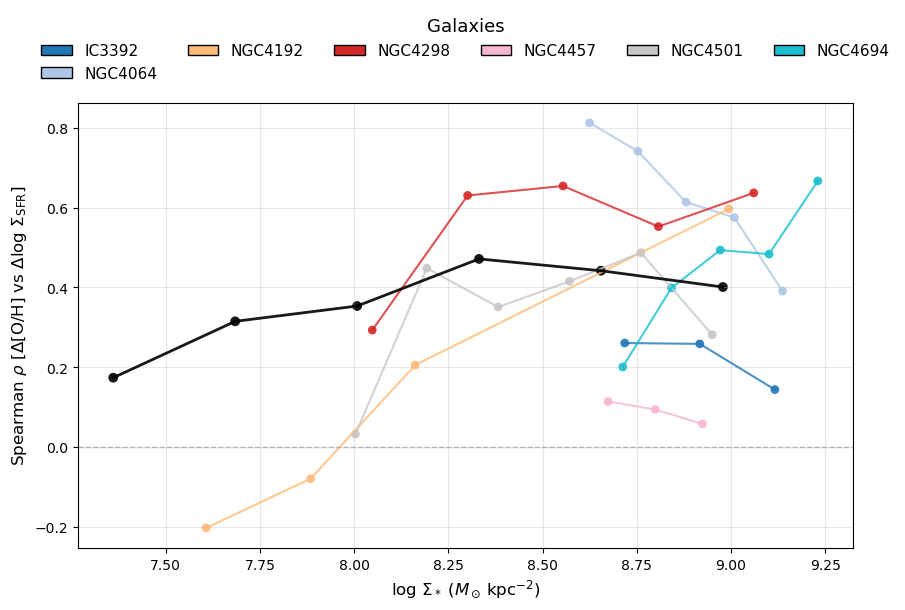

In [ ]:
# ------------------------------------------------------------------
# Offset relations: Δ[O/H] vs Δlog Σ_SFR in Σ_* bins (strict)
# For all galaxies (excluding NGC4383) and Spearman rho vs Σ_* summary
# Spearman rho uses only points inside 95% contour and only if trend exists
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
import matplotlib.gridspec as gridspec
from scipy.stats import spearmanr
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

EW_STRICT_MIN = 6.0  # Strict selection: EW(H$\\alpha$) >= 6

# ------------------------------------------------------------------
# Helper: read the required maps
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'
    ew_path = f'{gal}_v0.7dev_gas_BIN_maps.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists() and Path(ew_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
    with fits.open(ew_path) as h_ew:
        ew_ha = h_ew['HA6562_EW'].data
    return sigM, sigSFR, oh_map, indicator_name, ew_ha

# ------------------------------------------------------------------
# Helper: calculate binned statistics with unique-count requirement
# ------------------------------------------------------------------
def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_unique=20):
    """Calculate median and std in x-bins, requiring >= min_unique unique y values."""
    x_data = np.asarray(x_data)
    y_data = np.asarray(y_data)

    finite = np.isfinite(x_data) & np.isfinite(y_data)
    if np.sum(finite) == 0:
        return np.array([]), np.array([]), np.array([]), np.array([])

    x_min, x_max = np.nanmin(x_data[finite]), np.nanmax(x_data[finite])
    if not np.isfinite(x_min) or not np.isfinite(x_max) or x_min == x_max:
        return np.array([]), np.array([]), np.array([]), np.array([])

    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    if bin_edges.size < 2:
        return np.array([]), np.array([]), np.array([]), np.array([])

    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    medians = []
    stds = []
    counts = []
    valid_centers = []

    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        in_bin = finite & (x_data >= bin_start) & (x_data < bin_end)
        if np.sum(in_bin) == 0:
            continue

        y_in_bin = y_data[in_bin]
        if len(np.unique(y_in_bin)) >= min_unique:
            medians.append(np.nanmedian(y_in_bin))
            stds.append(np.nanstd(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])

    return (np.array(valid_centers), np.array(medians),
            np.array(stds), np.array(counts))

# ------------------------------------------------------------------
# Galaxy list and color map (reserve color for excluded galaxy)
# ------------------------------------------------------------------
all_bin_centers = []  # Σ_* bin centers for which rho is valid (per-galaxy)
all_rho_values = []     # Spearman rho (per-galaxy)
all_galaxy_indices = []

# Also store all spaxels across galaxies to compute a global trend
global_sigM_list = []
global_sigSFR_list = []
global_oh_list = []
global_gal_index_list = []

# Build full galaxy list from available FITS files (including excluded)
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies_all = [f.name.split('_')[0] for f in bins]
excluded_galaxies = {'NGC4383'}

# Build galaxy -> color mapping over ALL galaxies (so excluded keeps its color)
galaxy_colors_all = plt.cm.tab20(np.linspace(0, 1, len(galaxies_all)))
galaxy_color_dict = dict(zip(galaxies_all, galaxy_colors_all))

# Now define the working sample that EXCLUDES NGC4383 for analysis/plotting
galaxies = [g for g in galaxies_all if g not in excluded_galaxies]

print("=" * 80)
print(f"Offset relations and Spearman rho vs Σ_* (excluding: {excluded_galaxies})")
print("All galaxies (for color assignment):", ", ".join(galaxies_all))
print("Galaxies used in this analysis:", ", ".join(galaxies))
print("=" * 80)

# ------------------------------------------------------------------
# Loop over galaxies and compute Spearman rho per Σ_* bin (per-galaxy)
# and collect global spaxels for combined trend
# ------------------------------------------------------------------
for gal_index, gal in enumerate(galaxies):
    print(f"\nProcessing {gal} ...")
    try:
        sigM, sigSFR, oh_o3n2_map, indicator_name, ew_ha = load_maps(gal)
    except Exception as e:
        print(f"  Skipping {gal}: {e}")
        continue

    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_sigM = np.isfinite(sigM)
    valid_ew = np.isfinite(ew_ha) & (ew_ha >= EW_STRICT_MIN)
    valid_all = valid_sfr & valid_oh & valid_sigM & valid_ew
    print(f"  Strict valid pixels (EW(H$\\alpha$)>={EW_STRICT_MIN:.1f}): {np.sum(valid_all)}")

    if np.sum(valid_all) == 0:
        print("  No valid pixels.")
        continue

    # Collect into global arrays for combined analysis
    global_sigM_list.append(sigM[valid_all].ravel())
    global_sigSFR_list.append(sigSFR[valid_all].ravel())
    global_oh_list.append(oh_o3n2_map[valid_all].ravel())
    global_gal_index_list.append(np.full(np.sum(valid_all), gal_index, dtype=int))

    # 1. Define 6 Σ_* bins for this galaxy (spanning 95% population)
    n_bins = 6
    sigmaM_min = np.nanpercentile(sigM[valid_all], 2.5)
    sigmaM_max = np.nanpercentile(sigM[valid_all], 97.5)
    sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
    sigmaM_bin_centers = 0.5 * (sigmaM_bin_edges[:-1] + sigmaM_bin_edges[1:])

    # 2. Global symmetric limits for this galaxy (for reference / consistency)
    global_max_abs_sfr = 0
    global_max_abs_oh = 0
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all

        if np.sum(bin_mask) > 0:
            sfr_bin = sigSFR[bin_mask]
            oh_bin = oh_o3n2_map[bin_mask]

            sfr_offset = sfr_bin - np.mean(sfr_bin)
            oh_offset = oh_bin - np.mean(oh_bin)

            if np.any(np.isfinite(sfr_offset)):
                global_max_abs_sfr = max(global_max_abs_sfr, np.nanmax(np.abs(sfr_offset)))
            if np.any(np.isfinite(oh_offset)):
                global_max_abs_oh = max(global_max_abs_oh, np.nanmax(np.abs(oh_offset)))

    print(f"  Σ* range (95%): {sigmaM_min:.3f} to {sigmaM_max:.3f}")
    print(f"  Global Δlog(Σ_SFR) axis limits: ±{global_max_abs_sfr:.3f}")
    print(f"  Global Δ[O/H] axis limits: ±{global_max_abs_oh:.3f}")

    # 3. Compute Spearman rho in each Σ_* bin using 3-sigma clipping on unique data (per galaxy)
    print("  Spearman rho in each Σ_* bin (3σ clip + trend, per galaxy):")
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all

        n_pixels = np.sum(bin_mask)

        if n_pixels <= 0:
            print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n=0, r=N/A")
            continue

        # Values in this Σ_* bin
        sfr_bin = sigSFR[bin_mask]
        oh_bin = oh_o3n2_map[bin_mask]

        # Offsets within this bin
        sfr_bin_mean = np.mean(sfr_bin)
        oh_bin_mean = np.mean(oh_bin)

        sfr_offset = sfr_bin - sfr_bin_mean
        oh_offset = oh_bin - oh_bin_mean

        valid_corr = np.isfinite(sfr_offset) & np.isfinite(oh_offset)

        if np.sum(valid_corr) <= 2:
            spearman_rho = np.nan
            print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, r=N/A (insufficient valid points)")
            continue

        # ------------------------------------------------------------------
        # Calculate 3-sigma clipping mask on unique valid data
        # ------------------------------------------------------------------
        sigma_clip_mask = np.zeros_like(valid_corr, dtype=bool)
        if np.sum(valid_corr) > 0:
            # Get unique valid data using np.unique
            sfr_data = sfr_offset[valid_corr]
            oh_data = oh_offset[valid_corr]
            
            sfr_unique = np.unique(sfr_data)
            oh_unique = np.unique(oh_data)
            
            # Calculate mean and std on unique values
            x_mean = np.mean(sfr_unique)
            x_std = np.std(sfr_unique)
            y_mean = np.mean(oh_unique)
            y_std = np.std(oh_unique)
            
            # 3-sigma bounds
            x_lower = x_mean - 3 * x_std
            x_upper = x_mean + 3 * x_std
            y_lower = y_mean - 3 * y_std
            y_upper = y_mean + 3 * y_std
            
            # Apply 3-sigma clipping to all data points
            within_3sigma = (sfr_data >= x_lower) & (sfr_data <= x_upper) & \
                            (oh_data >= y_lower) & (oh_data <= y_upper)
            sigma_clip_mask[valid_corr] = within_3sigma

        # ------------------------------------------------------------------
        # Median trend using only points within 3-sigma
        # ------------------------------------------------------------------
        x_trend = sfr_offset[sigma_clip_mask]
        y_trend = oh_offset[sigma_clip_mask]

        centers, medians, stds, counts = calculate_binned_stats(x_trend, y_trend,
                                                                bin_width=0.2,
                                                                min_unique=20)

        # Require at least 2 median-trend points for a valid trend
        has_trend = centers.size >= 2

        # ------------------------------------------------------------------
        # Spearman rho: only for points within 3-sigma and only if trend exists
        # ------------------------------------------------------------------
        if has_trend and np.sum(sigma_clip_mask & valid_corr) > 2:
            try:
                spearman_rho, spearman_p = spearmanr(sfr_offset[sigma_clip_mask & valid_corr],
                                                oh_offset[sigma_clip_mask & valid_corr])
                print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, r={spearman_rho:.3f} (p={spearman_p:.3g})")
            except Exception:
                spearman_rho = np.nan
                print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, r=N/A (error)")
        else:
            spearman_rho = np.nan
            print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, r=N/A (no trend or too few in 3σ)")

        # Store only valid rho values
        if np.isfinite(spearman_rho):
            all_bin_centers.append(sigmaM_bin_centers[i])
            all_rho_values.append(spearman_rho)
            all_galaxy_indices.append(gal_index)

# ------------------------------------------------------------------
# Prepare global arrays for combined Spearman vs Σ_* (all galaxies)
# ------------------------------------------------------------------
if global_sigM_list:
    global_sigM = np.concatenate(global_sigM_list)
    global_sigSFR = np.concatenate(global_sigSFR_list)
    global_oh = np.concatenate(global_oh_list)
else:
    global_sigM = np.array([])
    global_sigSFR = np.array([])
    global_oh = np.array([])

# ------------------------------------------------------------------
# Convert collected per-galaxy Spearman rho data to arrays
# ------------------------------------------------------------------
all_bin_centers = np.array(all_bin_centers)
all_rho_values = np.array(all_rho_values)
all_galaxy_indices = np.array(all_galaxy_indices)

print("\n" + "=" * 80)
print("Summary: number of Σ_* bins with valid Spearman rho (per galaxy):", len(all_rho_values))
print("=" * 80)

# ------------------------------------------------------------------
# Compute combined Spearman rho vs Σ_* over all galaxies (same method)
# ------------------------------------------------------------------
global_bin_centers = []
global_rho_values = []

if global_sigM.size > 0:
    # Define 6 Σ_* bins for the combined sample (spanning 95% population)
    n_bins_global = 6
    sigmaM_min_g = np.nanpercentile(global_sigM, 2.5)
    sigmaM_max_g = np.nanpercentile(global_sigM, 97.5)
    sigmaM_edges_g = np.linspace(sigmaM_min_g, sigmaM_max_g, n_bins_global + 1)
    sigmaM_centers_g = 0.5 * (sigmaM_edges_g[:-1] + sigmaM_edges_g[1:])

    print("\nComputing combined Spearman rho in Σ_* bins (all galaxies together)...")
    for i in range(n_bins_global):
        if i == 0:
            bin_mask_g = (global_sigM >= sigmaM_edges_g[i]) & (global_sigM < sigmaM_edges_g[i+1])
        elif i == n_bins_global - 1:
            bin_mask_g = (global_sigM >= sigmaM_edges_g[i]) & (global_sigM <= sigmaM_edges_g[i+1])
        else:
            bin_mask_g = (global_sigM >= sigmaM_edges_g[i]) & (global_sigM < sigmaM_edges_g[i+1])

        n_pix_g = np.sum(bin_mask_g)
        if n_pix_g <= 0:
            print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n=0, r=N/A")
            continue

        sfr_bin_g = global_sigSFR[bin_mask_g]
        oh_bin_g = global_oh[bin_mask_g]

        sfr_mean_g = np.mean(sfr_bin_g)
        oh_mean_g = np.mean(oh_bin_g)

        sfr_off_g = sfr_bin_g - sfr_mean_g
        oh_off_g = oh_bin_g - oh_mean_g

        valid_corr_g = np.isfinite(sfr_off_g) & np.isfinite(oh_off_g)
        if np.sum(valid_corr_g) <= 2:
            print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, r=N/A (insufficient valid points)")
            continue

        # ------------------------------------------------------------------
        # Calculate 3-sigma clipping mask on unique valid data (global)
        # ------------------------------------------------------------------
        sigma_clip_mask_global = np.zeros_like(valid_corr_g, dtype=bool)
        if np.sum(valid_corr_g) > 0:
            sfr_data_g = sfr_off_g[valid_corr_g]
            oh_data_g = oh_off_g[valid_corr_g]
            
            sfr_unique_g = np.unique(sfr_data_g)
            oh_unique_g = np.unique(oh_data_g)
            
            x_mean_g = np.mean(sfr_unique_g)
            x_std_g = np.std(sfr_unique_g)
            y_mean_g = np.mean(oh_unique_g)
            y_std_g = np.std(oh_unique_g)
            
            x_lower_g = x_mean_g - 3 * x_std_g
            x_upper_g = x_mean_g + 3 * x_std_g
            y_lower_g = y_mean_g - 3 * y_std_g
            y_upper_g = y_mean_g + 3 * y_std_g
            
            within_3sigma_g = (sfr_data_g >= x_lower_g) & (sfr_data_g <= x_upper_g) & \
                              (oh_data_g >= y_lower_g) & (oh_data_g <= y_upper_g)
            sigma_clip_mask_global[valid_corr_g] = within_3sigma_g

        x_trend_g = sfr_off_g[sigma_clip_mask_global]
        y_trend_g = oh_off_g[sigma_clip_mask_global]

        centers_g, medians_g, stds_g, counts_g = calculate_binned_stats(x_trend_g, y_trend_g,
                                                                        bin_width=0.2,
                                                                        min_unique=20)

        has_trend_g = centers_g.size >= 3

        if has_trend_g and np.sum(sigma_clip_mask_global & valid_corr_g) > 2:
            try:
                rho_g, p_g = spearmanr(sfr_off_g[sigma_clip_mask_global & valid_corr_g],
                                     oh_off_g[sigma_clip_mask_global & valid_corr_g])
                global_bin_centers.append(sigmaM_centers_g[i])
                global_rho_values.append(rho_g)
                print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, r={rho_g:.3f} (p={p_g:.3g})")
            except Exception:
                print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, r=N/A (error)")
        else:
            print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, r=N/A (no trend or too few in 3σ)")

global_bin_centers = np.array(global_bin_centers)
global_rho_values = np.array(global_rho_values)

# ------------------------------------------------------------------
# Plot Spearman rho vs Σ_* for all galaxies, with galaxy color legend
# and an additional combined (all galaxies) trend in black
# ------------------------------------------------------------------
if len(all_rho_values) > 0:
    
    galaxy_indices_unique = np.unique(all_galaxy_indices)
    
    # Create figure with main axis and a thin top axis for legend
    fig = plt.figure(figsize=(10, 7))
    gs = gridspec.GridSpec(2, 1, height_ratios=[0.18, 1.0], hspace=0.05)
    legend_ax = fig.add_subplot(gs[0, 0])
    ax = fig.add_subplot(gs[1, 0])
    legend_ax.axis('off')
    
    plotted_galaxies = [] # Keep track of which galaxies are actually plotted
    
    # Plot Spearman rho vs Σ_* for each galaxy
    for idx in galaxy_indices_unique:
        mask = all_galaxy_indices == idx
        gal_name = galaxies[idx]
        color = galaxy_color_dict[gal_name]
        
        # Sort by Σ_* so lines are not scrambled
        x_vals = all_bin_centers[mask]
        y_vals = all_rho_values[mask]
        
        # Filter: skip if only 1 data point
        if len(x_vals) <= 1:
            continue
            
        plotted_galaxies.append(gal_name)
        
        order = np.argsort(x_vals)
        x_sorted = x_vals[order]
        y_sorted = y_vals[order]
        
        ax.plot(x_sorted, y_sorted, color=color, linewidth=1.5, alpha=0.8)
        ax.scatter(x_sorted, y_sorted, color=color, s=40, alpha=0.9, edgecolors='none', rasterized=True)
    
    # Add combined trend (all galaxies together) in black (no legend entry)
    if global_rho_values.size > 0:
        order_g = np.argsort(global_bin_centers)
        ax.plot(global_bin_centers[order_g], global_rho_values[order_g],
                color='black', linewidth=2.0, alpha=0.9, linestyle='-')
        ax.scatter(global_bin_centers[order_g], global_rho_values[order_g],
                   color='black', s=50, alpha=0.9, edgecolors='none', rasterized=True)
    
    # Axis formatting
    ax.axhline(0.0, color='gray', linestyle='--', linewidth=1.0, alpha=0.5)
    ax.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
    ax.set_ylabel(r'Spearman $\rho$ [Δ[O/H] vs Δ$\log\,\Sigma_{\mathrm{SFR}}$]', fontsize=12)
    # ax.set_title(r'Spearman $\rho$ vs $\log\,\Sigma_*$ (all galaxies, excluding NGC4383)', fontsize=14)
    ax.grid(True, alpha=0.3)
    
    # ------------------------------------------------------------------
    # Galaxy legend at the top using dummy patches (excluding NGC4383)
    # ------------------------------------------------------------------
    legend_elements = [
        Patch(facecolor=galaxy_color_dict[gal], edgecolor='black', label=gal)
        for gal in plotted_galaxies
    ]
    if len(plotted_galaxies) > 0:
        legend_ax.legend(handles=legend_elements, loc='center', ncol=min(len(plotted_galaxies), 6),
                        frameon=False, fontsize=11, title='Galaxies', title_fontsize=13)
    
    plt.tight_layout()
    # plt.savefig('Plot_Paper_1/MAUVE_MUSE_SpearmanRho_vs_SigmaM_AllGalaxies_ExclNGC4383.png',
    #             dpi=600, bbox_inches='tight')
    # plt.savefig('Plot_Paper_1/MAUVE_MUSE_SpearmanRho_vs_SigmaM_AllGalaxies_ExclNGC4383.pdf',
    #             bbox_inches='tight')
    plt.show()
else:
    print("No valid Spearman rho values to plot.")

Offset relations and Spearman rho vs Σ_* (excluding: {'NGC4383'})
All galaxies (for color assignment): IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4383, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Galaxies used in this analysis: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698

Processing IC3392 ...
  Strict valid pixels (EW(H$\alpha$)>=6.0): 986
  Σ* range (95%): 8.021 to 9.216
  Global Δlog(Σ_SFR) axis limits: ±0.624
  Global Δ[O/H] axis limits: ±0.105
  Spearman rho in each Σ_* bin (3σ clip + trend, per galaxy):
    Bin 01 (8.12): n=113, r=N/A (no trend or too few in 3σ)
    Bin 02 (8.32): n=240, r=N/A (no trend or too few in 3σ)
    Bin 03 (8.52): n=125, r=N/A (no trend or too few in 3σ)
    Bin 04 (8.72): n=179, r=0.261 (p=0.000454)
    Bin 05 (8.92): n=188, r=0.259 (p=0.000363)
    Bin 06 (9.12): n=93, r=0.144 (p=0.168)
  Included in ensemble trend (3 valid rho bins).

Processing NGC40

/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_46452/181709777.py:477: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


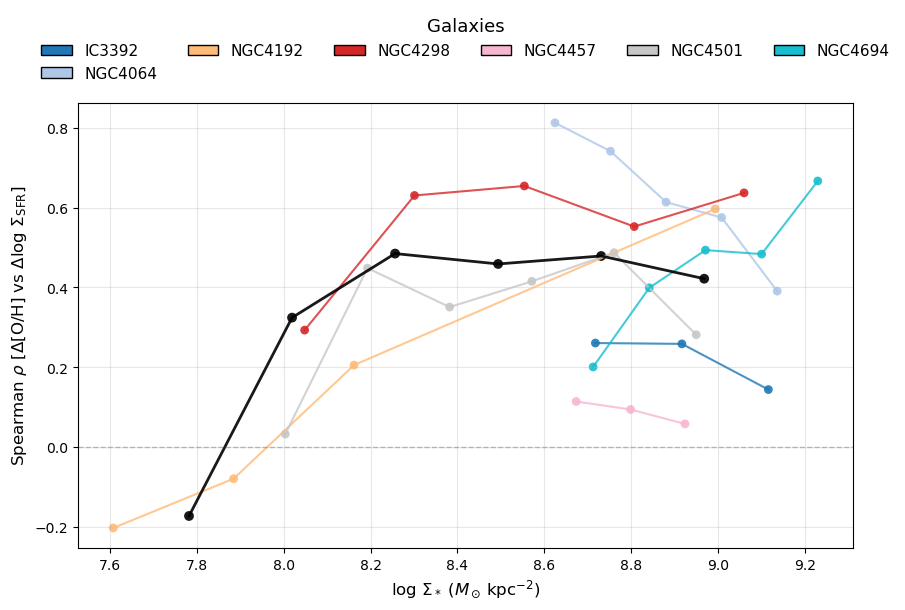

In [ ]:
# ------------------------------------------------------------------
# Offset relations: Δ[O/H] vs Δlog Σ_SFR in Σ_* bins (strict)
# For all galaxies (excluding NGC4383) and Spearman rho vs Σ_* summary
# Spearman rho uses only points inside 95% contour and only if trend exists
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
import matplotlib.gridspec as gridspec
from scipy.stats import spearmanr
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

EW_STRICT_MIN = 6.0  # Strict selection: EW(H$\\alpha$) >= 6

# ------------------------------------------------------------------
# Helper: read the required maps
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'
    ew_path = f'{gal}_v0.7dev_gas_BIN_maps.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists() and Path(ew_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
    with fits.open(ew_path) as h_ew:
        ew_ha = h_ew['HA6562_EW'].data
    return sigM, sigSFR, oh_map, indicator_name, ew_ha

# ------------------------------------------------------------------
# Helper: calculate binned statistics with unique-count requirement
# ------------------------------------------------------------------
def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_unique=20):
    """Calculate median and std in x-bins, requiring >= min_unique unique y values."""
    x_data = np.asarray(x_data)
    y_data = np.asarray(y_data)

    finite = np.isfinite(x_data) & np.isfinite(y_data)
    if np.sum(finite) == 0:
        return np.array([]), np.array([]), np.array([]), np.array([])

    x_min, x_max = np.nanmin(x_data[finite]), np.nanmax(x_data[finite])
    if not np.isfinite(x_min) or not np.isfinite(x_max) or x_min == x_max:
        return np.array([]), np.array([]), np.array([]), np.array([])

    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    if bin_edges.size < 2:
        return np.array([]), np.array([]), np.array([]), np.array([])

    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    medians = []
    stds = []
    counts = []
    valid_centers = []

    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        in_bin = finite & (x_data >= bin_start) & (x_data < bin_end)
        if np.sum(in_bin) == 0:
            continue

        y_in_bin = y_data[in_bin]
        if len(np.unique(y_in_bin)) >= min_unique:
            medians.append(np.nanmedian(y_in_bin))
            stds.append(np.nanstd(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])

    return (np.array(valid_centers), np.array(medians),
            np.array(stds), np.array(counts))

# ------------------------------------------------------------------
# Galaxy list and color map (reserve color for excluded galaxy)
# ------------------------------------------------------------------
all_bin_centers = []  # Σ_* bin centers for which rho is valid (per-galaxy)
all_rho_values = []     # Spearman rho (per-galaxy)
all_galaxy_indices = []

# Also store all spaxels across galaxies to compute a global trend
global_sigM_list = []
global_sigSFR_list = []
global_oh_list = []
global_gal_index_list = []

# Build full galaxy list from available FITS files (including excluded)
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies_all = [f.name.split('_')[0] for f in bins]
excluded_galaxies = {'NGC4383'}

# Build galaxy -> color mapping over ALL galaxies (so excluded keeps its color)
galaxy_colors_all = plt.cm.tab20(np.linspace(0, 1, len(galaxies_all)))
galaxy_color_dict = dict(zip(galaxies_all, galaxy_colors_all))

# Now define the working sample that EXCLUDES NGC4383 for analysis/plotting
galaxies = [g for g in galaxies_all if g not in excluded_galaxies]

print("=" * 80)
print(f"Offset relations and Spearman rho vs Σ_* (excluding: {excluded_galaxies})")
print("All galaxies (for color assignment):", ", ".join(galaxies_all))
print("Galaxies used in this analysis:", ", ".join(galaxies))
print("=" * 80)

# ------------------------------------------------------------------
# Loop over galaxies and compute Spearman rho per Σ_* bin (per-galaxy)
# and collect global spaxels for combined trend
# ------------------------------------------------------------------
for gal_index, gal in enumerate(galaxies):
    print(f"\nProcessing {gal} ...")
    try:
        sigM, sigSFR, oh_o3n2_map, indicator_name, ew_ha = load_maps(gal)
    except Exception as e:
        print(f"  Skipping {gal}: {e}")
        continue

    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_sigM = np.isfinite(sigM)
    valid_ew = np.isfinite(ew_ha) & (ew_ha >= EW_STRICT_MIN)
    valid_all = valid_sfr & valid_oh & valid_sigM & valid_ew
    print(f"  Strict valid pixels (EW(H$\\alpha$)>={EW_STRICT_MIN:.1f}): {np.sum(valid_all)}")

    if np.sum(valid_all) == 0:
        print("  No valid pixels.")
        continue

    # Keep global pixels only for galaxies that are actually plotted (>=2 rho points).

    # 1. Define 6 Σ_* bins for this galaxy (spanning 95% population)
    n_bins = 6
    sigmaM_min = np.nanpercentile(sigM[valid_all], 2.5)
    sigmaM_max = np.nanpercentile(sigM[valid_all], 97.5)
    sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
    sigmaM_bin_centers = 0.5 * (sigmaM_bin_edges[:-1] + sigmaM_bin_edges[1:])
    
    valid_points_for_global = np.zeros_like(sigM, dtype=bool)

    # 2. Global symmetric limits for this galaxy (for reference / consistency)
    global_max_abs_sfr = 0
    global_max_abs_oh = 0
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all

        if np.sum(bin_mask) > 0:
            sfr_bin = sigSFR[bin_mask]
            oh_bin = oh_o3n2_map[bin_mask]

            sfr_offset = sfr_bin - np.mean(sfr_bin)
            oh_offset = oh_bin - np.mean(oh_bin)

            if np.any(np.isfinite(sfr_offset)):
                global_max_abs_sfr = max(global_max_abs_sfr, np.nanmax(np.abs(sfr_offset)))
            if np.any(np.isfinite(oh_offset)):
                global_max_abs_oh = max(global_max_abs_oh, np.nanmax(np.abs(oh_offset)))

    print(f"  Σ* range (95%): {sigmaM_min:.3f} to {sigmaM_max:.3f}")
    print(f"  Global Δlog(Σ_SFR) axis limits: ±{global_max_abs_sfr:.3f}")
    print(f"  Global Δ[O/H] axis limits: ±{global_max_abs_oh:.3f}")

    # 3. Compute Spearman rho in each Σ_* bin using 3-sigma clipping on unique data (per galaxy)
    print("  Spearman rho in each Σ_* bin (3σ clip + trend, per galaxy):")
    gal_bin_centers = []
    gal_rho_values = []
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all

        n_pixels = np.sum(bin_mask)

        if n_pixels <= 0:
            print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n=0, r=N/A")
            continue

        # Values in this Σ_* bin
        sfr_bin = sigSFR[bin_mask]
        oh_bin = oh_o3n2_map[bin_mask]

        # Offsets within this bin
        sfr_bin_mean = np.mean(sfr_bin)
        oh_bin_mean = np.mean(oh_bin)

        sfr_offset = sfr_bin - sfr_bin_mean
        oh_offset = oh_bin - oh_bin_mean

        valid_corr = np.isfinite(sfr_offset) & np.isfinite(oh_offset)

        if np.sum(valid_corr) <= 2:
            spearman_rho = np.nan
            print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, r=N/A (insufficient valid points)")
            continue

        # ------------------------------------------------------------------
        # Calculate 3-sigma clipping mask on unique valid data
        # ------------------------------------------------------------------
        sigma_clip_mask = np.zeros_like(valid_corr, dtype=bool)
        if np.sum(valid_corr) > 0:
            # Get unique valid data using np.unique
            sfr_data = sfr_offset[valid_corr]
            oh_data = oh_offset[valid_corr]
            
            sfr_unique = np.unique(sfr_data)
            oh_unique = np.unique(oh_data)
            
            # Calculate mean and std on unique values
            x_mean = np.mean(sfr_unique)
            x_std = np.std(sfr_unique)
            y_mean = np.mean(oh_unique)
            y_std = np.std(oh_unique)
            
            # 3-sigma bounds
            x_lower = x_mean - 3 * x_std
            x_upper = x_mean + 3 * x_std
            y_lower = y_mean - 3 * y_std
            y_upper = y_mean + 3 * y_std
            
            # Apply 3-sigma clipping to all data points
            within_3sigma = (sfr_data >= x_lower) & (sfr_data <= x_upper) & \
                            (oh_data >= y_lower) & (oh_data <= y_upper)
            sigma_clip_mask[valid_corr] = within_3sigma

        # ------------------------------------------------------------------
        # Median trend using only points within 3-sigma
        # ------------------------------------------------------------------
        x_trend = sfr_offset[sigma_clip_mask]
        y_trend = oh_offset[sigma_clip_mask]

        centers, medians, stds, counts = calculate_binned_stats(x_trend, y_trend,
                                                                bin_width=0.2,
                                                                min_unique=20)

        # Require at least 2 median-trend points for a valid trend
        has_trend = centers.size >= 2

        # ------------------------------------------------------------------
        # Spearman rho: only for points within 3-sigma and only if trend exists
        # ------------------------------------------------------------------
        if has_trend and np.sum(sigma_clip_mask & valid_corr) > 2:
            try:
                spearman_rho, spearman_p = spearmanr(sfr_offset[sigma_clip_mask & valid_corr],
                                                oh_offset[sigma_clip_mask & valid_corr])
                print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, r={spearman_rho:.3f} (p={spearman_p:.3g})")
            except Exception:
                spearman_rho = np.nan
                print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, r=N/A (error)")
        else:
            spearman_rho = np.nan
            print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, r=N/A (no trend or too few in 3σ)")

        # Store per-galaxy rho values first; include this galaxy only if it can be plotted.
        if np.isfinite(spearman_rho):
            gal_bin_centers.append(sigmaM_bin_centers[i])
            gal_rho_values.append(spearman_rho)
            
            # Record points contributing to this bin's Spearman trend
            temp_mask = np.zeros(len(sfr_bin), dtype=bool)
            temp_mask[sigma_clip_mask & valid_corr] = True
            valid_points_for_global[bin_mask] = temp_mask

    if len(gal_bin_centers) > 1:
        all_bin_centers.extend(gal_bin_centers)
        all_rho_values.extend(gal_rho_values)
        all_galaxy_indices.extend([gal_index] * len(gal_bin_centers))

        global_sigM_list.append(sigM[valid_points_for_global].ravel())
        global_sigSFR_list.append(sigSFR[valid_points_for_global].ravel())
        global_oh_list.append(oh_o3n2_map[valid_points_for_global].ravel())
        global_gal_index_list.append(np.full(np.sum(valid_points_for_global), gal_index, dtype=int))
        print(f"  Included in ensemble trend ({len(gal_bin_centers)} valid rho bins).")
    else:
        print("  Excluded from ensemble trend (fewer than 2 valid rho bins).")

# ------------------------------------------------------------------
# Prepare global arrays for combined Spearman vs Σ_* (all galaxies)
# ------------------------------------------------------------------
if global_sigM_list:
    global_sigM = np.concatenate(global_sigM_list)
    global_sigSFR = np.concatenate(global_sigSFR_list)
    global_oh = np.concatenate(global_oh_list)
else:
    global_sigM = np.array([])
    global_sigSFR = np.array([])
    global_oh = np.array([])

# ------------------------------------------------------------------
# Convert collected per-galaxy Spearman rho data to arrays
# ------------------------------------------------------------------
all_bin_centers = np.array(all_bin_centers)
all_rho_values = np.array(all_rho_values)
all_galaxy_indices = np.array(all_galaxy_indices)

print("\n" + "=" * 80)
print("Summary: number of Σ_* bins with valid Spearman rho (per galaxy):", len(all_rho_values))
print("=" * 80)

# ------------------------------------------------------------------
# Compute combined Spearman rho vs Σ_* over all galaxies (same method)
# ------------------------------------------------------------------
global_bin_centers = []
global_rho_values = []

if global_sigM.size > 0:
    # Define 6 Σ_* bins for the combined sample (spanning 95% population)
    n_bins_global = 6
    sigmaM_min_g = np.nanpercentile(global_sigM, 2.5)
    sigmaM_max_g = np.nanpercentile(global_sigM, 97.5)
    sigmaM_edges_g = np.linspace(sigmaM_min_g, sigmaM_max_g, n_bins_global + 1)
    sigmaM_centers_g = 0.5 * (sigmaM_edges_g[:-1] + sigmaM_edges_g[1:])

    print("\nComputing combined Spearman rho in Σ_* bins (all galaxies together)...")
    for i in range(n_bins_global):
        if i == 0:
            bin_mask_g = (global_sigM >= sigmaM_edges_g[i]) & (global_sigM < sigmaM_edges_g[i+1])
        elif i == n_bins_global - 1:
            bin_mask_g = (global_sigM >= sigmaM_edges_g[i]) & (global_sigM <= sigmaM_edges_g[i+1])
        else:
            bin_mask_g = (global_sigM >= sigmaM_edges_g[i]) & (global_sigM < sigmaM_edges_g[i+1])

        n_pix_g = np.sum(bin_mask_g)
        if n_pix_g <= 0:
            print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n=0, r=N/A")
            continue

        sfr_bin_g = global_sigSFR[bin_mask_g]
        oh_bin_g = global_oh[bin_mask_g]

        sfr_mean_g = np.mean(sfr_bin_g)
        oh_mean_g = np.mean(oh_bin_g)

        sfr_off_g = sfr_bin_g - sfr_mean_g
        oh_off_g = oh_bin_g - oh_mean_g

        valid_corr_g = np.isfinite(sfr_off_g) & np.isfinite(oh_off_g)
        if np.sum(valid_corr_g) <= 2:
            print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, r=N/A (insufficient valid points)")
            continue

        # ------------------------------------------------------------------
        # Calculate 3-sigma clipping mask on unique valid data (global)
        # ------------------------------------------------------------------
        sigma_clip_mask_global = np.zeros_like(valid_corr_g, dtype=bool)
        if np.sum(valid_corr_g) > 0:
            sfr_data_g = sfr_off_g[valid_corr_g]
            oh_data_g = oh_off_g[valid_corr_g]
            
            sfr_unique_g = np.unique(sfr_data_g)
            oh_unique_g = np.unique(oh_data_g)
            
            x_mean_g = np.mean(sfr_unique_g)
            x_std_g = np.std(sfr_unique_g)
            y_mean_g = np.mean(oh_unique_g)
            y_std_g = np.std(oh_unique_g)
            
            x_lower_g = x_mean_g - 3 * x_std_g
            x_upper_g = x_mean_g + 3 * x_std_g
            y_lower_g = y_mean_g - 3 * y_std_g
            y_upper_g = y_mean_g + 3 * y_std_g
            
            within_3sigma_g = (sfr_data_g >= x_lower_g) & (sfr_data_g <= x_upper_g) & \
                              (oh_data_g >= y_lower_g) & (oh_data_g <= y_upper_g)
            sigma_clip_mask_global[valid_corr_g] = within_3sigma_g

        x_trend_g = sfr_off_g[sigma_clip_mask_global]
        y_trend_g = oh_off_g[sigma_clip_mask_global]

        centers_g, medians_g, stds_g, counts_g = calculate_binned_stats(x_trend_g, y_trend_g,
                                                                        bin_width=0.2,
                                                                        min_unique=20)

        has_trend_g = centers_g.size >= 3

        if has_trend_g and np.sum(sigma_clip_mask_global & valid_corr_g) > 2:
            try:
                rho_g, p_g = spearmanr(sfr_off_g[sigma_clip_mask_global & valid_corr_g],
                                     oh_off_g[sigma_clip_mask_global & valid_corr_g])
                global_bin_centers.append(sigmaM_centers_g[i])
                global_rho_values.append(rho_g)
                print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, r={rho_g:.3f} (p={p_g:.3g})")
            except Exception:
                print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, r=N/A (error)")
        else:
            print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, r=N/A (no trend or too few in 3σ)")

global_bin_centers = np.array(global_bin_centers)
global_rho_values = np.array(global_rho_values)

# ------------------------------------------------------------------
# Plot Spearman rho vs Σ_* for all galaxies, with galaxy color legend
# and an additional combined (all galaxies) trend in black
# ------------------------------------------------------------------
if len(all_rho_values) > 0:
    
    galaxy_indices_unique = np.unique(all_galaxy_indices)
    
    # Create figure with main axis and a thin top axis for legend
    fig = plt.figure(figsize=(10, 7))
    gs = gridspec.GridSpec(2, 1, height_ratios=[0.18, 1.0], hspace=0.05)
    legend_ax = fig.add_subplot(gs[0, 0])
    ax = fig.add_subplot(gs[1, 0])
    legend_ax.axis('off')
    
    plotted_galaxies = [] # Keep track of which galaxies are actually plotted
    
    # Plot Spearman rho vs Σ_* for each galaxy
    for idx in galaxy_indices_unique:
        mask = all_galaxy_indices == idx
        gal_name = galaxies[idx]
        color = galaxy_color_dict[gal_name]
        
        # Sort by Σ_* so lines are not scrambled
        x_vals = all_bin_centers[mask]
        y_vals = all_rho_values[mask]
        
        # Filter: skip if only 1 data point
        if len(x_vals) <= 1:
            continue
            
        plotted_galaxies.append(gal_name)
        
        order = np.argsort(x_vals)
        x_sorted = x_vals[order]
        y_sorted = y_vals[order]
        
        ax.plot(x_sorted, y_sorted, color=color, linewidth=1.5, alpha=0.8)
        ax.scatter(x_sorted, y_sorted, color=color, s=40, alpha=0.9, edgecolors='none', rasterized=True)
    
    # Add combined trend (all galaxies together) in black (no legend entry)
    if global_rho_values.size > 0:
        order_g = np.argsort(global_bin_centers)
        ax.plot(global_bin_centers[order_g], global_rho_values[order_g],
                color='black', linewidth=2.0, alpha=0.9, linestyle='-')
        ax.scatter(global_bin_centers[order_g], global_rho_values[order_g],
                   color='black', s=50, alpha=0.9, edgecolors='none', rasterized=True)
    
    # Axis formatting
    ax.axhline(0.0, color='gray', linestyle='--', linewidth=1.0, alpha=0.5)
    ax.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
    ax.set_ylabel(r'Spearman $\rho$ [Δ[O/H] vs Δ$\log\,\Sigma_{\mathrm{SFR}}$]', fontsize=12)
    # ax.set_title(r'Spearman $\rho$ vs $\log\,\Sigma_*$ (all galaxies, excluding NGC4383)', fontsize=14)
    ax.grid(True, alpha=0.3)
    
    # ------------------------------------------------------------------
    # Galaxy legend at the top using dummy patches (excluding NGC4383)
    # ------------------------------------------------------------------
    legend_elements = [
        Patch(facecolor=galaxy_color_dict[gal], edgecolor='black', label=gal)
        for gal in plotted_galaxies
    ]
    if len(plotted_galaxies) > 0:
        legend_ax.legend(handles=legend_elements, loc='center', ncol=min(len(plotted_galaxies), 6),
                        frameon=False, fontsize=11, title='Galaxies', title_fontsize=13)
    
    plt.tight_layout()
    # plt.savefig('Plot_Paper_1/MAUVE_MUSE_SpearmanRho_vs_SigmaM_AllGalaxies_ExclNGC4383.png',
    #             dpi=600, bbox_inches='tight')
    # plt.savefig('Plot_Paper_1/MAUVE_MUSE_SpearmanRho_vs_SigmaM_AllGalaxies_ExclNGC4383.pdf',
    #             bbox_inches='tight')
    plt.show()
else:
    print("No valid Spearman rho values to plot.")

Processing 13 galaxies (excluding NGC4383 for stats): IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Applying strict EW selection to both HII and SF: EW(H$\alpha$)>=6.0
Skipping NGC4698: [Errno 2] No such file or directory: 'NGC4698_v0.7dev_gas_BIN_maps.fits'
Computing global Spearman trends...


/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_46452/1950880186.py:625: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.85])


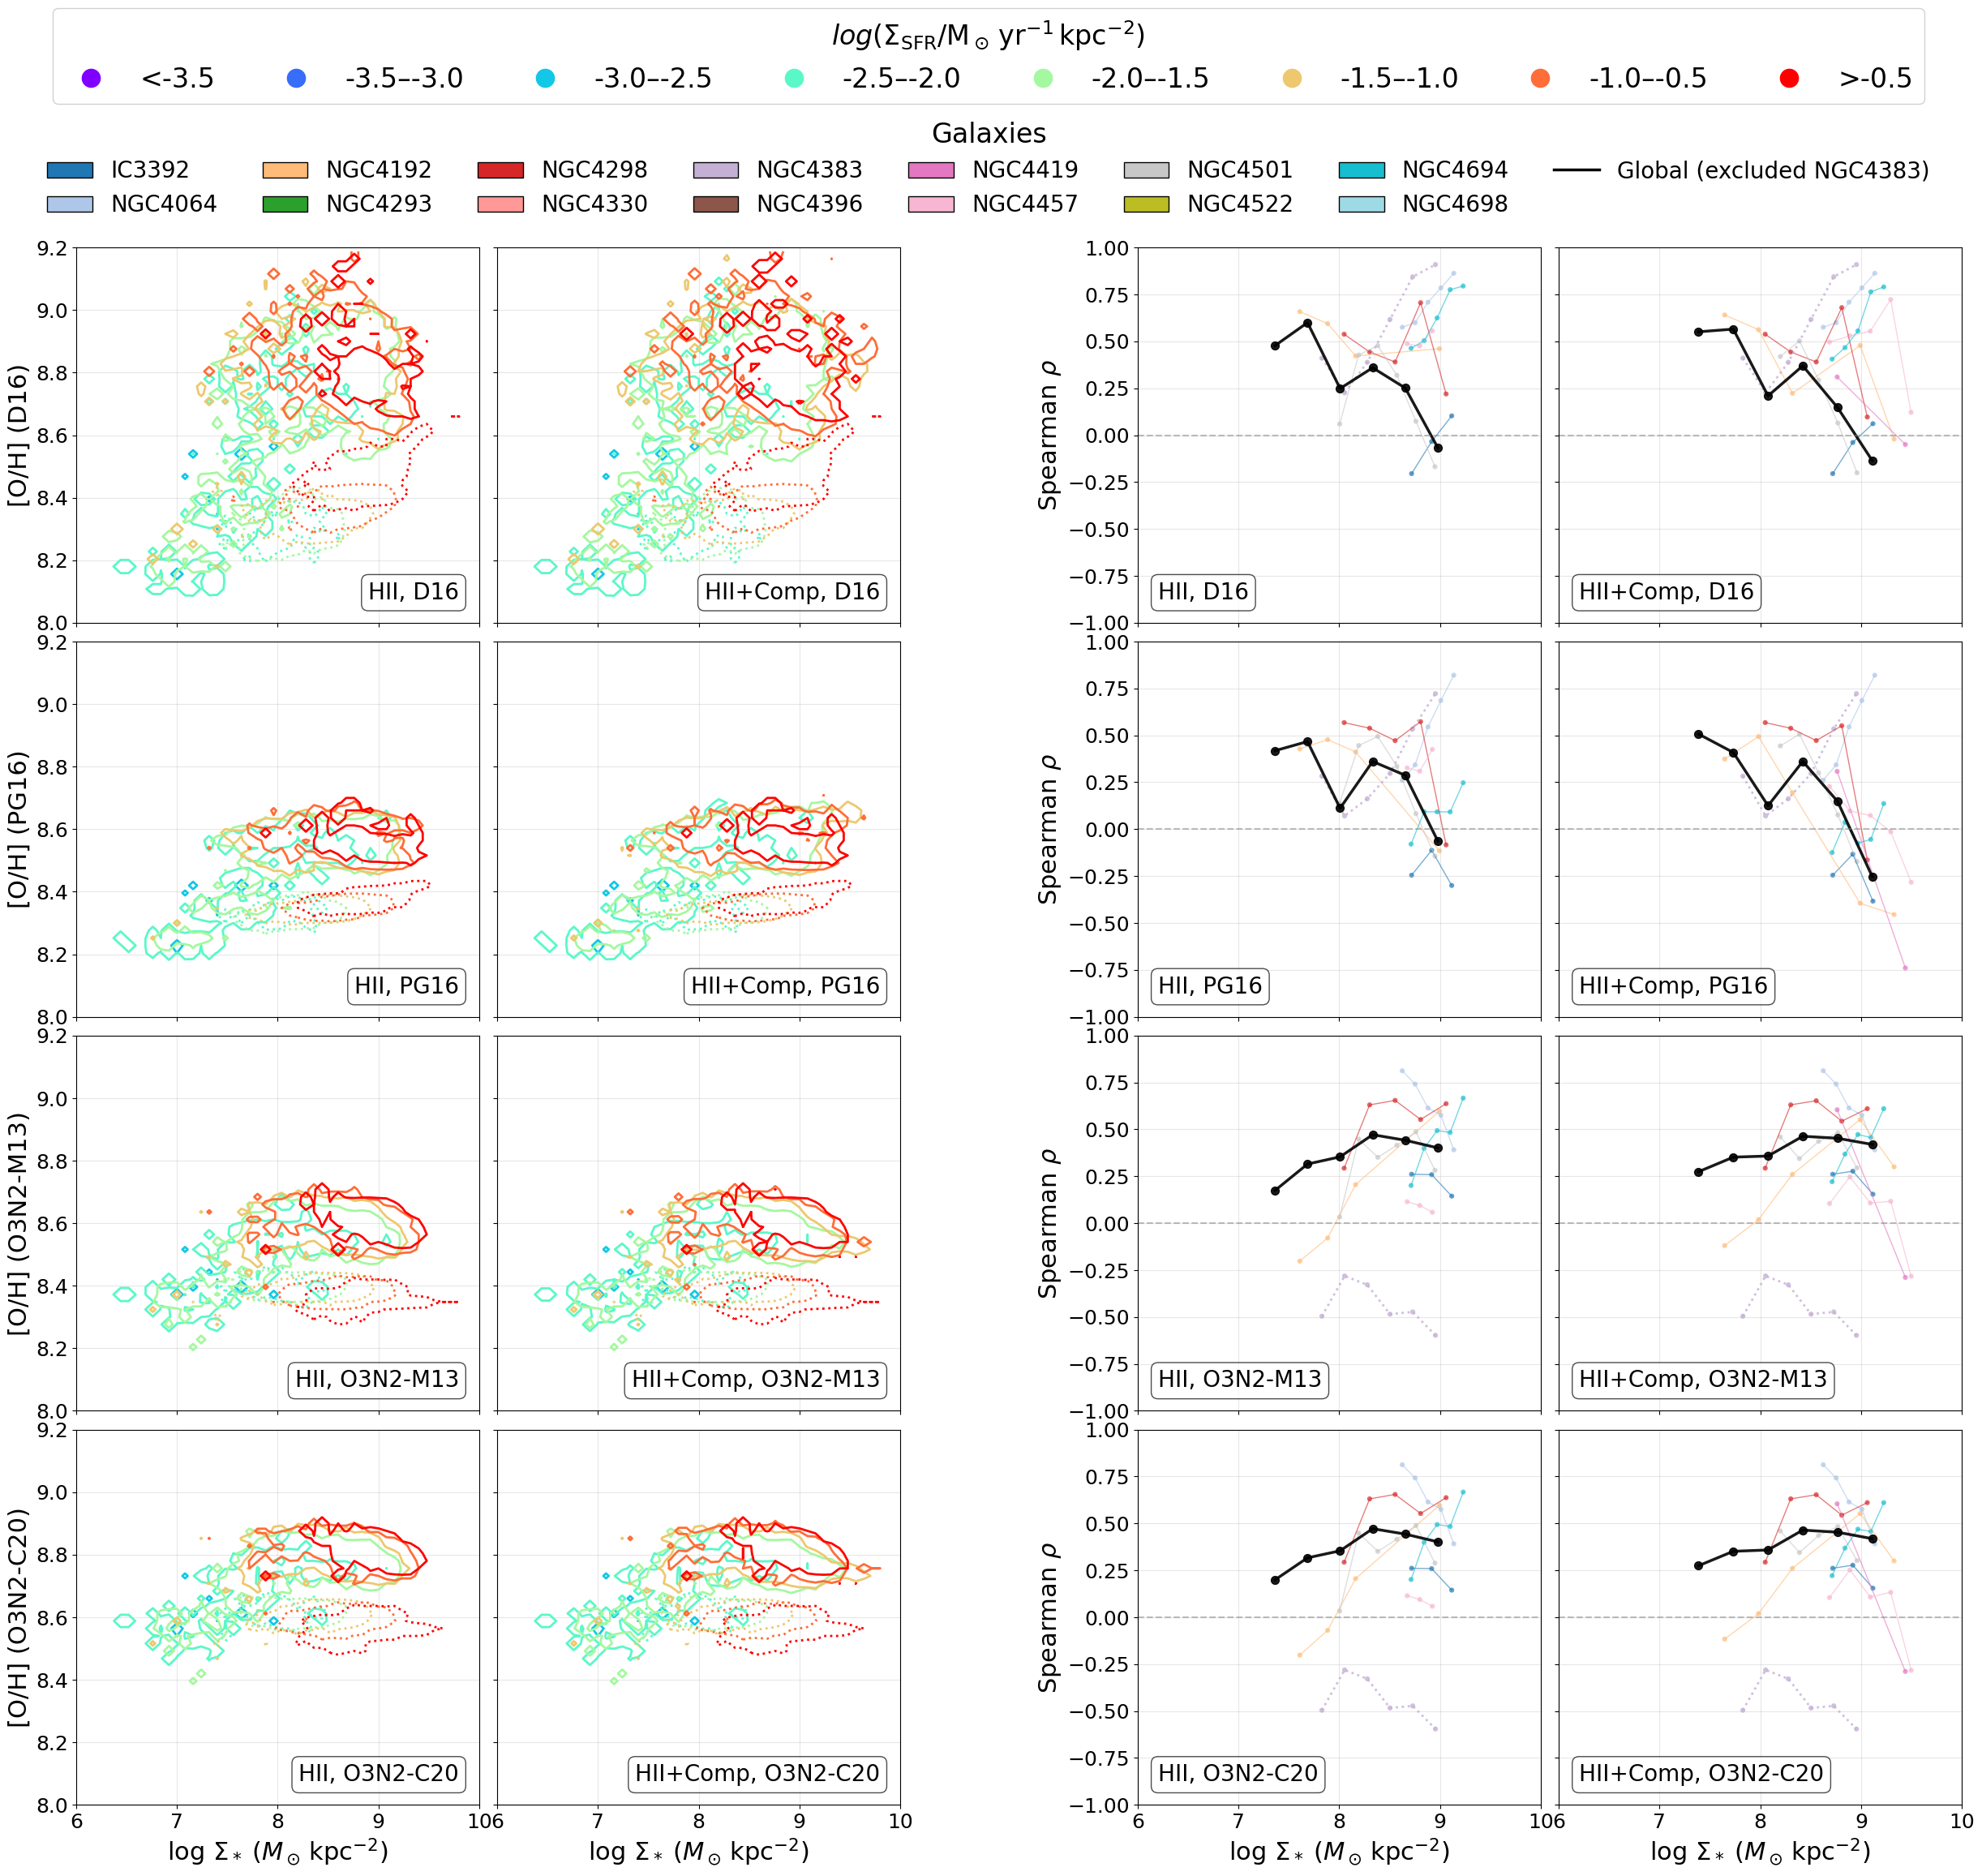

In [ ]:
# ------------------------------------------------------------------
# COMBINED FIGURE: rMZR Scatter (Cols 1-2) and Spearman rho (Cols 3-4)
# WITH NGC4383 (Dotted Contours/Lines)
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
import scipy.stats as stats
from scipy.stats import spearmanr
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import matplotlib.lines as mlines

EW_STRICT_MIN = 6.0  # Strict selection: EW(H$\\alpha$) >= 6

# ==========================================
# PART 1: FUNCTIONS & SETUP
# ==========================================

def load_maps_mzr(gal):
    """Load all metallicity calibrations + EW(H$\\alpha$) map for both HII and SF regions (MZR version)"""
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        # HII regions
        sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_d16_HII = h['O_H_D16_HII'].data
        oh_pg16_HII = h['O_H_PG16_HII'].data
        oh_o3n2_m13_HII = h['O_H_O3N2_M13_HII'].data
        oh_o3n2_c20_HII = h['O_H_O3N2_C20_HII'].data
        # SF regions
        sigSFR_SF = h['LOGSFR_SURFACE_DENSITY_SF'].data
        oh_d16_SF = h['O_H_D16_SF'].data
        oh_pg16_SF = h['O_H_PG16_SF'].data
        oh_o3n2_m13_SF = h['O_H_O3N2_M13_SF'].data
        oh_o3n2_c20_SF = h['O_H_O3N2_C20_SF'].data
        # Emission lines
        HB4861_FLUX_corr = h['HB4861_FLUX_corr'].data
        HA6562_FLUX_corr = h['HA6562_FLUX_corr'].data
        OIII5006_FLUX_corr = h['OIII5006_FLUX_corr'].data
        NII6583_FLUX_corr = h['NII6583_FLUX_corr'].data
        SII6716_FLUX_corr = h['SII6716_FLUX_corr'].data
        SII6730_FLUX_corr = h['SII6730_FLUX_corr'].data
    with fits.open(f'{gal}_v0.7dev_gas_BIN_maps.fits') as h_ew:
        ew_ha = h_ew['HA6562_EW'].data
    return (sigM, sigSFR_HII, oh_d16_HII, oh_pg16_HII, oh_o3n2_m13_HII, oh_o3n2_c20_HII,
            sigSFR_SF, oh_d16_SF, oh_pg16_SF, oh_o3n2_m13_SF, oh_o3n2_c20_SF,
            HB4861_FLUX_corr, HA6562_FLUX_corr, OIII5006_FLUX_corr, 
            NII6583_FLUX_corr, SII6716_FLUX_corr, SII6730_FLUX_corr, ew_ha)

def calculate_binned_stats_spearman(x_data, y_data, bin_width=0.2, min_unique=20):
    """Calculate median and std in x-bins (Spearman version)"""
    x_data = np.asarray(x_data)
    y_data = np.asarray(y_data)
    
    finite = np.isfinite(x_data) & np.isfinite(y_data)
    if np.sum(finite) == 0:
        return np.array([]), np.array([]), np.array([]), np.array([])
        
    x_min, x_max = np.nanmin(x_data[finite]), np.nanmax(x_data[finite])
    if not np.isfinite(x_min) or not np.isfinite(x_max) or x_min == x_max:
        return np.array([]), np.array([]), np.array([]), np.array([])
        
    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    if bin_edges.size < 2:
        return np.array([]), np.array([]), np.array([]), np.array([])
        
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    medians = []
    stds = []
    counts = []
    valid_centers = []
    
    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        in_bin = finite & (x_data >= bin_start) & (x_data < bin_end)
        if np.sum(in_bin) == 0:
            continue
            
        y_in_bin = y_data[in_bin]
        if len(np.unique(y_in_bin)) >= min_unique:
            medians.append(np.nanmedian(y_in_bin))
            stds.append(np.nanstd(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])
            
    return (np.array(valid_centers), np.array(medians), 
            np.array(stds), np.array(counts))

def compute_spearman_track(sigM, sigSFR, oh_map, n_bins=6, extra_mask=None):
    valid_all = np.isfinite(sigM) & np.isfinite(sigSFR) & np.isfinite(oh_map)
    if extra_mask is not None:
        valid_all = valid_all & extra_mask
    if np.sum(valid_all) == 0:
        return np.array([]), np.array([])

    sigM = sigM[valid_all]
    sigSFR = sigSFR[valid_all]
    oh_map = oh_map[valid_all]

    sigmaM_min = np.nanpercentile(sigM, 2.5)
    sigmaM_max = np.nanpercentile(sigM, 97.5)
    sigmaM_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
    sigmaM_centers = 0.5 * (sigmaM_edges[:-1] + sigmaM_edges[1:])
    
    valid_centers = []
    rho_values = []
    
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_edges[i]) & (sigM < sigmaM_edges[i+1])
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_edges[i]) & (sigM <= sigmaM_edges[i+1])
        else:
            bin_mask = (sigM >= sigmaM_edges[i]) & (sigM < sigmaM_edges[i+1])
            
        if np.sum(bin_mask) <= 20: 
            continue
            
        sfr_bin = sigSFR[bin_mask]
        oh_bin = oh_map[bin_mask]
        
        sfr_off = sfr_bin - np.mean(sfr_bin)
        oh_off = oh_bin - np.mean(oh_bin)
        
        valid_corr = np.isfinite(sfr_off) & np.isfinite(oh_off)
        
        # ------------------------------------------------------------------
        # Calculate 3-sigma clipping mask on unique valid data
        # ------------------------------------------------------------------
        sigma_clip_mask = np.zeros_like(valid_corr, dtype=bool)
        if np.sum(valid_corr) > 0:
            sfr_data = sfr_off[valid_corr]
            oh_data = oh_off[valid_corr]
            
            sfr_unique = np.unique(sfr_data)
            oh_unique = np.unique(oh_data)
            
            x_mean = np.mean(sfr_unique)
            x_std = np.std(sfr_unique)
            y_mean = np.mean(oh_unique)
            y_std = np.std(oh_unique)
            
            x_lower = x_mean - 3 * x_std
            x_upper = x_mean + 3 * x_std
            y_lower = y_mean - 3 * y_std
            y_upper = y_mean + 3 * y_std
            
            within_3sigma = (sfr_data >= x_lower) & (sfr_data <= x_upper) & \
                            (oh_data >= y_lower) & (oh_data <= y_upper)
            sigma_clip_mask[valid_corr] = within_3sigma
            
        x_trend = sfr_off[sigma_clip_mask]
        y_trend = oh_off[sigma_clip_mask]
        centers, _, _, _ = calculate_binned_stats_spearman(x_trend, y_trend, bin_width=0.2, min_unique=20)
        
        if centers.size >= 2 and np.sum(sigma_clip_mask) > 2:
            try:
                rho, _ = spearmanr(sfr_off[sigma_clip_mask], oh_off[sigma_clip_mask])
                if np.isfinite(rho):
                    valid_centers.append(sigmaM_centers[i])
                    rho_values.append(rho)
            except:
                pass
                
    return np.array(valid_centers), np.array(rho_values)

# ==========================================
# PART 2: DATA COLLECTION
# ==========================================

# Get galaxies
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies_all = [f.name.split('_')[0] for f in bins]
excluded_galaxies = {'NGC4383'}
galaxies = [g for g in galaxies_all if g not in excluded_galaxies]
print(f"Processing {len(galaxies)} galaxies (excluding NGC4383 for stats): {', '.join(galaxies)}")
print(f"Applying strict EW selection to both HII and SF: EW(H$\\alpha$)>={EW_STRICT_MIN:.1f}")

# --- MZR Data Containers (Main) ---
all_logSigmaM_HII = []
all_logSigmaSFR_HII = []
all_oh_d16_HII = []
all_oh_pg16_HII = []
all_oh_o3n2_m13_HII = []
all_oh_o3n2_c20_HII = []

all_logSigmaM_SF = []
all_logSigmaSFR_SF = []
all_oh_d16_SF = []
all_oh_pg16_SF = []
all_oh_o3n2_m13_SF = []
all_oh_o3n2_c20_SF = []

all_logSFR_hii = [] # For binning
all_logSFR_sf = []

# --- Spearman Data Containers (Main) ---
spearman_results = {
    'HII': {ind: {'galaxies': {}, 'global_pixels': {'sigM': [], 'sigSFR': [], 'oh': []}} for ind in ['D16', 'PG16', 'O3N2-M13', 'O3N2-C20']},
    'SF': {ind: {'galaxies': {}, 'global_pixels': {'sigM': [], 'sigSFR': [], 'oh': []}} for ind in ['D16', 'PG16', 'O3N2-M13', 'O3N2-C20']}
}

# --- NGC4383 Data Container ---
ngc4383_data = {
    'HII': {'sigM': [], 'sigSFR': [], 'D16': [], 'PG16': [], 'O3N2-M13': [], 'O3N2-C20': []},
    'SF': {'sigM': [], 'sigSFR': [], 'D16': [], 'PG16': [], 'O3N2-M13': [], 'O3N2-C20': []}
}
ngc4383_spearman = {
    'HII': {ind: ([], []) for ind in ['D16', 'PG16', 'O3N2-M13', 'O3N2-C20']},
    'SF': {ind: ([], []) for ind in ['D16', 'PG16', 'O3N2-M13', 'O3N2-C20']}
}

print("Collecting data...")
for gal in galaxies_all:
    # Load data using the MZR loader (it has everything)
    try:
        (logSigmaM, logSigmaSFR_HII, oh_d16_HII, oh_pg16_HII, oh_o3n2_m13_HII, oh_o3n2_c20_HII,
         logSigmaSFR_SF, oh_d16_SF, oh_pg16_SF, oh_o3n2_m13_SF, oh_o3n2_c20_SF,
         HB, HA, OIII, NII, SII6716, SII6730, ew_ha) = load_maps_mzr(gal)
    except Exception as e:
        print(f"Skipping {gal}: {e}")
        continue

    # --- Process MZR Data ---
    valid_ew = np.isfinite(ew_ha) & (ew_ha >= EW_STRICT_MIN)
    common_mask_HII = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & 
                       np.isfinite(oh_d16_HII) & np.isfinite(oh_pg16_HII) & 
                       np.isfinite(oh_o3n2_m13_HII) & np.isfinite(oh_o3n2_c20_HII) & valid_ew)
    
    common_mask_SF = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_SF) & 
                      np.isfinite(oh_d16_SF) & np.isfinite(oh_pg16_SF) & 
                      np.isfinite(oh_o3n2_m13_SF) & np.isfinite(oh_o3n2_c20_SF) & valid_ew)
    
    if gal == 'NGC4383':
        # Store NGC4383 data separately
        ngc4383_data['HII']['sigM'] = logSigmaM[common_mask_HII].flatten()
        ngc4383_data['HII']['sigSFR'] = logSigmaSFR_HII[common_mask_HII].flatten()
        ngc4383_data['HII']['D16'] = oh_d16_HII[common_mask_HII].flatten()
        ngc4383_data['HII']['PG16'] = oh_pg16_HII[common_mask_HII].flatten()
        ngc4383_data['HII']['O3N2-M13'] = oh_o3n2_m13_HII[common_mask_HII].flatten()
        ngc4383_data['HII']['O3N2-C20'] = oh_o3n2_c20_HII[common_mask_HII].flatten()
        
        ngc4383_data['SF']['sigM'] = logSigmaM[common_mask_SF].flatten()
        ngc4383_data['SF']['sigSFR'] = logSigmaSFR_SF[common_mask_SF].flatten()
        ngc4383_data['SF']['D16'] = oh_d16_SF[common_mask_SF].flatten()
        ngc4383_data['SF']['PG16'] = oh_pg16_SF[common_mask_SF].flatten()
        ngc4383_data['SF']['O3N2-M13'] = oh_o3n2_m13_SF[common_mask_SF].flatten()
        ngc4383_data['SF']['O3N2-C20'] = oh_o3n2_c20_SF[common_mask_SF].flatten()
        
        # Compute Spearman for NGC4383
        maps_4383 = {
            'HII': {
                'D16': (logSigmaM, logSigmaSFR_HII, oh_d16_HII),
                'PG16': (logSigmaM, logSigmaSFR_HII, oh_pg16_HII),
                'O3N2-M13': (logSigmaM, logSigmaSFR_HII, oh_o3n2_m13_HII),
                'O3N2-C20': (logSigmaM, logSigmaSFR_HII, oh_o3n2_c20_HII)
            },
            'SF': {
                'D16': (logSigmaM, logSigmaSFR_SF, oh_d16_SF),
                'PG16': (logSigmaM, logSigmaSFR_SF, oh_pg16_SF),
                'O3N2-M13': (logSigmaM, logSigmaSFR_SF, oh_o3n2_m13_SF),
                'O3N2-C20': (logSigmaM, logSigmaSFR_SF, oh_o3n2_c20_SF)
            }
        }
        for reg in ['HII', 'SF']:
            for ind in ['D16', 'PG16', 'O3N2-M13', 'O3N2-C20']:
                sM, sSFR, oh = maps_4383[reg][ind]
                x, y = compute_spearman_track(sM, sSFR, oh, extra_mask=valid_ew)
                ngc4383_spearman[reg][ind] = (x, y)

    else:
        # Append Main MZR data
        all_logSigmaM_HII.extend(logSigmaM[common_mask_HII].flatten())
        all_logSigmaSFR_HII.extend(logSigmaSFR_HII[common_mask_HII].flatten())
        all_oh_d16_HII.extend(oh_d16_HII[common_mask_HII].flatten())
        all_oh_pg16_HII.extend(oh_pg16_HII[common_mask_HII].flatten())
        all_oh_o3n2_m13_HII.extend(oh_o3n2_m13_HII[common_mask_HII].flatten())
        all_oh_o3n2_c20_HII.extend(oh_o3n2_c20_HII[common_mask_HII].flatten())
        all_logSFR_hii.extend(logSigmaSFR_HII[common_mask_HII].flatten())
        
        all_logSigmaM_SF.extend(logSigmaM[common_mask_SF].flatten())
        all_logSigmaSFR_SF.extend(logSigmaSFR_SF[common_mask_SF].flatten())
        all_oh_d16_SF.extend(oh_d16_SF[common_mask_SF].flatten())
        all_oh_pg16_SF.extend(oh_pg16_SF[common_mask_SF].flatten())
        all_oh_o3n2_m13_SF.extend(oh_o3n2_m13_SF[common_mask_SF].flatten())
        all_oh_o3n2_c20_SF.extend(oh_o3n2_c20_SF[common_mask_SF].flatten())
        all_logSFR_sf.extend(logSigmaSFR_SF[common_mask_SF].flatten())

        # --- Process Spearman Data (Main) ---
        maps = {
            'HII': {
                'D16': (logSigmaM, logSigmaSFR_HII, oh_d16_HII),
                'PG16': (logSigmaM, logSigmaSFR_HII, oh_pg16_HII),
                'O3N2-M13': (logSigmaM, logSigmaSFR_HII, oh_o3n2_m13_HII),
                'O3N2-C20': (logSigmaM, logSigmaSFR_HII, oh_o3n2_c20_HII)
            },
            'SF': {
                'D16': (logSigmaM, logSigmaSFR_SF, oh_d16_SF),
                'PG16': (logSigmaM, logSigmaSFR_SF, oh_pg16_SF),
                'O3N2-M13': (logSigmaM, logSigmaSFR_SF, oh_o3n2_m13_SF),
                'O3N2-C20': (logSigmaM, logSigmaSFR_SF, oh_o3n2_c20_SF)
            }
        }
        
        for reg in ['HII', 'SF']:
            for ind in ['D16', 'PG16', 'O3N2-M13', 'O3N2-C20']:
                sM, sSFR, oh = maps[reg][ind]
                # Compute per-galaxy track
                x, y = compute_spearman_track(sM, sSFR, oh, extra_mask=valid_ew)
                if len(x) > 0:
                    spearman_results[reg][ind]['galaxies'][gal] = (x, y)
                # Collect global pixels
                valid = np.isfinite(sM) & np.isfinite(sSFR) & np.isfinite(oh) & valid_ew
                if np.sum(valid) > 0:
                    spearman_results[reg][ind]['global_pixels']['sigM'].extend(sM[valid])
                    spearman_results[reg][ind]['global_pixels']['sigSFR'].extend(sSFR[valid])
                    spearman_results[reg][ind]['global_pixels']['oh'].extend(oh[valid])

# Convert MZR lists to arrays
all_logSigmaM_HII = np.array(all_logSigmaM_HII)
all_logSigmaSFR_HII = np.array(all_logSigmaSFR_HII)
all_oh_d16_HII = np.array(all_oh_d16_HII)
all_oh_pg16_HII = np.array(all_oh_pg16_HII)
all_oh_o3n2_m13_HII = np.array(all_oh_o3n2_m13_HII)
all_oh_o3n2_c20_HII = np.array(all_oh_o3n2_c20_HII)
all_logSFR_hii = np.array(all_logSFR_hii)

all_logSigmaM_SF = np.array(all_logSigmaM_SF)
all_logSigmaSFR_SF = np.array(all_logSigmaSFR_SF)
all_oh_d16_SF = np.array(all_oh_d16_SF)
all_oh_pg16_SF = np.array(all_oh_pg16_SF)
all_oh_o3n2_m13_SF = np.array(all_oh_o3n2_m13_SF)
all_oh_o3n2_c20_SF = np.array(all_oh_o3n2_c20_SF)
all_logSFR_sf = np.array(all_logSFR_sf)

# Compute global Spearman tracks (Main only)
print("Computing global Spearman trends...")
for reg in ['HII', 'SF']:
    for ind in ['D16', 'PG16', 'O3N2-M13', 'O3N2-C20']:
        g_data = spearman_results[reg][ind]['global_pixels']
        if len(g_data['sigM']) > 0:
            x, y = compute_spearman_track(
                np.array(g_data['sigM']), 
                np.array(g_data['sigSFR']), 
                np.array(g_data['oh'])
            )
            spearman_results[reg][ind]['global_track'] = (x, y)
        else:
            spearman_results[reg][ind]['global_track'] = (np.array([]), np.array([]))

# ==========================================
# PART 3: PLOTTING
# ==========================================

# Setup MZR bins
sfr_bin_edges = [-np.inf, -3.5, -3.0, -2.5, -2.0, -1.5, -1.0, -0.5, np.inf]
n_bins = len(sfr_bin_edges) - 1
mzr_colors = plt.cm.rainbow(np.linspace(0, 1, n_bins))
bin_labels = ['<-3.5', '-3.5–-3.0', '-3.0–-2.5', '-2.5–-2.0', '-2.0–-1.5', '-1.5–-1.0', '-1.0–-0.5', '>-0.5']

# Setup Galaxy colors (using ALL galaxies to preserve color mapping)
galaxy_colors_all = plt.cm.tab20(np.linspace(0, 1, len(galaxies_all)))
galaxy_color_dict = dict(zip(galaxies_all, galaxy_colors_all))

# Create Figure with more top space for legends
fig = plt.figure(figsize=(30, 24))
# 4 rows, 5 columns (use 5 cols with middle one as spacer). Large top margin for two legends stacked vertically.
# Columns: 0=HII, 1=SF, 2=SPACER, 3=Spearman HII, 4=Spearman SF
# Width ratios: normal, normal, wide spacer, normal, normal
# Use subplots for fine control over spacing
gs = gridspec.GridSpec(4, 5, figure=fig, hspace=0.05, top=0.85, bottom=0.05,
                       width_ratios=[1, 1, 0.5, 1, 1],  # Middle column is spacer
                       wspace=0.05)  # Base spacing (will be 0.2x of original 0.25)

calibrations = ['D16', 'PG16', 'O3N2-M13', 'O3N2-C20']
mzr_data_HII = [all_oh_d16_HII, all_oh_pg16_HII, all_oh_o3n2_m13_HII, all_oh_o3n2_c20_HII]
mzr_data_SF = [all_oh_d16_SF, all_oh_pg16_SF, all_oh_o3n2_m13_SF, all_oh_o3n2_c20_SF]

mzr_legend_handles = []
mzr_legend_labels = []

for row_idx, calib_name in enumerate(calibrations):
    # --- COL 0 & 1: MZR (Scatter) ---
    # Note: Using columns 0 and 1 for MZR, column 2 is spacer, columns 3 and 4 for Spearman
    ax_mzr_HII = fig.add_subplot(gs[row_idx, 0])
    ax_mzr_SF = fig.add_subplot(gs[row_idx, 1])
    
    oh_HII = mzr_data_HII[row_idx]
    oh_SF = mzr_data_SF[row_idx]
    
    # Plot MZR HII (Contours for 13 galaxies - solid lines)
    for i in range(n_bins):
        in_bin = (all_logSigmaSFR_HII >= sfr_bin_edges[i]) & (all_logSigmaSFR_HII < sfr_bin_edges[i+1])
        if np.sum(in_bin) > 20:  # Need enough points for density estimation
            try:
                x = all_logSigmaM_HII[in_bin]
                y = oh_HII[in_bin]
                
                # Use 2D histogram directly (much faster than KDE)
                xmin, xmax = 6, 10
                ymin, ymax = 8.0, 9.2
                H, xedges, yedges = np.histogram2d(x, y, bins=50, range=[[xmin, xmax], [ymin, ymax]], density=True)
                
                # Find 95% density threshold
                H_flat = H.flatten()
                H_sorted = np.sort(H_flat)[::-1]
                H_cumsum = np.cumsum(H_sorted)
                H_cumsum /= H_cumsum[-1]
                threshold_95 = H_sorted[np.where(H_cumsum >= 0.95)[0][0]]
                
                # Create grid centers for contour plotting
                x_centers = (xedges[:-1] + xedges[1:]) / 2
                y_centers = (yedges[:-1] + yedges[1:]) / 2
                
                # Plot solid contour at 95% threshold level for 13 galaxies
                ax_mzr_HII.contour(x_centers, y_centers, H.T, levels=[threshold_95], colors=[mzr_colors[i]], linestyles='solid', linewidths=2)
            except:
                pass
            
        if row_idx == 0 and len(mzr_legend_handles) < n_bins:
             mzr_legend_handles.append(mlines.Line2D([], [], color=mzr_colors[i], marker='o', linestyle='None', markersize=16, label=bin_labels[i]))
             mzr_legend_labels.append(bin_labels[i])
        
        # Plot NGC4383 Contours (HII) - 95% population (dotted)
        if len(ngc4383_data['HII']['sigM']) > 0:
            ngc_sigM = np.array(ngc4383_data['HII']['sigM'])
            ngc_oh = np.array(ngc4383_data['HII'][calib_name])
            ngc_sfr = np.array(ngc4383_data['HII']['sigSFR'])
            
            in_bin_ngc = (ngc_sfr >= sfr_bin_edges[i]) & (ngc_sfr < sfr_bin_edges[i+1])
            if np.sum(in_bin_ngc) > 20: # Need enough points for density estimation
                try:
                    x = ngc_sigM[in_bin_ngc]
                    y = ngc_oh[in_bin_ngc]
                    
                    # Use 2D histogram directly (much faster than KDE)
                    xmin, xmax = 6, 10
                    ymin, ymax = 8.0, 9.2
                    H, xedges, yedges = np.histogram2d(x, y, bins=50, range=[[xmin, xmax], [ymin, ymax]], density=True)
                    
                    # Find 95% density threshold
                    H_flat = H.flatten()
                    H_sorted = np.sort(H_flat)[::-1]
                    H_cumsum = np.cumsum(H_sorted)
                    H_cumsum /= H_cumsum[-1]
                    threshold_95 = H_sorted[np.where(H_cumsum >= 0.95)[0][0]]
                    
                    # Create grid centers for contour plotting
                    x_centers = (xedges[:-1] + xedges[1:]) / 2
                    y_centers = (yedges[:-1] + yedges[1:]) / 2
                    
                    # Plot dotted contour at 95% threshold level
                    ax_mzr_HII.contour(x_centers, y_centers, H.T, levels=[threshold_95], colors=[mzr_colors[i]], linestyles='dotted', linewidths=2)
                except:
                    pass

    # Plot MZR SF (Contours for 13 galaxies - solid lines)
    for i in range(n_bins):
        in_bin = (all_logSigmaSFR_SF >= sfr_bin_edges[i]) & (all_logSigmaSFR_SF < sfr_bin_edges[i+1])
        if np.sum(in_bin) > 20:  # Need enough points for density estimation
            try:
                x = all_logSigmaM_SF[in_bin]
                y = oh_SF[in_bin]
                
                # Create 2D histogram to find 95% density threshold
                # Use 2D histogram directly (much faster than KDE)
                xmin, xmax = 6, 10
                ymin, ymax = 8.0, 9.2
                H, xedges, yedges = np.histogram2d(x, y, bins=50, range=[[xmin, xmax], [ymin, ymax]], density=True)
                
                # Find 95% density threshold
                H_flat = H.flatten()
                H_sorted = np.sort(H_flat)[::-1]
                H_cumsum = np.cumsum(H_sorted)
                H_cumsum /= H_cumsum[-1]
                threshold_95 = H_sorted[np.where(H_cumsum >= 0.95)[0][0]]
                
                # Create grid centers for contour plotting
                x_centers = (xedges[:-1] + xedges[1:]) / 2
                y_centers = (yedges[:-1] + yedges[1:]) / 2
                
                # Plot solid contour at 95% threshold level for 13 galaxies
                ax_mzr_SF.contour(x_centers, y_centers, H.T, levels=[threshold_95], colors=[mzr_colors[i]], linestyles='solid', linewidths=2)
            except:
                pass
        
        # Plot NGC4383 Contours (SF) - 95% population (dotted)
        if len(ngc4383_data['SF']['sigM']) > 0:
            ngc_sigM = np.array(ngc4383_data['SF']['sigM'])
            ngc_oh = np.array(ngc4383_data['SF'][calib_name])
            ngc_sfr = np.array(ngc4383_data['SF']['sigSFR'])
            
            in_bin_ngc = (ngc_sfr >= sfr_bin_edges[i]) & (ngc_sfr < sfr_bin_edges[i+1])
            if np.sum(in_bin_ngc) > 20:
                try:
                    x = ngc_sigM[in_bin_ngc]
                    y = ngc_oh[in_bin_ngc]
                    
                    # Create 2D histogram to find 95% density threshold
                    # Use 2D histogram directly (much faster than KDE)
                    xmin, xmax = 6, 10
                    ymin, ymax = 8.0, 9.2
                    H, xedges, yedges = np.histogram2d(x, y, bins=50, range=[[xmin, xmax], [ymin, ymax]], density=True)
                    
                    # Find 95% density threshold
                    H_flat = H.flatten()
                    H_sorted = np.sort(H_flat)[::-1]
                    H_cumsum = np.cumsum(H_sorted)
                    H_cumsum /= H_cumsum[-1]
                    threshold_95 = H_sorted[np.where(H_cumsum >= 0.95)[0][0]]
                    
                    # Create grid centers for contour plotting
                    x_centers = (xedges[:-1] + xedges[1:]) / 2
                    y_centers = (yedges[:-1] + yedges[1:]) / 2
                    
                    # Plot dotted contour at 95% threshold level
                    ax_mzr_SF.contour(x_centers, y_centers, H.T, levels=[threshold_95], colors=[mzr_colors[i]], linestyles='dotted', linewidths=2)
                except:
                    pass

    # Format MZR Axes
    for col_idx, (ax, region_label) in enumerate(zip([ax_mzr_HII, ax_mzr_SF], ['HII', 'HII+Comp'])):
        # X-axis label only on bottom row
        if row_idx == 3:  # Bottom row
            ax.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=22)
        else:
            ax.set_xlabel('')
            ax.tick_params(labelbottom=False)
        
        # Y-axis label only on left column of first two columns
        if col_idx == 0:  # Left column
            ax.set_ylabel(f'[O/H] ({calib_name})', fontsize=22)
        else:
            ax.set_ylabel('')
            ax.tick_params(labelleft=False)
        
        # Set tick label size
        ax.tick_params(labelsize=18)
        
        ax.set_xlim(6, 10)
        ax.set_ylim(8.0, 9.2) # Fixed range for consistency
        ax.grid(True, alpha=0.3)
        
        # Add annotation in bottom right
        ax.text(0.95, 0.05, f'{region_label}, {calib_name}', 
                transform=ax.transAxes, fontsize=20, 
                verticalalignment='bottom', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

    # --- COL 3 & 4: Spearman ---
    # Note: Column 2 is the spacer, so Spearman plots go in columns 3 and 4
    ax_sp_HII = fig.add_subplot(gs[row_idx, 3])
    ax_sp_SF = fig.add_subplot(gs[row_idx, 4])
    
    for col_idx, (ax, region_key, region_label) in enumerate(zip([ax_sp_HII, ax_sp_SF], ['HII', 'SF'], ['HII', 'HII+Comp'])):
        # Plot individual galaxies (Main)
        for gal, (x, y) in spearman_results[region_key][calib_name]['galaxies'].items():
            if len(x) <= 1: continue
            color = galaxy_color_dict[gal]
            idx = np.argsort(x)
            ax.plot(x[idx], y[idx], color=color, alpha=0.6, linewidth=1)
            ax.scatter(x[idx], y[idx], color=color, s=20, alpha=0.7, edgecolors='none')
            
        # Plot NGC4383 (Dotted)
        gx_ngc, gy_ngc = ngc4383_spearman[region_key][calib_name]
        if len(gx_ngc) > 0:
            color = galaxy_color_dict['NGC4383']
            idx = np.argsort(gx_ngc)
            ax.plot(gx_ngc[idx], gy_ngc[idx], color=color, alpha=0.8, linewidth=2, linestyle=':')
            ax.scatter(gx_ngc[idx], gy_ngc[idx], color=color, s=20, alpha=0.8, edgecolors='none')

        # Plot global trend (Main only)
        gx, gy = spearman_results[region_key][calib_name].get('global_track', ([], []))
        if len(gx) > 0:
            idx = np.argsort(gx)
            ax.plot(gx[idx], gy[idx], color='black', linewidth=2.5, alpha=0.9)
            ax.scatter(gx[idx], gy[idx], color='black', s=50, alpha=0.9, zorder=10)
            
        ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
        ax.set_ylim(-1.0, 1.0)
        ax.set_xlim(6, 10)
        
        # X-axis label only on bottom row
        if row_idx == 3:  # Bottom row
            ax.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=22)
        else:
            ax.set_xlabel('')
            ax.tick_params(labelbottom=False)
        
        # Y-axis label only on left column of last two columns (col 2)
        if col_idx == 0:  # Left column of columns 2-3
            ax.set_ylabel(r'Spearman $\rho$', fontsize=22)
        else:
            ax.set_ylabel('')
            ax.tick_params(labelleft=False)
        
        # Set tick label size
        ax.tick_params(labelsize=18)
        
        ax.grid(True, alpha=0.3)
        
        # Add annotation in bottom left
        ax.text(0.05, 0.05, f'{region_label}, {calib_name}', 
            transform=ax.transAxes, fontsize=20, 
            verticalalignment='bottom', horizontalalignment='left',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

# --- LEGENDS ---
# 1. MZR Legend (SFR bins) - Top position
fig.legend(mzr_legend_handles, mzr_legend_labels, loc='upper center', bbox_to_anchor=(0.5, 0.98),
          ncol=8, fontsize=24, framealpha=0.9, 
          title=r'$log(\Sigma_\mathrm{SFR}/\mathrm{M_\odot\,yr^{-1}\,kpc^{-2}})$', title_fontsize=24)

# 2. Spearman Legend (Galaxies) - Below the SFR legend
spearman_legend_elements = [Patch(facecolor=galaxy_color_dict[gal], edgecolor='black', label=gal) for gal in galaxies_all]
spearman_legend_elements.append(mlines.Line2D([], [], color='black', lw=2.5, label='Global (excluded NGC4383)'))

fig.legend(handles=spearman_legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.925),
           ncol=8, frameon=False, fontsize=20, title='Galaxies', title_fontsize=24)

# plt.savefig('Plot_Paper_1/Combined_rMZR_spearman.png', dpi=600, bbox_inches='tight')
# plt.savefig('Plot_Paper_1/Combined_rMZR_spearman.pdf', dpi=600, bbox_inches='tight')
plt.tight_layout(rect=[0, 0, 1, 0.85])
plt.show()


Processing 13 galaxies (excluding NGC4383 for stats): IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Applying strict EW selection to both HII and SF: EW(H$\alpha$)>=6.0
Skipping NGC4698: [Errno 2] No such file or directory: 'NGC4698_v0.7dev_gas_BIN_maps.fits'
Computing global Spearman trends...


/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_46452/3909921647.py:643: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.85])


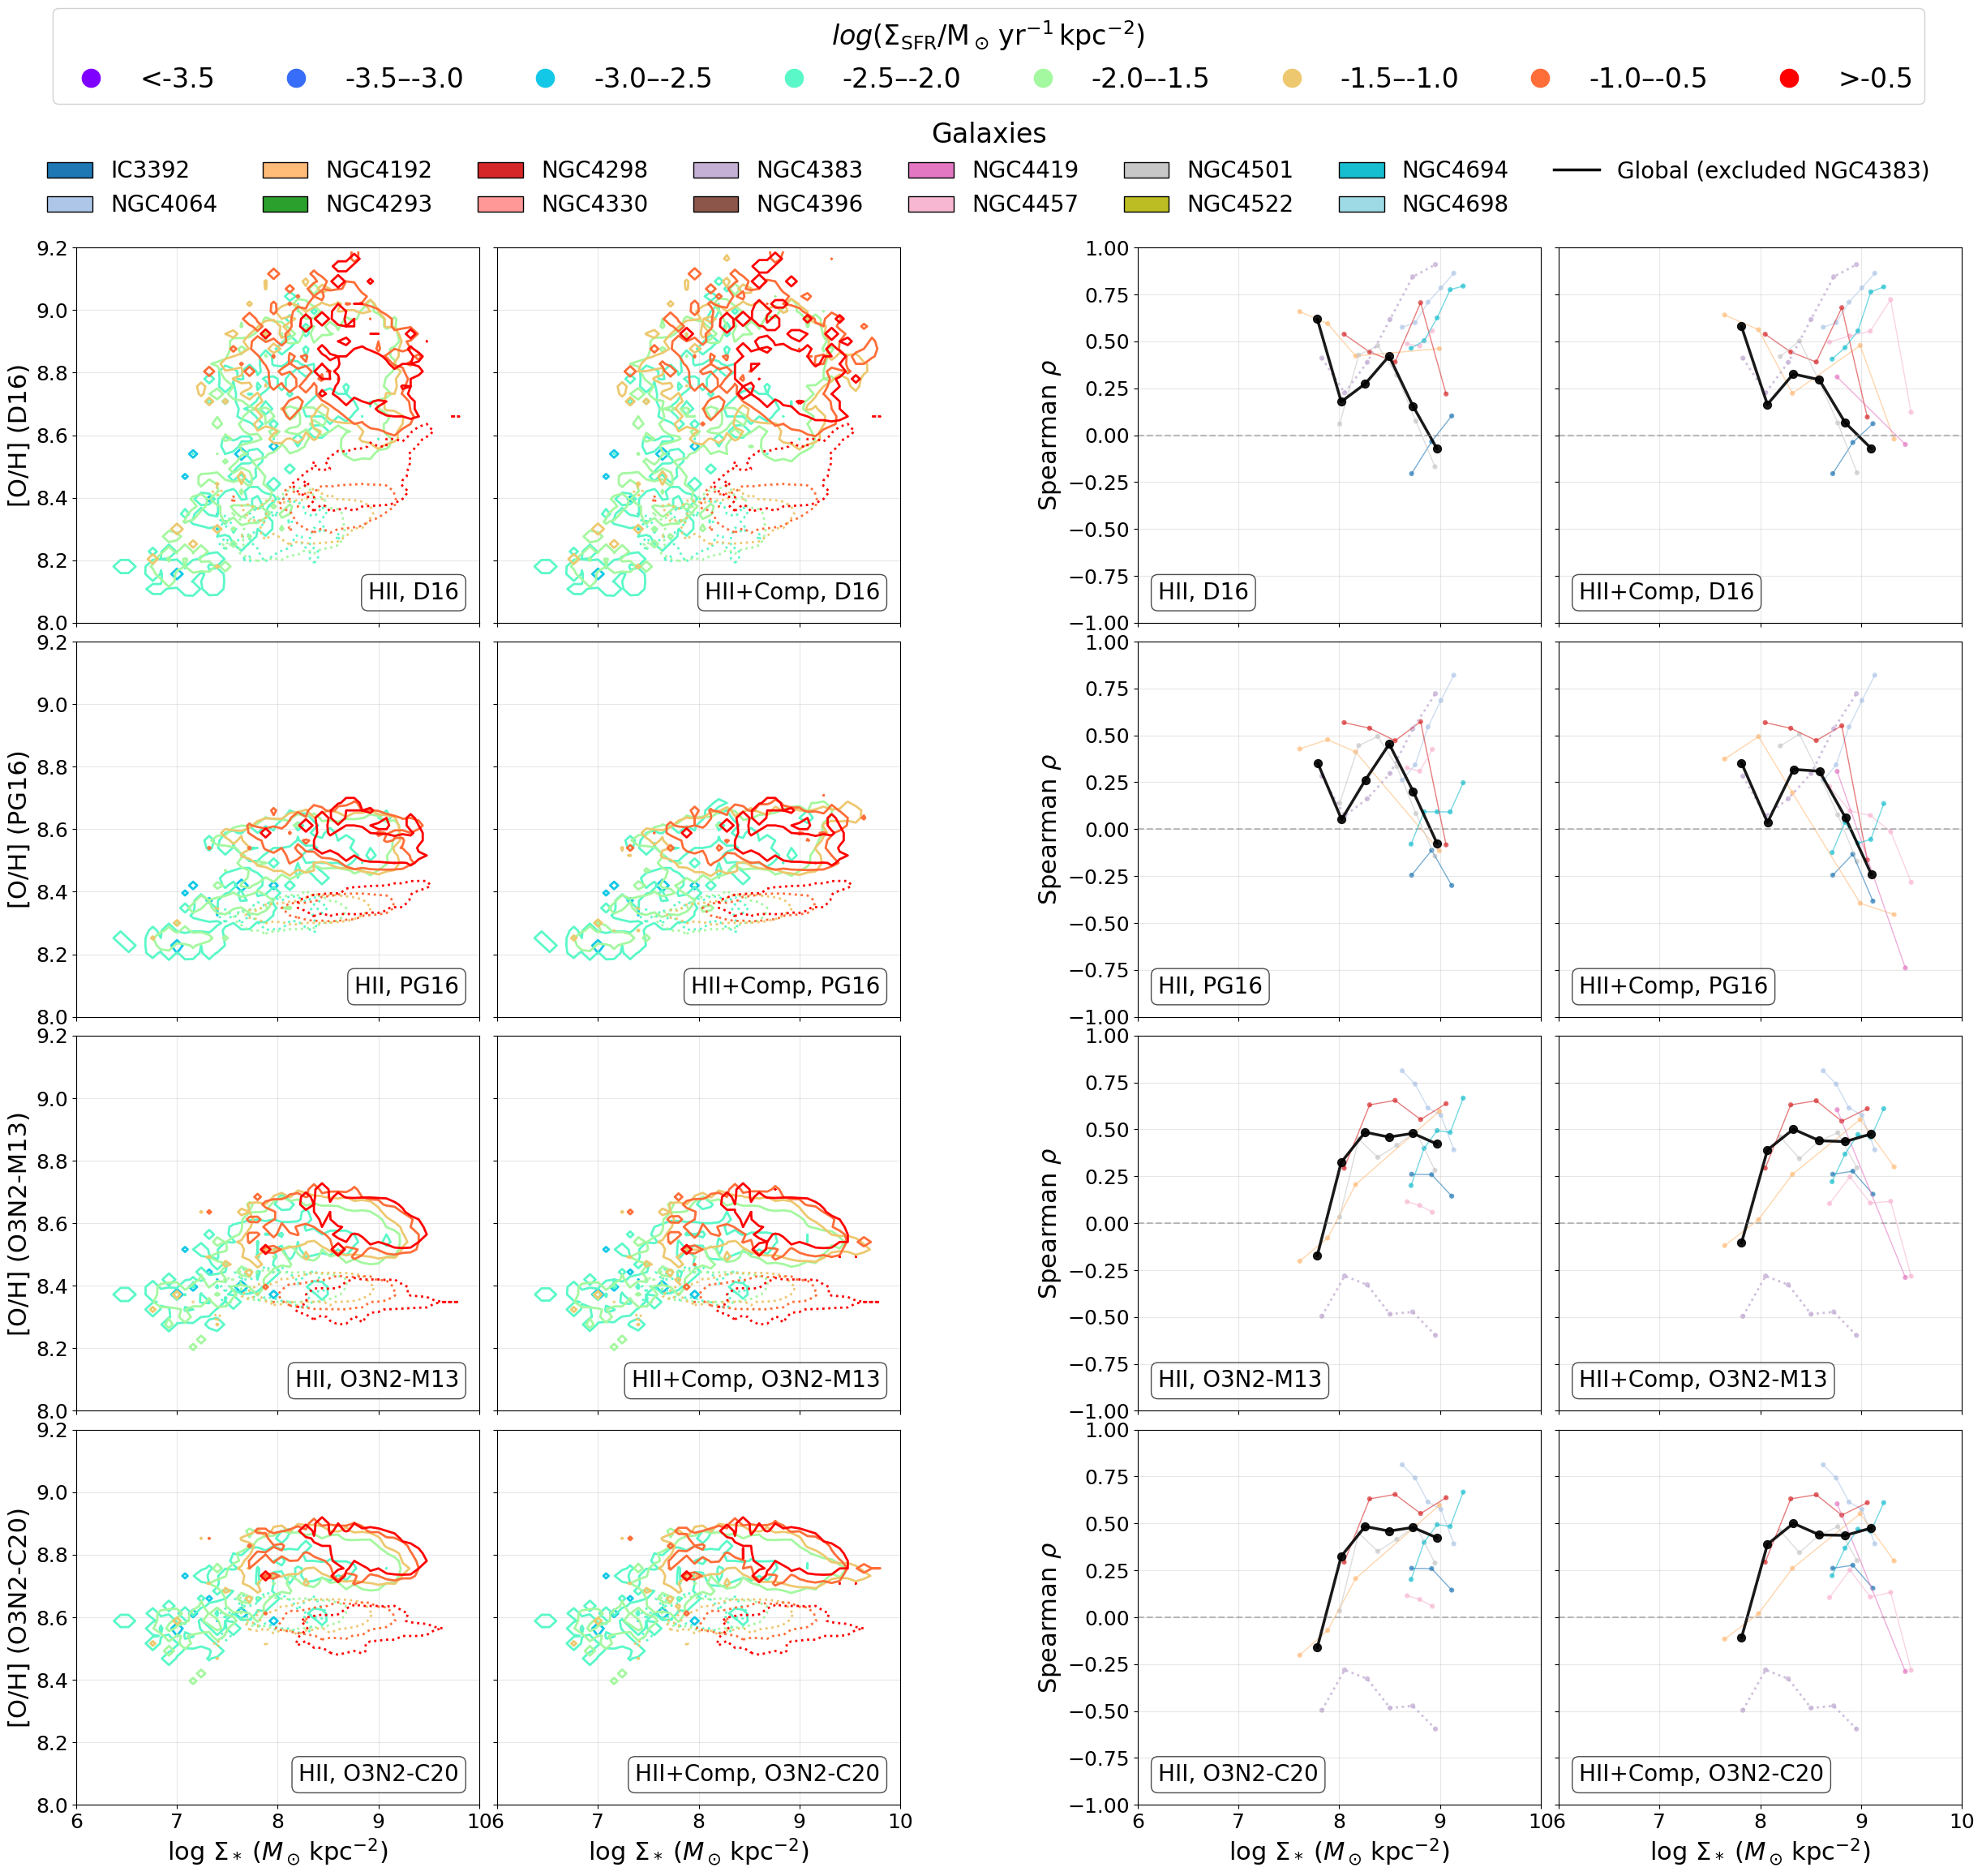

In [ ]:
# ------------------------------------------------------------------
# COMBINED FIGURE: rMZR Scatter (Cols 1-2) and Spearman rho (Cols 3-4)
# WITH NGC4383 (Dotted Contours/Lines)
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
import scipy.stats as stats
from scipy.stats import spearmanr
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import matplotlib.lines as mlines

EW_STRICT_MIN = 6.0  # Strict selection: EW(H$\\alpha$) >= 6

# ==========================================
# PART 1: FUNCTIONS & SETUP
# ==========================================

def load_maps_mzr(gal):
    """Load all metallicity calibrations + EW(H$\\alpha$) map for both HII and SF regions (MZR version)"""
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        # HII regions
        sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_d16_HII = h['O_H_D16_HII'].data
        oh_pg16_HII = h['O_H_PG16_HII'].data
        oh_o3n2_m13_HII = h['O_H_O3N2_M13_HII'].data
        oh_o3n2_c20_HII = h['O_H_O3N2_C20_HII'].data
        # SF regions
        sigSFR_SF = h['LOGSFR_SURFACE_DENSITY_SF'].data
        oh_d16_SF = h['O_H_D16_SF'].data
        oh_pg16_SF = h['O_H_PG16_SF'].data
        oh_o3n2_m13_SF = h['O_H_O3N2_M13_SF'].data
        oh_o3n2_c20_SF = h['O_H_O3N2_C20_SF'].data
        # Emission lines
        HB4861_FLUX_corr = h['HB4861_FLUX_corr'].data
        HA6562_FLUX_corr = h['HA6562_FLUX_corr'].data
        OIII5006_FLUX_corr = h['OIII5006_FLUX_corr'].data
        NII6583_FLUX_corr = h['NII6583_FLUX_corr'].data
        SII6716_FLUX_corr = h['SII6716_FLUX_corr'].data
        SII6730_FLUX_corr = h['SII6730_FLUX_corr'].data
    with fits.open(f'{gal}_v0.7dev_gas_BIN_maps.fits') as h_ew:
        ew_ha = h_ew['HA6562_EW'].data
    return (sigM, sigSFR_HII, oh_d16_HII, oh_pg16_HII, oh_o3n2_m13_HII, oh_o3n2_c20_HII,
            sigSFR_SF, oh_d16_SF, oh_pg16_SF, oh_o3n2_m13_SF, oh_o3n2_c20_SF,
            HB4861_FLUX_corr, HA6562_FLUX_corr, OIII5006_FLUX_corr, 
            NII6583_FLUX_corr, SII6716_FLUX_corr, SII6730_FLUX_corr, ew_ha)

def calculate_binned_stats_spearman(x_data, y_data, bin_width=0.2, min_unique=20):
    """Calculate median and std in x-bins (Spearman version)"""
    x_data = np.asarray(x_data)
    y_data = np.asarray(y_data)
    
    finite = np.isfinite(x_data) & np.isfinite(y_data)
    if np.sum(finite) == 0:
        return np.array([]), np.array([]), np.array([]), np.array([])
        
    x_min, x_max = np.nanmin(x_data[finite]), np.nanmax(x_data[finite])
    if not np.isfinite(x_min) or not np.isfinite(x_max) or x_min == x_max:
        return np.array([]), np.array([]), np.array([]), np.array([])
        
    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    if bin_edges.size < 2:
        return np.array([]), np.array([]), np.array([]), np.array([])
        
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    medians = []
    stds = []
    counts = []
    valid_centers = []
    
    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        in_bin = finite & (x_data >= bin_start) & (x_data < bin_end)
        if np.sum(in_bin) == 0:
            continue
            
        y_in_bin = y_data[in_bin]
        if len(np.unique(y_in_bin)) >= min_unique:
            medians.append(np.nanmedian(y_in_bin))
            stds.append(np.nanstd(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])
            
    return (np.array(valid_centers), np.array(medians), 
            np.array(stds), np.array(counts))

def compute_spearman_track(sigM, sigSFR, oh_map, n_bins=6, extra_mask=None, return_valid_mask=False):
    valid_all = np.isfinite(sigM) & np.isfinite(sigSFR) & np.isfinite(oh_map)
    if extra_mask is not None:
        valid_all = valid_all & extra_mask
    if np.sum(valid_all) == 0:
        if return_valid_mask:
            return np.array([]), np.array([]), np.zeros_like(sigM, dtype=bool)
        return np.array([]), np.array([])

    sigM_valid = sigM[valid_all]
    sigSFR_valid = sigSFR[valid_all]
    oh_map_valid = oh_map[valid_all]

    sigmaM_min = np.nanpercentile(sigM_valid, 2.5)
    sigmaM_max = np.nanpercentile(sigM_valid, 97.5)
    sigmaM_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
    sigmaM_centers = 0.5 * (sigmaM_edges[:-1] + sigmaM_edges[1:])
    
    valid_centers = []
    rho_values = []
    used_in_valid = np.zeros_like(sigM_valid, dtype=bool)
    
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM_valid >= sigmaM_edges[i]) & (sigM_valid < sigmaM_edges[i+1])
        elif i == n_bins - 1:
            bin_mask = (sigM_valid >= sigmaM_edges[i]) & (sigM_valid <= sigmaM_edges[i+1])
        else:
            bin_mask = (sigM_valid >= sigmaM_edges[i]) & (sigM_valid < sigmaM_edges[i+1])
            
        if np.sum(bin_mask) <= 20: 
            continue
            
        sfr_bin = sigSFR_valid[bin_mask]
        oh_bin = oh_map_valid[bin_mask]
        
        sfr_off = sfr_bin - np.mean(sfr_bin)
        oh_off = oh_bin - np.mean(oh_bin)
        
        valid_corr = np.isfinite(sfr_off) & np.isfinite(oh_off)
        
        # ------------------------------------------------------------------
        # Calculate 3-sigma clipping mask on unique valid data
        # ------------------------------------------------------------------
        sigma_clip_mask = np.zeros_like(valid_corr, dtype=bool)
        if np.sum(valid_corr) > 0:
            sfr_data = sfr_off[valid_corr]
            oh_data = oh_off[valid_corr]
            
            sfr_unique = np.unique(sfr_data)
            oh_unique = np.unique(oh_data)
            
            x_mean = np.mean(sfr_unique)
            x_std = np.std(sfr_unique)
            y_mean = np.mean(oh_unique)
            y_std = np.std(oh_unique)
            
            x_lower = x_mean - 3 * x_std
            x_upper = x_mean + 3 * x_std
            y_lower = y_mean - 3 * y_std
            y_upper = y_mean + 3 * y_std
            
            within_3sigma = (sfr_data >= x_lower) & (sfr_data <= x_upper) & \
                            (oh_data >= y_lower) & (oh_data <= y_upper)
            sigma_clip_mask[valid_corr] = within_3sigma
            
        x_trend = sfr_off[sigma_clip_mask]
        y_trend = oh_off[sigma_clip_mask]
        centers, _, _, _ = calculate_binned_stats_spearman(x_trend, y_trend, bin_width=0.2, min_unique=20)
        
        if centers.size >= 2 and np.sum(sigma_clip_mask) > 2:
            try:
                rho, _ = spearmanr(sfr_off[sigma_clip_mask], oh_off[sigma_clip_mask])
                if np.isfinite(rho):
                    valid_centers.append(sigmaM_centers[i])
                    rho_values.append(rho)
                    
                    used_in_bin = np.zeros_like(sfr_bin, dtype=bool)
                    used_in_bin[sigma_clip_mask] = True
                    used_in_valid[bin_mask] = used_in_bin
            except:
                pass
                
    # Keep ensemble input consistent with lines actually shown on the plot
    if len(valid_centers) <= 1:
        used_in_valid[:] = False

    final_mask = np.zeros_like(sigM, dtype=bool)
    final_mask[valid_all] = used_in_valid

    if return_valid_mask:
        return np.array(valid_centers), np.array(rho_values), final_mask
    return np.array(valid_centers), np.array(rho_values)

# ==========================================
# PART 2: DATA COLLECTION
# ==========================================

# Get galaxies
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies_all = [f.name.split('_')[0] for f in bins]
excluded_galaxies = {'NGC4383'}
galaxies = [g for g in galaxies_all if g not in excluded_galaxies]
print(f"Processing {len(galaxies)} galaxies (excluding NGC4383 for stats): {', '.join(galaxies)}")
print(f"Applying strict EW selection to both HII and SF: EW(H$\\alpha$)>={EW_STRICT_MIN:.1f}")

# --- MZR Data Containers (Main) ---
all_logSigmaM_HII = []
all_logSigmaSFR_HII = []
all_oh_d16_HII = []
all_oh_pg16_HII = []
all_oh_o3n2_m13_HII = []
all_oh_o3n2_c20_HII = []

all_logSigmaM_SF = []
all_logSigmaSFR_SF = []
all_oh_d16_SF = []
all_oh_pg16_SF = []
all_oh_o3n2_m13_SF = []
all_oh_o3n2_c20_SF = []

all_logSFR_hii = [] # For binning
all_logSFR_sf = []

# --- Spearman Data Containers (Main) ---
spearman_results = {
    'HII': {ind: {'galaxies': {}, 'global_pixels': {'sigM': [], 'sigSFR': [], 'oh': []}} for ind in ['D16', 'PG16', 'O3N2-M13', 'O3N2-C20']},
    'SF': {ind: {'galaxies': {}, 'global_pixels': {'sigM': [], 'sigSFR': [], 'oh': []}} for ind in ['D16', 'PG16', 'O3N2-M13', 'O3N2-C20']}
}

# --- NGC4383 Data Container ---
ngc4383_data = {
    'HII': {'sigM': [], 'sigSFR': [], 'D16': [], 'PG16': [], 'O3N2-M13': [], 'O3N2-C20': []},
    'SF': {'sigM': [], 'sigSFR': [], 'D16': [], 'PG16': [], 'O3N2-M13': [], 'O3N2-C20': []}
}
ngc4383_spearman = {
    'HII': {ind: ([], []) for ind in ['D16', 'PG16', 'O3N2-M13', 'O3N2-C20']},
    'SF': {ind: ([], []) for ind in ['D16', 'PG16', 'O3N2-M13', 'O3N2-C20']}
}

print("Collecting data...")
for gal in galaxies_all:
    # Load data using the MZR loader (it has everything)
    try:
        (logSigmaM, logSigmaSFR_HII, oh_d16_HII, oh_pg16_HII, oh_o3n2_m13_HII, oh_o3n2_c20_HII,
         logSigmaSFR_SF, oh_d16_SF, oh_pg16_SF, oh_o3n2_m13_SF, oh_o3n2_c20_SF,
         HB, HA, OIII, NII, SII6716, SII6730, ew_ha) = load_maps_mzr(gal)
    except Exception as e:
        print(f"Skipping {gal}: {e}")
        continue

    # --- Process MZR Data ---
    valid_ew = np.isfinite(ew_ha) & (ew_ha >= EW_STRICT_MIN)
    common_mask_HII = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & 
                       np.isfinite(oh_d16_HII) & np.isfinite(oh_pg16_HII) & 
                       np.isfinite(oh_o3n2_m13_HII) & np.isfinite(oh_o3n2_c20_HII) & valid_ew)
    
    common_mask_SF = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_SF) & 
                      np.isfinite(oh_d16_SF) & np.isfinite(oh_pg16_SF) & 
                      np.isfinite(oh_o3n2_m13_SF) & np.isfinite(oh_o3n2_c20_SF) & valid_ew)
    
    if gal == 'NGC4383':
        # Store NGC4383 data separately
        ngc4383_data['HII']['sigM'] = logSigmaM[common_mask_HII].flatten()
        ngc4383_data['HII']['sigSFR'] = logSigmaSFR_HII[common_mask_HII].flatten()
        ngc4383_data['HII']['D16'] = oh_d16_HII[common_mask_HII].flatten()
        ngc4383_data['HII']['PG16'] = oh_pg16_HII[common_mask_HII].flatten()
        ngc4383_data['HII']['O3N2-M13'] = oh_o3n2_m13_HII[common_mask_HII].flatten()
        ngc4383_data['HII']['O3N2-C20'] = oh_o3n2_c20_HII[common_mask_HII].flatten()
        
        ngc4383_data['SF']['sigM'] = logSigmaM[common_mask_SF].flatten()
        ngc4383_data['SF']['sigSFR'] = logSigmaSFR_SF[common_mask_SF].flatten()
        ngc4383_data['SF']['D16'] = oh_d16_SF[common_mask_SF].flatten()
        ngc4383_data['SF']['PG16'] = oh_pg16_SF[common_mask_SF].flatten()
        ngc4383_data['SF']['O3N2-M13'] = oh_o3n2_m13_SF[common_mask_SF].flatten()
        ngc4383_data['SF']['O3N2-C20'] = oh_o3n2_c20_SF[common_mask_SF].flatten()
        
        # Compute Spearman for NGC4383
        maps_4383 = {
            'HII': {
                'D16': (logSigmaM, logSigmaSFR_HII, oh_d16_HII),
                'PG16': (logSigmaM, logSigmaSFR_HII, oh_pg16_HII),
                'O3N2-M13': (logSigmaM, logSigmaSFR_HII, oh_o3n2_m13_HII),
                'O3N2-C20': (logSigmaM, logSigmaSFR_HII, oh_o3n2_c20_HII)
            },
            'SF': {
                'D16': (logSigmaM, logSigmaSFR_SF, oh_d16_SF),
                'PG16': (logSigmaM, logSigmaSFR_SF, oh_pg16_SF),
                'O3N2-M13': (logSigmaM, logSigmaSFR_SF, oh_o3n2_m13_SF),
                'O3N2-C20': (logSigmaM, logSigmaSFR_SF, oh_o3n2_c20_SF)
            }
        }
        for reg in ['HII', 'SF']:
            for ind in ['D16', 'PG16', 'O3N2-M13', 'O3N2-C20']:
                sM, sSFR, oh = maps_4383[reg][ind]
                x, y = compute_spearman_track(sM, sSFR, oh, extra_mask=valid_ew)
                ngc4383_spearman[reg][ind] = (x, y)

    else:
        # Append Main MZR data
        all_logSigmaM_HII.extend(logSigmaM[common_mask_HII].flatten())
        all_logSigmaSFR_HII.extend(logSigmaSFR_HII[common_mask_HII].flatten())
        all_oh_d16_HII.extend(oh_d16_HII[common_mask_HII].flatten())
        all_oh_pg16_HII.extend(oh_pg16_HII[common_mask_HII].flatten())
        all_oh_o3n2_m13_HII.extend(oh_o3n2_m13_HII[common_mask_HII].flatten())
        all_oh_o3n2_c20_HII.extend(oh_o3n2_c20_HII[common_mask_HII].flatten())
        all_logSFR_hii.extend(logSigmaSFR_HII[common_mask_HII].flatten())
        
        all_logSigmaM_SF.extend(logSigmaM[common_mask_SF].flatten())
        all_logSigmaSFR_SF.extend(logSigmaSFR_SF[common_mask_SF].flatten())
        all_oh_d16_SF.extend(oh_d16_SF[common_mask_SF].flatten())
        all_oh_pg16_SF.extend(oh_pg16_SF[common_mask_SF].flatten())
        all_oh_o3n2_m13_SF.extend(oh_o3n2_m13_SF[common_mask_SF].flatten())
        all_oh_o3n2_c20_SF.extend(oh_o3n2_c20_SF[common_mask_SF].flatten())
        all_logSFR_sf.extend(logSigmaSFR_SF[common_mask_SF].flatten())

        # --- Process Spearman Data (Main) ---
        maps = {
            'HII': {
                'D16': (logSigmaM, logSigmaSFR_HII, oh_d16_HII),
                'PG16': (logSigmaM, logSigmaSFR_HII, oh_pg16_HII),
                'O3N2-M13': (logSigmaM, logSigmaSFR_HII, oh_o3n2_m13_HII),
                'O3N2-C20': (logSigmaM, logSigmaSFR_HII, oh_o3n2_c20_HII)
            },
            'SF': {
                'D16': (logSigmaM, logSigmaSFR_SF, oh_d16_SF),
                'PG16': (logSigmaM, logSigmaSFR_SF, oh_pg16_SF),
                'O3N2-M13': (logSigmaM, logSigmaSFR_SF, oh_o3n2_m13_SF),
                'O3N2-C20': (logSigmaM, logSigmaSFR_SF, oh_o3n2_c20_SF)
            }
        }
        
        for reg in ['HII', 'SF']:
            for ind in ['D16', 'PG16', 'O3N2-M13', 'O3N2-C20']:
                sM, sSFR, oh = maps[reg][ind]
                # Compute per-galaxy track and exact contributing points
                x, y, valid_for_global = compute_spearman_track(
                    sM, sSFR, oh, extra_mask=valid_ew, return_valid_mask=True
                )
                # Keep only galaxies that are actually shown (len(x) > 1)
                if len(x) > 1:
                    spearman_results[reg][ind]['galaxies'][gal] = (x, y)
                    # Ensemble uses only points that formed plotted per-galaxy trends
                    if np.sum(valid_for_global) > 0:
                        spearman_results[reg][ind]['global_pixels']['sigM'].extend(sM[valid_for_global])
                        spearman_results[reg][ind]['global_pixels']['sigSFR'].extend(sSFR[valid_for_global])
                        spearman_results[reg][ind]['global_pixels']['oh'].extend(oh[valid_for_global])

# Convert MZR lists to arrays
all_logSigmaM_HII = np.array(all_logSigmaM_HII)
all_logSigmaSFR_HII = np.array(all_logSigmaSFR_HII)
all_oh_d16_HII = np.array(all_oh_d16_HII)
all_oh_pg16_HII = np.array(all_oh_pg16_HII)
all_oh_o3n2_m13_HII = np.array(all_oh_o3n2_m13_HII)
all_oh_o3n2_c20_HII = np.array(all_oh_o3n2_c20_HII)
all_logSFR_hii = np.array(all_logSFR_hii)

all_logSigmaM_SF = np.array(all_logSigmaM_SF)
all_logSigmaSFR_SF = np.array(all_logSigmaSFR_SF)
all_oh_d16_SF = np.array(all_oh_d16_SF)
all_oh_pg16_SF = np.array(all_oh_pg16_SF)
all_oh_o3n2_m13_SF = np.array(all_oh_o3n2_m13_SF)
all_oh_o3n2_c20_SF = np.array(all_oh_o3n2_c20_SF)
all_logSFR_sf = np.array(all_logSFR_sf)

# Compute global Spearman tracks (Main only)
print("Computing global Spearman trends...")
for reg in ['HII', 'SF']:
    for ind in ['D16', 'PG16', 'O3N2-M13', 'O3N2-C20']:
        g_data = spearman_results[reg][ind]['global_pixels']
        if len(g_data['sigM']) > 0:
            x, y = compute_spearman_track(
                np.array(g_data['sigM']), 
                np.array(g_data['sigSFR']), 
                np.array(g_data['oh'])
            )
            spearman_results[reg][ind]['global_track'] = (x, y)
        else:
            spearman_results[reg][ind]['global_track'] = (np.array([]), np.array([]))

# ==========================================
# PART 3: PLOTTING
# ==========================================

# Setup MZR bins
sfr_bin_edges = [-np.inf, -3.5, -3.0, -2.5, -2.0, -1.5, -1.0, -0.5, np.inf]
n_bins = len(sfr_bin_edges) - 1
mzr_colors = plt.cm.rainbow(np.linspace(0, 1, n_bins))
bin_labels = ['<-3.5', '-3.5–-3.0', '-3.0–-2.5', '-2.5–-2.0', '-2.0–-1.5', '-1.5–-1.0', '-1.0–-0.5', '>-0.5']

# Setup Galaxy colors (using ALL galaxies to preserve color mapping)
galaxy_colors_all = plt.cm.tab20(np.linspace(0, 1, len(galaxies_all)))
galaxy_color_dict = dict(zip(galaxies_all, galaxy_colors_all))

# Create Figure with more top space for legends
fig = plt.figure(figsize=(30, 24))
# 4 rows, 5 columns (use 5 cols with middle one as spacer). Large top margin for two legends stacked vertically.
# Columns: 0=HII, 1=SF, 2=SPACER, 3=Spearman HII, 4=Spearman SF
# Width ratios: normal, normal, wide spacer, normal, normal
# Use subplots for fine control over spacing
gs = gridspec.GridSpec(4, 5, figure=fig, hspace=0.05, top=0.85, bottom=0.05,
                       width_ratios=[1, 1, 0.5, 1, 1],  # Middle column is spacer
                       wspace=0.05)  # Base spacing (will be 0.2x of original 0.25)

calibrations = ['D16', 'PG16', 'O3N2-M13', 'O3N2-C20']
mzr_data_HII = [all_oh_d16_HII, all_oh_pg16_HII, all_oh_o3n2_m13_HII, all_oh_o3n2_c20_HII]
mzr_data_SF = [all_oh_d16_SF, all_oh_pg16_SF, all_oh_o3n2_m13_SF, all_oh_o3n2_c20_SF]

mzr_legend_handles = []
mzr_legend_labels = []

for row_idx, calib_name in enumerate(calibrations):
    # --- COL 0 & 1: MZR (Scatter) ---
    # Note: Using columns 0 and 1 for MZR, column 2 is spacer, columns 3 and 4 for Spearman
    ax_mzr_HII = fig.add_subplot(gs[row_idx, 0])
    ax_mzr_SF = fig.add_subplot(gs[row_idx, 1])
    
    oh_HII = mzr_data_HII[row_idx]
    oh_SF = mzr_data_SF[row_idx]
    
    # Plot MZR HII (Contours for 13 galaxies - solid lines)
    for i in range(n_bins):
        in_bin = (all_logSigmaSFR_HII >= sfr_bin_edges[i]) & (all_logSigmaSFR_HII < sfr_bin_edges[i+1])
        if np.sum(in_bin) > 20:  # Need enough points for density estimation
            try:
                x = all_logSigmaM_HII[in_bin]
                y = oh_HII[in_bin]
                
                # Use 2D histogram directly (much faster than KDE)
                xmin, xmax = 6, 10
                ymin, ymax = 8.0, 9.2
                H, xedges, yedges = np.histogram2d(x, y, bins=50, range=[[xmin, xmax], [ymin, ymax]], density=True)
                
                # Find 95% density threshold
                H_flat = H.flatten()
                H_sorted = np.sort(H_flat)[::-1]
                H_cumsum = np.cumsum(H_sorted)
                H_cumsum /= H_cumsum[-1]
                threshold_95 = H_sorted[np.where(H_cumsum >= 0.95)[0][0]]
                
                # Create grid centers for contour plotting
                x_centers = (xedges[:-1] + xedges[1:]) / 2
                y_centers = (yedges[:-1] + yedges[1:]) / 2
                
                # Plot solid contour at 95% threshold level for 13 galaxies
                ax_mzr_HII.contour(x_centers, y_centers, H.T, levels=[threshold_95], colors=[mzr_colors[i]], linestyles='solid', linewidths=2)
            except:
                pass
            
        if row_idx == 0 and len(mzr_legend_handles) < n_bins:
             mzr_legend_handles.append(mlines.Line2D([], [], color=mzr_colors[i], marker='o', linestyle='None', markersize=16, label=bin_labels[i]))
             mzr_legend_labels.append(bin_labels[i])
        
        # Plot NGC4383 Contours (HII) - 95% population (dotted)
        if len(ngc4383_data['HII']['sigM']) > 0:
            ngc_sigM = np.array(ngc4383_data['HII']['sigM'])
            ngc_oh = np.array(ngc4383_data['HII'][calib_name])
            ngc_sfr = np.array(ngc4383_data['HII']['sigSFR'])
            
            in_bin_ngc = (ngc_sfr >= sfr_bin_edges[i]) & (ngc_sfr < sfr_bin_edges[i+1])
            if np.sum(in_bin_ngc) > 20: # Need enough points for density estimation
                try:
                    x = ngc_sigM[in_bin_ngc]
                    y = ngc_oh[in_bin_ngc]
                    
                    # Use 2D histogram directly (much faster than KDE)
                    xmin, xmax = 6, 10
                    ymin, ymax = 8.0, 9.2
                    H, xedges, yedges = np.histogram2d(x, y, bins=50, range=[[xmin, xmax], [ymin, ymax]], density=True)
                    
                    # Find 95% density threshold
                    H_flat = H.flatten()
                    H_sorted = np.sort(H_flat)[::-1]
                    H_cumsum = np.cumsum(H_sorted)
                    H_cumsum /= H_cumsum[-1]
                    threshold_95 = H_sorted[np.where(H_cumsum >= 0.95)[0][0]]
                    
                    # Create grid centers for contour plotting
                    x_centers = (xedges[:-1] + xedges[1:]) / 2
                    y_centers = (yedges[:-1] + yedges[1:]) / 2
                    
                    # Plot dotted contour at 95% threshold level
                    ax_mzr_HII.contour(x_centers, y_centers, H.T, levels=[threshold_95], colors=[mzr_colors[i]], linestyles='dotted', linewidths=2)
                except:
                    pass

    # Plot MZR SF (Contours for 13 galaxies - solid lines)
    for i in range(n_bins):
        in_bin = (all_logSigmaSFR_SF >= sfr_bin_edges[i]) & (all_logSigmaSFR_SF < sfr_bin_edges[i+1])
        if np.sum(in_bin) > 20:  # Need enough points for density estimation
            try:
                x = all_logSigmaM_SF[in_bin]
                y = oh_SF[in_bin]
                
                # Create 2D histogram to find 95% density threshold
                # Use 2D histogram directly (much faster than KDE)
                xmin, xmax = 6, 10
                ymin, ymax = 8.0, 9.2
                H, xedges, yedges = np.histogram2d(x, y, bins=50, range=[[xmin, xmax], [ymin, ymax]], density=True)
                
                # Find 95% density threshold
                H_flat = H.flatten()
                H_sorted = np.sort(H_flat)[::-1]
                H_cumsum = np.cumsum(H_sorted)
                H_cumsum /= H_cumsum[-1]
                threshold_95 = H_sorted[np.where(H_cumsum >= 0.95)[0][0]]
                
                # Create grid centers for contour plotting
                x_centers = (xedges[:-1] + xedges[1:]) / 2
                y_centers = (yedges[:-1] + yedges[1:]) / 2
                
                # Plot solid contour at 95% threshold level for 13 galaxies
                ax_mzr_SF.contour(x_centers, y_centers, H.T, levels=[threshold_95], colors=[mzr_colors[i]], linestyles='solid', linewidths=2)
            except:
                pass
        
        # Plot NGC4383 Contours (SF) - 95% population (dotted)
        if len(ngc4383_data['SF']['sigM']) > 0:
            ngc_sigM = np.array(ngc4383_data['SF']['sigM'])
            ngc_oh = np.array(ngc4383_data['SF'][calib_name])
            ngc_sfr = np.array(ngc4383_data['SF']['sigSFR'])
            
            in_bin_ngc = (ngc_sfr >= sfr_bin_edges[i]) & (ngc_sfr < sfr_bin_edges[i+1])
            if np.sum(in_bin_ngc) > 20:
                try:
                    x = ngc_sigM[in_bin_ngc]
                    y = ngc_oh[in_bin_ngc]
                    
                    # Create 2D histogram to find 95% density threshold
                    # Use 2D histogram directly (much faster than KDE)
                    xmin, xmax = 6, 10
                    ymin, ymax = 8.0, 9.2
                    H, xedges, yedges = np.histogram2d(x, y, bins=50, range=[[xmin, xmax], [ymin, ymax]], density=True)
                    
                    # Find 95% density threshold
                    H_flat = H.flatten()
                    H_sorted = np.sort(H_flat)[::-1]
                    H_cumsum = np.cumsum(H_sorted)
                    H_cumsum /= H_cumsum[-1]
                    threshold_95 = H_sorted[np.where(H_cumsum >= 0.95)[0][0]]
                    
                    # Create grid centers for contour plotting
                    x_centers = (xedges[:-1] + xedges[1:]) / 2
                    y_centers = (yedges[:-1] + yedges[1:]) / 2
                    
                    # Plot dotted contour at 95% threshold level
                    ax_mzr_SF.contour(x_centers, y_centers, H.T, levels=[threshold_95], colors=[mzr_colors[i]], linestyles='dotted', linewidths=2)
                except:
                    pass

    # Format MZR Axes
    for col_idx, (ax, region_label) in enumerate(zip([ax_mzr_HII, ax_mzr_SF], ['HII', 'HII+Comp'])):
        # X-axis label only on bottom row
        if row_idx == 3:  # Bottom row
            ax.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=22)
        else:
            ax.set_xlabel('')
            ax.tick_params(labelbottom=False)
        
        # Y-axis label only on left column of first two columns
        if col_idx == 0:  # Left column
            ax.set_ylabel(f'[O/H] ({calib_name})', fontsize=22)
        else:
            ax.set_ylabel('')
            ax.tick_params(labelleft=False)
        
        # Set tick label size
        ax.tick_params(labelsize=18)
        
        ax.set_xlim(6, 10)
        ax.set_ylim(8.0, 9.2) # Fixed range for consistency
        ax.grid(True, alpha=0.3)
        
        # Add annotation in bottom right
        ax.text(0.95, 0.05, f'{region_label}, {calib_name}', 
                transform=ax.transAxes, fontsize=20, 
                verticalalignment='bottom', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

    # --- COL 3 & 4: Spearman ---
    # Note: Column 2 is the spacer, so Spearman plots go in columns 3 and 4
    ax_sp_HII = fig.add_subplot(gs[row_idx, 3])
    ax_sp_SF = fig.add_subplot(gs[row_idx, 4])
    
    for col_idx, (ax, region_key, region_label) in enumerate(zip([ax_sp_HII, ax_sp_SF], ['HII', 'SF'], ['HII', 'HII+Comp'])):
        # Plot individual galaxies (Main)
        for gal, (x, y) in spearman_results[region_key][calib_name]['galaxies'].items():
            if len(x) <= 1: continue
            color = galaxy_color_dict[gal]
            idx = np.argsort(x)
            ax.plot(x[idx], y[idx], color=color, alpha=0.6, linewidth=1)
            ax.scatter(x[idx], y[idx], color=color, s=20, alpha=0.7, edgecolors='none')
            
        # Plot NGC4383 (Dotted)
        gx_ngc, gy_ngc = ngc4383_spearman[region_key][calib_name]
        if len(gx_ngc) > 0:
            color = galaxy_color_dict['NGC4383']
            idx = np.argsort(gx_ngc)
            ax.plot(gx_ngc[idx], gy_ngc[idx], color=color, alpha=0.8, linewidth=2, linestyle=':')
            ax.scatter(gx_ngc[idx], gy_ngc[idx], color=color, s=20, alpha=0.8, edgecolors='none')

        # Plot global trend (Main only)
        gx, gy = spearman_results[region_key][calib_name].get('global_track', ([], []))
        if len(gx) > 0:
            idx = np.argsort(gx)
            ax.plot(gx[idx], gy[idx], color='black', linewidth=2.5, alpha=0.9)
            ax.scatter(gx[idx], gy[idx], color='black', s=50, alpha=0.9, zorder=10)
            
        ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
        ax.set_ylim(-1.0, 1.0)
        ax.set_xlim(6, 10)
        
        # X-axis label only on bottom row
        if row_idx == 3:  # Bottom row
            ax.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=22)
        else:
            ax.set_xlabel('')
            ax.tick_params(labelbottom=False)
        
        # Y-axis label only on left column of last two columns (col 2)
        if col_idx == 0:  # Left column of columns 2-3
            ax.set_ylabel(r'Spearman $\rho$', fontsize=22)
        else:
            ax.set_ylabel('')
            ax.tick_params(labelleft=False)
        
        # Set tick label size
        ax.tick_params(labelsize=18)
        
        ax.grid(True, alpha=0.3)
        
        # Add annotation in bottom left
        ax.text(0.05, 0.05, f'{region_label}, {calib_name}', 
            transform=ax.transAxes, fontsize=20, 
            verticalalignment='bottom', horizontalalignment='left',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

# --- LEGENDS ---
# 1. MZR Legend (SFR bins) - Top position
fig.legend(mzr_legend_handles, mzr_legend_labels, loc='upper center', bbox_to_anchor=(0.5, 0.98),
          ncol=8, fontsize=24, framealpha=0.9, 
          title=r'$log(\Sigma_\mathrm{SFR}/\mathrm{M_\odot\,yr^{-1}\,kpc^{-2}})$', title_fontsize=24)

# 2. Spearman Legend (Galaxies) - Below the SFR legend
spearman_legend_elements = [Patch(facecolor=galaxy_color_dict[gal], edgecolor='black', label=gal) for gal in galaxies_all]
spearman_legend_elements.append(mlines.Line2D([], [], color='black', lw=2.5, label='Global (excluded NGC4383)'))

fig.legend(handles=spearman_legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.925),
           ncol=8, frameon=False, fontsize=20, title='Galaxies', title_fontsize=24)

# plt.savefig('Plot_Paper_1/Combined_rMZR_spearman.png', dpi=600, bbox_inches='tight')
# plt.savefig('Plot_Paper_1/Combined_rMZR_spearman.pdf', dpi=600, bbox_inches='tight')
plt.tight_layout(rect=[0, 0, 1, 0.85])
plt.show()
